# Download and prepare `LW_OUT` (2005-2025)

**notebook version**: `1` (3 Sep 2026)

## ℹ️ About this notebook

This notebook downloads the screened outgoing longwave radiation `LW_OUT` from the InfluxDB
database and turns it into the published product. It merges the two data versions into one
continuous series and applies the corrections that the site's 2012 faults require. It then works out
which instrument and which calibration factor produced each part of the record, and writes the
result to the external data folder.

The structure follows notebook `06`, which does the same job for `LW_IN`. That notebook measures the
downward half of the longwave exchange, using the second pyrgeometer of the same instrument. Because
the two pyrgeometers are separate detectors with separate calibration factors, a finding about the
incoming channel says nothing definite about the outgoing one. Every era question `06` asks is
therefore asked again here, and answered from this channel's own data.

Much of this notebook is the same as `06`. Neither gap-fills, both export the measured series with
its gaps, both flag the days between the radiometer exchange and the logger-program update instead
of correcting them, and neither has a reference instrument, so both make their checks against
physics rather than against a second sensor.

Three things are genuinely different, and each shapes a section below.

1. **The two data versions may cover some of the same half-hours.** The `mst` screening covers the
   early record, and the `diive` screening begins in January 2020, so both may hold the years in
   between. That is worth having, because two independent screenings of one measurement are the
   only opportunity in this product to check either of them against anything. The two are compared
   before they are joined, and the sections that depend on the comparison say so when it could not
   be made.
2. **The time axis can be checked.** The canopy heats in the sun and cools at night, so `LW_OUT`
   has a daily cycle that follows the sun. Notebook `06` had to apply the August 2012 clock
   correction on the strength of the maintenance record alone, because incoming longwave has too
   little daily cycle to test against. Here the correction is applied and then measured.
3. **The changeover day is flagged differently.** `06` gives the whole of 14 December 2021 to the
   CNR1 and starts its undetermined code the next day. Here the installation day itself carries the
   undetermined code, because the exchange happened during it. The difference is one day, and the
   provenance-flag section states it where a reader comparing the two files will meet it.

The checks against physics use the Stefan-Boltzmann emission of a canopy at air temperature as the
yardstick.

**Output columns:**

- `LW_OUT_T1_47_1`, outgoing longwave radiation in **W m-2**, measured and corrected, with genuine
  gaps left as `NaN`
- `FLAG_LW_OUT_T1_47_1_SOURCE`, which instrument and which calibration factor produced the value

There is **no `FLAG_..._ISFILLED` column**: nothing is filled, so every non-null record is a
measurement and every gap is a real gap.

Downloading uses diive's in-house InfluxDB engine `InfluxIO`. It needs `influxdb-client`, which a
plain `uv sync` installs here via the `diive[db]` extra.

***

## 📇 Data sources

- `LW_OUT_T1_47_1` is the exported variable, measured on tower 1 at 47 m, and it is **the only
  outgoing-longwave series this notebook reads**. It is downloaded from both data versions, `mst`
  and `diive`, and the period each of them covers is derived from the data rather than assumed. Two
  other series with similar names are deliberately left alone. `LW_OUT_COR_T1_47_1` in
  `ch-lae_processed` is a separately stored series, and how it relates to this one has never been
  established. `LW_OUT_BC_M1_2_1` sits below the canopy, so it looks at a different surface from a
  different height.
- `06_METEO_LW_IN_2005-2025.parquet` is the finished incoming-longwave product. It is read as a
  **diagnostic only** and is never exported. Because it comes from the second pyrgeometer of the
  same instrument, it shows whether a change affected the whole radiometer or only one of its two
  detectors. Taken together, the two products are the site's net longwave exchange.
- `02_METEO_TA_GAPFILLED_2004-2025.parquet` is the finished air-temperature product, read as a
  **diagnostic driver only**. Outgoing longwave is thermal emission from the canopy, and the
  temperature of the canopy is close to the temperature of the air, so `sigma * TA^4` is the
  yardstick used throughout this notebook.
- The **logger programs** and the **GIN fieldbook** are opened and filtered in the notebook instead
  of being quoted from memory. A re-run therefore re-derives the sensor identity and the
  calibration constants, and cannot inherit a stale reading of either.
- **No independent instrument measures this quantity at the site.** The MeteoSwiss station at
  Lägern records no longwave at all, and NABEL has no pyrgeometer. The below-canopy pyrgeometer
  measures a different surface over a different period. The one place where two measurements of the
  same thing exist is the overlap between the two data versions, which is why that overlap gets a
  section of its own.

Legend:
- mst ... Data from ETH, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... Data from ETH, meteoscreening with diive

### ⚠️ Which raw variable feeds the exported column

The two data versions did not necessarily read the same raw channel, and for the incoming channel
they did not. Notebook `06` finds that `mst` was fed from `LW_IN_AVG_T1_47_1` while `diive` was fed
from `LW_IN_COR_T1_47_1_Avg`. The second of those is the logger's own temperature-corrected channel,
which the program of 7 June 2016 created. The first is the uncorrected net signal, and the
MeteoscreeningTool added the Stefan-Boltzmann term to it during its own processing. So the same
final quantity was reached by two different routes.

Whether the same is true here is not assumed. The database tags for this variable are read and
displayed below, and the overlap section settles what they mean. If the two data versions carry the
same numbers on the same half-hours, then the two routes agree and the merge simply joins two
screenings of one measurement. If the numbers differ, then the record holds two different quantities
under one name, and it needs a flag that separates them rather than a splice that hides the
difference.

The unit tag is checked at the same time. One of the two series may carry the placeholder
`-not-given-` alongside the real `W m-2`, so the check drops placeholders first and then requires
exactly one real unit to be left.

### 📐 What the exported values are

The exported numbers are **upwelling longwave irradiance**. That is the thermal emission of the
forest canopy as seen from 47 m, plus the small part of the downwelling flux that the canopy
reflects.

Getting from the instrument to that quantity takes one step that is easy to overlook. A
pyrgeometer's voltage is proportional only to the *net* exchange between the surface it views and
the instrument's own body. To obtain the irradiance, the instrument's own emission,
`sigma * T_body^4`, has to be added to that net signal. Every value in this file already includes
it, although the two data versions add it at different points in the chain. A reader who mistook
these values for the converted raw voltage would therefore be wrong by some 300 to 400 W m-2.

The same step sets the scale for everything the notebook does later. A wrong calibration factor
scales the **net** signal and leaves the added emission term alone. For a downward-facing
pyrgeometer above a canopy that net signal is only a few tens of W m-2, whereas the numbers in the
file are several hundred. A calibration error is therefore diluted, and one that shows up plainly in
`06` can be invisible here. That is why the questions below are put to this channel's own data
instead of being answered from the incoming channel.

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC**, and as **`TIMESTAMP_END`**, meaning the stamp marks
the end of the averaging interval. Two conversions then happen on the way into this notebook. On
download, `InfluxIO` shifts the timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data
are in **local time** and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts them to `TIMESTAMP_MID`, and everything from that point on works on middle-of-interval
stamps in local time.

`START` and `STOP` are interpreted in the same timezone as `TIMEZONE_OFFSET_TO_UTC_HOURS`.

***

## ⚙️ Settings

### Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

TARGET = "LW_OUT_T1_47_1"     # exported variable, tower 47 m; the ONLY longwave series read here

# RECORD_START is a CLAIM about where this record begins, and the merge cell tests the downloaded
# data against it rather than trusting it. If the test fires, change this date, the notebook name
# and OUTNAME together.
#
# The date is a fact about the data, not about the programs. The CNR1 instruction first appears in
# LAEGEREN.20050818.CSI, which already measures Lout and Kout, so the outgoing channels were being
# measured from 18 August 2005. The program of 14 September 2005 only moved them onto DIFF3 and
# DIFF4 with a new relay. What the two programs cannot say is when the archive began keeping the
# record, which is what this date is about, and which the assertion below settles from the data.
RECORD_START = '2005-09-14'
RECORD_END = '2025-12-31'

OUTNAME = "13_METEO_LW_OUT_2005-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# --- Diagnostic series, read from the finished products of 02 and 06 ------------------------------
# Both are addressed by path, so a move breaks this read. Neither is exported.
# TA: the HOMOGENIZED column is the one used, for the same reason as in 06 - every comparison below
# crosses January 2016, and the measured column reads about 1.3 degC too cold before it, which is
# about 7 W m-2 in sigma*T^4 and the same order as the changes being investigated.
TA_PRODUCT = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
              r"\workflow\10_METEO\30_PRODUCTS\02_METEO_TA_GAPFILLED_2004-2025.parquet")
TA_COL = "TA_T1_47_1_HOMOGENIZED_gfXG"
TA_MEASURED_COL = "TA_T1_47_1_gfXG"      # the un-homogenized column, used once to show the difference
TA_FLAG = "FLAG_TA_T1_47_1_ISFILLED"

LW_IN_PRODUCT = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
                 r"\workflow\10_METEO\30_PRODUCTS\06_METEO_LW_IN_2005-2025.parquet")
LW_IN_COL = "LW_IN_T1_47_1"
LW_IN_FLAG = "FLAG_LW_IN_T1_47_1_SOURCE"

# --- Inputs for the instrument-identity section ---------------------------------------------------
# The site maintenance record, exported from GIN. It lives BESIDE the workflow folder, not inside
# it, because it is an input to many stages rather than the output of one.
FIELDBOOK = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
             r"\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv")

# Every logger program on disk that measures this channel. The three CR10X programs are the only
# surviving tower programs carrying the CNR1; the CR1000 program is the one installed at the
# January 2016 changeover. No tower program between May 2006 and January 2016 survives, and none
# after January 2016 at all - which matters twice here, because the program that changed a
# calibration factor in June 2016 and the program that gave the CNR4 its own constants in January
# 2022 are both among the ones that did not survive.
PROGRAMS_BEFORE = [
    r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
    r"\csi_loggerscripts\LAEGEREN.20050818.CSI",
    r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
    r"\csi_loggerscripts\LAEGEREN.20050914.CSI",
    r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
    r"\csi_loggerscripts\LAEGEREN.20060524.csi",
]
PROGRAM_AFTER = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
                 r"\logger_scripts\ch-lae_idl_t1_47_1-Version_20160118\CH-LAE_iDL_T1_47_1.CR1")

# --- The dates this notebook is about -------------------------------------------------------------
LOGGER_CHANGE = '2016-01-21'   # CR10X -> CR1000, the date that moved TA by 1.3 degC
CAL_CHANGE = '2016-06-07'      # LW_*_COR channels created; NetRad calibration factor 10.03 -> 12.83
CNR4_INSTALLED = '2021-12-14'  # CNR1 -> CNR4, the day the instrument was exchanged (fieldbook)
CNR4_CONSTANTS = '2022-01-07'  # the CNR4's own calibration constants reach the logger program

# --- Calibration constants ------------------------------------------------------------------------
# Every calibration constant this notebook needs is declared here, and everything downstream uses
# the declared value. The logger programs and the maintenance record are parsed further down only
# to CHECK these declarations, never to supply them.
#
# There are two reasons for that. The logger programs live in the external data folder, which need
# not be present, and a notebook whose numbers depended on whether a file happened to be there
# could give two different answers on two runs of the same code. And a reader of the published page
# can see the constants here, instead of only a claim that they were read from a file.

# The CNR1 conversion, identical for all four channels of the head.
# Source: LAEGEREN.20050818.CSI, LAEGEREN.20050914.CSI and LAEGEREN.20060524.csi (CR10X), and
# CH-LAE_iDL_T1_47_1.CR1 (CR1000). Multiplier 1000/10.03, offset 0, i.e. a sensitivity of
# 10.03 uV W-1 m2. That figure belongs to the PYRANOMETER and was applied to all four detectors,
# the two pyrgeometers included, which is the point step 1 makes.
CNR1_MULTIPLIER = 99.7009
CNR1_OFFSET = 0.0
CNR1_SENSITIVITY = 10.03

# The calibration factor the logger program of 7 June 2016 replaced, and what it replaced it with,
# in uV W-1 m2. Source: the GIN fieldbook entry of that date, which records that the NetRad
# calibration factor was changed from 10.03 to 12.83 on information from the institution that owns
# the instrument. The entry names one factor and does not say whether the new value was written to
# one longwave channel or to both, which is the open question step 4 puts to the data.
SENSITIVITY_OLD = 10.03
SENSITIVITY_NEW = 12.83

# The CNR4's own sensitivities, in uV W-1 m2. Source: the GIN fieldbook entry of 7 January 2022,
# which lists the four constants the updated logger program received as SENSITIVITY_iCNR4_SW_IN,
# _SW_OUT, _LW_IN and _LW_OUT.
CNR4_SENSITIVITIES = {'SW_IN': 13.89, 'SW_OUT': 14.38, 'LW_IN': 10.85, 'LW_OUT': 11.33}
SENSITIVITY_CNR4_LW_OUT = CNR4_SENSITIVITIES['LW_OUT']

### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import html
import re
import textwrap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-09-03 21:50:09
diive version: v0.91.1


### Captions

In [3]:
# Captions. Every table and every figure in this notebook carries one, so that a reader meeting a
# number in the rendered page can tell what it is without reading the code that produced it.
# Defined here, above the first cell that calls either. Copied as-is from notebook 06.
def tabcap(text, width=100):
    """Print a table caption, above the table it belongs to."""
    print(textwrap.fill(f"Table - {text}", width) + "\n")


def figcap(fig, text, width=125):
    """Place a caption under a figure. Call after the last axes of that figure is drawn."""
    width = min(width, max(40, int(14.5 * fig.get_size_inches()[0])))
    caption = textwrap.fill(f"Figure - {text}", width)
    # An engine that still lays the figure out at draw time can make room for a caption itself.
    # plt.tight_layout() does NOT leave one: it executes once and leaves a PlaceHolderLayoutEngine
    # that never runs again, so a caption handed to supxlabel there lands on top of the tick
    # labels. Those figures take the manual branch below.
    _engine = fig.get_layout_engine()
    if _engine is not None and type(_engine).__name__ != 'PlaceHolderLayoutEngine':
        fig.supxlabel(caption, fontsize=9, ha='left', x=0.005)
        return
    lines = len(caption.splitlines())
    extra = 0.17 * lines + 0.12          # inches; one caption line is about 0.17 in at fontsize 9
    width_in, height_in = fig.get_size_inches()
    fig.set_size_inches(width_in, height_in + extra)
    keep = height_in / (height_in + extra)
    offset = extra / (height_in + extra)
    for ax in fig.axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, offset + pos.y0 * keep, pos.width, pos.height * keep])
    fig.text(0.005, 0.01, caption, fontsize=9, ha='left', va='bottom')

### 🧭 Guards

Three inexpensive checks run on every source before anything is done with it.

`LW_OUT_PLAUSIBLE_WM2` sets the physical band this product enforces, 150 to 600 W m-2. Upwelling
longwave from a vegetated surface is `eps * sigma * T_surface^4`, with an emissivity `eps` near 0.98
for a forest. At that emissivity the plausible surface temperatures at this site, about -25 °C to
+45 °C, emit 211 to 569 W m-2, so the band is wider than the record can reach at both ends: 150 and
600 W m-2 correspond to surfaces at about -45 °C and +49 °C. The width is deliberate, because the
band's purpose is to catch a gross error and it must never reject real weather.

Two gross errors would fail it, and both are real possibilities for this variable rather than
imagined ones. A **mistake in scaling** would move the whole series away from the band. An era
stored as the pyrgeometer's **net signal**, without the instrument's own emission added, would sit
near zero instead of near 300. Since the two data versions add that emission term at different
points in the chain, a version that never added it at all would fail this band immediately.

The range check therefore exists in two forms. The **reporting** form runs on download: it counts
how much falls outside the band and prints it, but it does not stop the notebook, because at that
point an out-of-band record is something to act on in the corrections section. The **raising** form
runs on the exported column, after the removals, where an out-of-band record would be a defect in
the file. No unit conversion is needed anywhere, because every series read here is already in
`W m-2`.

In [4]:
# Physically plausible upwelling longwave at this site: the emission of a surface between about
# -25 degC and +45 degC at an emissivity near 0.98.
LW_OUT_PLAUSIBLE_WM2 = (150.0, 600.0)
EXPECTED_UNIT = 'W m-2'
NOT_GIVEN = '-not-given-'   # placeholder the database uses when a unit tag was never filled in


def check_unit(declared_units, source: str) -> str:
    """Verify the database's unit tags for a series say W m-2, ignoring placeholders.

    A series can carry more than one tag value (e.g. when the tag changed over time, or was left
    unset for part of the record), so this always handles a list and never a scalar. Placeholders
    are dropped; exactly one real unit must remain, and it must be the expected one.
    """
    declared = list(declared_units) if isinstance(declared_units, (list, tuple, set)) \
        else [declared_units]
    real = [u for u in declared if u != NOT_GIVEN]
    if len(set(real)) != 1:
        raise ValueError(f"{source}: expected exactly one real unit tag, found {declared}.")
    if real[0] != EXPECTED_UNIT:
        raise ValueError(f"{source}: unit is '{real[0]}', expected '{EXPECTED_UNIT}'.")
    return real[0]


def range_report(series: pd.Series, source: str) -> dict:
    """Describe a series and count how far outside the physical band it reaches.

    Reports rather than raises. On download a record outside the band is a finding to be acted on
    in the Corrections section, not a reason to stop.
    """
    lo, hi = LW_OUT_PLAUSIBLE_WM2
    s = series.dropna()
    if s.empty:
        raise ValueError(f"{source}: no data.")
    return {'records': len(s), 'first': s.index[0], 'last': s.index[-1],
            'median (W m-2)': round(float(s.median()), 2),
            'min (W m-2)': round(float(s.min()), 1), 'max (W m-2)': round(float(s.max()), 1),
            f'below {lo:.0f}': int((s < lo).sum()), f'above {hi:.0f}': int((s > hi).sum())}


def check_range(series: pd.Series, source: str) -> dict:
    """Verify every value is physically plausible upwelling longwave. Raises if one is not."""
    lo, hi = LW_OUT_PLAUSIBLE_WM2
    s = series.dropna()
    if s.empty:
        raise ValueError(f"{source}: no data.")
    if not (lo <= s.min() and s.max() <= hi):
        raise ValueError(f"{source}: range {s.min():.1f}..{s.max():.1f} W m-2 is outside the "
                         f"plausible {lo}..{hi} W m-2.")
    return {'records': len(s), 'median (W m-2)': round(float(s.median()), 2),
            'min (W m-2)': round(float(s.min()), 1), 'max (W m-2)': round(float(s.max()), 1)}

### 🔌 Connect to database

In [5]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## ⬇️ Download

Two series are downloaded: the target variable from each of its two data versions. **Both downloads
are required.** If either returns nothing, that is an error to investigate and not a finding to
report, because an empty answer is far more likely to mean a wrong field name than an era that was
never screened.

The `mst` era is worth a warning in particular. It does not come from `ch-lae_raw` at all: the
MeteoscreeningTool read the acquisition CSV files directly and wrote its output straight into
`ch-lae_processed`. The period covered by the raw field therefore says nothing about the period
covered by the screened one, and the two must not be used to infer each other.

Air temperature and incoming longwave are read from the finished products of notebooks `02` and
`06` rather than from the database, so that the diagnostics below work on the same corrected and
flagged series that a data user would have.

In [6]:
%%time

BUCKET = 'ch-lae_processed'


def download(measurement, fields, start, stop, data_version):
    data, _, _ = dbc.download(
        bucket=BUCKET, measurements=[measurement], fields=fields,
        start=start,  # the start date itself IS included
        stop=stop,    # the stop date itself IS NOT included
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        data_version=data_version)
    return TimestampSanitizer(data=data, output_middle_timestamp=True,
                              nominal_freq=REQUIRED_TIME_RESOLUTION).get()


# The MeteoScreeningTool was retired at the end of 2021, so nothing it wrote can lie beyond this
# stop. Asking for more would only slow the query down.
MST_STOP = '2022-01-01 00:00:01'
mst_lw = download('LW', [TARGET], '2004-01-01 00:00:01', MST_STOP, 'meteoscreening_mst')
diive_lw = download('LW', [TARGET], '2004-01-01 00:00:01', '2026-01-01 00:00:01',
                    'meteoscreening_diive')

print(f"mst   {TARGET}: {mst_lw[TARGET].notna().sum():,} records")
print(f"diive {TARGET}: {diive_lw[TARGET].notna().sum():,} records")
assert mst_lw[TARGET].notna().sum() > 0, (
    "the mst data version returned no records for this field. That is not evidence that the "
    "MeteoscreeningTool never screened it - check the field name and the measurement first, "
    "because the mst era is written into ch-lae_processed independently of the raw field")
assert diive_lw[TARGET].notna().sum() > 0, "the diive data version returned no records"

> DOWNLOADING from bucket ch-lae_processed: variables ['LW_OUT_T1_47_1'] from measurements ['LW'],
data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 (timezone 
offset to UTC 1)

> Downloaded data for 1 variables:

> DOWNLOADING from bucket ch-lae_processed: variables ['LW_OUT_T1_47_1'] from measurements ['LW'],
data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone
offset to UTC 1)

> Downloaded data for 1 variables:

mst   LW_OUT_T1_47_1: 280,159 records
diive LW_OUT_T1_47_1: 105,044 records
CPU times: total: 6.72 s
Wall time: 9.65 s


In [7]:
# Tags straight from the database, including the unit and the raw variable each series came from.
# Within one field and data version there can be several series carrying different tag values, so
# anything reading a tag here handles a list rather than a scalar.
def field_tags(field, measurement, data_version):
    return dbc.show_field_overview(bucket=BUCKET, measurement=measurement, field=field,
                                   data_version=data_version, verbose=False)['tags']


_tags_mst = field_tags(TARGET, 'LW', 'meteoscreening_mst')
_tags_diive = field_tags(TARGET, 'LW', 'meteoscreening_diive')

tabcap("the database's own tags for the two data versions of the exported column. Which raw "
       "variable each version read is the thing to look at: if they differ, the two versions "
       "reached the Stefan-Boltzmann term by different routes, and the overlap section below is "
       "what decides whether that changed the numbers")
display(pd.DataFrame({
    'units': [_tags_mst.get('units'), _tags_diive.get('units')],
    'raw_varname': [_tags_mst.get('raw_varname'), _tags_diive.get('raw_varname')],
}, index=[f'{TARGET} (mst)', f'{TARGET} (diive)']))


def as_list(tagvalue):
    """A database tag can hold one value or several. This always yields a list."""
    return list(tagvalue) if isinstance(tagvalue, (list, tuple, set)) else [tagvalue]


RAW_VARNAMES = {'mst': as_list(_tags_mst.get('raw_varname')),
                'diive': as_list(_tags_diive.get('raw_varname'))}
print(f"\nraw_varname, mst:   {RAW_VARNAMES['mst']}")
print(f"raw_varname, diive: {RAW_VARNAMES['diive']}")
SAME_RAW_SOURCE = set(map(str, RAW_VARNAMES['mst'])) == set(map(str, RAW_VARNAMES['diive']))
if SAME_RAW_SOURCE:
    print("Both data versions read the same raw variable, so the overlap section is testing two "
          "screenings of one channel.")
else:
    print("The two data versions read DIFFERENT raw variables, so they reached the "
          "Stefan-Boltzmann term by different routes. The overlap section is then testing those "
          "two routes against each other as well, which is what its RMS and p99 assertions are "
          "for: a difference in route shows up as scatter about a near-zero median.")

Table - the database's own tags for the two data versions of the exported column. Which raw variable
each version read is the thing to look at: if they differ, the two versions reached the Stefan-
Boltzmann term by different routes, and the overlap section below is what decides whether that
changed the numbers



,units,raw_varname
LW_OUT_T1_47_1 (mst),[W m-2],[LW_OUT_AVG_T1_47_1]
LW_OUT_T1_47_1 (diive),[W m-2],[LW_OUT_COR_T1_47_1_Avg]



raw_varname, mst:   ['LW_OUT_AVG_T1_47_1']
raw_varname, diive: ['LW_OUT_COR_T1_47_1_Avg']
The two data versions read DIFFERENT raw variables, so they reached the Stefan-Boltzmann term by different routes. The overlap section is then testing those two routes against each other as well, which is what its RMS and p99 assertions are for: a difference in route shows up as scatter about a near-zero median.


### Unit and range checks

In [8]:
print("Unit tags (placeholders stripped):")
for _tags, _src in [(_tags_mst, f'{TARGET} (mst)'), (_tags_diive, f'{TARGET} (diive)')]:
    print(f"  {_src:<26} {_tags.get('units')} -> {check_unit(_tags.get('units'), _src)}")

tabcap("each data version as downloaded, before anything is merged or removed. The two medians "
       "are the first thing to read: they cover different years and so differ by weather, but a "
       "difference of hundreds of W m-2 would mean one version stored the pyrgeometer's net "
       "signal rather than irradiance, which the last two columns would also show")
display(pd.DataFrame({f'{TARGET} (mst)': range_report(mst_lw[TARGET], f'{TARGET} (mst)'),
                      f'{TARGET} (diive)': range_report(diive_lw[TARGET], f'{TARGET} (diive)')}).T)

Unit tags (placeholders stripped):
  LW_OUT_T1_47_1 (mst)       ['W m-2'] -> W m-2
  LW_OUT_T1_47_1 (diive)     ['W m-2'] -> W m-2
Table - each data version as downloaded, before anything is merged or removed. The two medians are
the first thing to read: they cover different years and so differ by weather, but a difference of
hundreds of W m-2 would mean one version stored the pyrgeometer's net signal rather than irradiance,
which the last two columns would also show



,records,first,last,median (W m-2),min (W m-2),max (W m-2),below 150,above 600
LW_OUT_T1_47_1 (mst),280159,2005-09-14 13:15:00,2021-12-31 23:45:00,354.83,239.6,675.4,0,1
LW_OUT_T1_47_1 (diive),105044,2020-01-02 00:45:00,2025-12-31 23:45:00,361.31,260.1,503.5,0,0


#### The guards actually guard

A check that has never been seen to fail might be a check or might be a typo, and the two look the
same while everything is working. Each guard is therefore given input it must reject, and the cell
fails if the guard accepts it.

In [9]:
for _bad, _why in [(['kW m-2'], 'wrong unit'), (['W m-2', 'MJ m-2'], 'two real units')]:
    try:
        check_unit(_bad, 'negative control')
        raise AssertionError(f"check_unit accepted {_bad} - the guard is broken.")
    except ValueError as exc:
        print(f"OK ({_why}): {exc}")

try:
    check_range(mst_lw[TARGET] * 10, 'negative control')
    raise AssertionError("check_range accepted a 10x scaled series - the guard is broken.")
except ValueError as exc:
    print(f"OK (scaled x10): {exc}")

try:
    range_report(mst_lw[TARGET].where(lambda s: s > 1e9), 'negative control')
    raise AssertionError("range_report accepted an empty series - the guard is broken.")
except ValueError as exc:
    print(f"OK (empty series): {exc}")

OK (wrong unit): negative control: unit is 'kW m-2', expected 'W m-2'.
OK (two real units): negative control: expected exactly one real unit tag, found ['W m-2', 'MJ m-2'].
OK (scaled x10): negative control: range 2395.6..6754.4 W m-2 is outside the plausible 150.0..600.0 W m-2.
OK (empty series): negative control: no data.


***

## 🔗 Do the two data versions agree where they overlap?

The two screenings may cover some of the same half-hours, and where they do, the same measurement
has been processed twice and independently. Those half-hours can be compared directly, which is the
only external check this product has on either screening.

The comparison has to happen before the merge, not after it. The merge uses `combine_first`, which
takes the `mst` value wherever both versions have one, so any disagreement between them would be
concealed by the splice rather than removed by it. And if the two versions do disagree, then the
record holds two different quantities under one name, which calls for a flag that keeps them apart
instead of a merge that runs them together.

This section therefore does three things in order. It derives the period each version covers from
the data. It compares the two on the timestamps they share. Only then does it merge them.

In [10]:
MST_FIRST, MST_LAST = mst_lw[TARGET].first_valid_index(), mst_lw[TARGET].last_valid_index()
DIIVE_FIRST, DIIVE_LAST = diive_lw[TARGET].first_valid_index(), diive_lw[TARGET].last_valid_index()

tabcap("the span of each data version, taken from the data")
display(pd.DataFrame({
    'first record': [MST_FIRST, DIIVE_FIRST], 'last record': [MST_LAST, DIIVE_LAST],
    'records': [int(mst_lw[TARGET].notna().sum()), int(diive_lw[TARGET].notna().sum())],
}, index=['mst', 'diive']))

# Below this many shared half-hours the comparison cannot support a conclusion either way, so it
# raises rather than reporting a statistic from a handful of records. Two weeks of 30MIN data is
# the smallest window in which a systematic difference could be told from weather.
MIN_OVERLAP_RECORDS = 672

_common = mst_lw[TARGET].dropna().index.intersection(diive_lw[TARGET].dropna().index)
OVERLAP = (_common.min(), _common.max()) if len(_common) else None
print(f"\nhalf-hours held by both versions: {len(_common):,}")
if OVERLAP is not None:
    print(f"overlap: {OVERLAP[0]} to {OVERLAP[1]}")
    if len(_common) < MIN_OVERLAP_RECORDS:
        raise ValueError(
            f"the two data versions share only {len(_common):,} half-hours, fewer than the "
            f"{MIN_OVERLAP_RECORDS:,} this comparison needs. That is too few to show they are the "
            f"same series and too few to show they are not, so the merge below would be splicing "
            f"on no evidence. Establish why the overlap shrank before going further.")
else:
    print("the two versions do not overlap, so they cannot be compared and the merge is a "
          "concatenation whose join is unverified")

Table - the span of each data version, taken from the data



,first record,last record,records
mst,2005-09-14 13:15:00,2021-12-31 23:45:00,280159
diive,2020-01-02 00:45:00,2025-12-31 23:45:00,105044



half-hours held by both versions: 35,032
overlap: 2020-01-02 00:45:00 to 2021-12-31 23:45:00


In [11]:
if OVERLAP is not None:
    _a = mst_lw.loc[_common, TARGET]
    _b = diive_lw.loc[_common, TARGET]
    _d = _b - _a

    tabcap("the two data versions on the half-hours they share. A pair of screenings of one "
           "measurement should differ by rounding and by the few records one of them removed and "
           "the other kept")
    _agree = pd.Series({
        'half-hours compared': len(_common),
        'mst median (W m-2)': round(float(_a.median()), 2),
        'diive median (W m-2)': round(float(_b.median()), 2),
        'median difference (W m-2)': round(float(_d.median()), 3),
        'mean difference (W m-2)': round(float(_d.mean()), 3),
        'RMS difference (W m-2)': round(float(np.sqrt((_d ** 2).mean())), 3),
        'largest difference (W m-2)': round(float(_d.abs().max()), 2),
        'correlation': round(float(_a.corr(_b)), 6),
        'spread ratio (sd diive / sd mst)': round(float(_b.std() / _a.std()), 4),
    }).to_frame('value')
    display(_agree)

    OVERLAP_R = float(_a.corr(_b))
    OVERLAP_BIAS = float(_d.median())
    OVERLAP_SPREAD = float(_b.std() / _a.std())

    tabcap("the same difference year by year, because a bias that appears in one year only would "
           "average away in the summary above")
    _by_year = _d.groupby(_d.index.year).agg(['count', 'median', 'std', 'min', 'max']).round(3)
    _by_year.index.name = 'YEAR'
    display(_by_year)

    OVERLAP_RMS = float(np.sqrt((_d ** 2).mean()))
    OVERLAP_P99 = float(_d.abs().quantile(0.99))

    # Thresholds, all taken from the scatter of the series itself rather than from round numbers.
    # The bias catches a level difference. The RMS and the 99th percentile of the absolute
    # difference are what catch the failure this section exists for: the two data versions reach
    # the Stefan-Boltzmann term by different routes, and a difference in those routes appears as
    # scatter about a near-zero median, which the bias and the spread ratio would both pass.
    AGREEMENT_SCALE = float(_a.std())
    BIAS_LIMIT = 0.01 * AGREEMENT_SCALE
    RMS_LIMIT = 0.05 * AGREEMENT_SCALE
    P99_LIMIT = 0.10 * AGREEMENT_SCALE
    print(f"\nthe overlap's own standard deviation: {AGREEMENT_SCALE:.2f} W m-2")
    print(f"  bias limit  1 % of it = {BIAS_LIMIT:.3f} W m-2   measured {OVERLAP_BIAS:+.3f}")
    print(f"  RMS limit   5 % of it = {RMS_LIMIT:.3f} W m-2   measured {OVERLAP_RMS:.3f}")
    print(f"  p99 limit  10 % of it = {P99_LIMIT:.3f} W m-2   measured {OVERLAP_P99:.3f}")

    assert abs(OVERLAP_BIAS) < BIAS_LIMIT, (
        f"the two data versions differ by {OVERLAP_BIAS:+.3f} W m-2 in the median over the "
        f"overlap, more than the {BIAS_LIMIT:.3f} W m-2 this record's own scatter allows. Splicing "
        f"them would put a step into the product at the join")
    assert OVERLAP_RMS < RMS_LIMIT, (
        f"the two data versions differ by {OVERLAP_RMS:.3f} W m-2 RMS over the overlap, more than "
        f"the {RMS_LIMIT:.3f} W m-2 this record's own scatter allows. A near-zero median with a "
        f"large RMS is what a difference in how the Stefan-Boltzmann term was reached looks like, "
        f"so the two versions are not interchangeable and the eras need a SOURCE flag naming the "
        f"version rather than a splice")
    assert OVERLAP_P99 < P99_LIMIT, (
        f"one per cent of the shared half-hours differ by more than {OVERLAP_P99:.3f} W m-2, "
        f"beyond the {P99_LIMIT:.3f} W m-2 this record's own scatter allows. The two versions "
        f"agree on average and disagree on individual records")
    # Two coarse structural checks. Neither is the load-bearing one - a pair of screenings of one
    # measurement correlates far above this and has the same spread by construction - but each
    # would catch a series that is not the same measurement at all.
    assert OVERLAP_R > 0.999, (
        f"the two data versions correlate at only {OVERLAP_R:.4f} on the half-hours they share, so "
        f"they are not two screenings of one measurement")
    assert 0.95 < OVERLAP_SPREAD < 1.05, (
        f"the two data versions have different spreads over the overlap (ratio "
        f"{OVERLAP_SPREAD:.4f}). One of them has been smoothed or scaled relative to the other")
    OVERLAP_PROVEN = True
    print("\nThe two data versions are the same series over the overlap, on all five statistics.")
else:
    OVERLAP_R = OVERLAP_BIAS = OVERLAP_SPREAD = float('nan')
    OVERLAP_RMS = OVERLAP_P99 = float('nan')
    OVERLAP_PROVEN = False
    print("(!) The two data versions never cover the same half-hour, so nothing about their "
          "agreement has been shown.")
    print("    The merge below is a concatenation, and its join is UNVERIFIED: a step at the "
          "handover would be indistinguishable from weather.")
    print("    Every later statement that rests on the two versions agreeing is written to say so "
          "when this happens, and the December 2021 section reports it explicitly.")

Table - the two data versions on the half-hours they share. A pair of screenings of one measurement
should differ by rounding and by the few records one of them removed and the other kept



,value
half-hours compared,35032.000
mst median (W m-2),356.920
diive median (W m-2),356.920
median difference (W m-2),-0.000
mean difference (W m-2),0.000
RMS difference (W m-2),0.011
largest difference (W m-2),2.060
correlation,1.000
spread ratio (sd diive / sd mst),1.000


Table - the same difference year by year, because a bias that appears in one year only would average
away in the summary above



,count,median,std,min,max
YEAR,,,,,
2020,17519,-0.0,0.000,-0.011,0.022
2021,17513,-0.0,0.016,-0.062,2.060



the overlap's own standard deviation: 39.94 W m-2
  bias limit  1 % of it = 0.399 W m-2   measured -0.000
  RMS limit   5 % of it = 1.997 W m-2   measured 0.011
  p99 limit  10 % of it = 3.994 W m-2   measured 0.000

The two data versions are the same series over the overlap, on all five statistics.


### 📊 Plot: the two versions overlapping

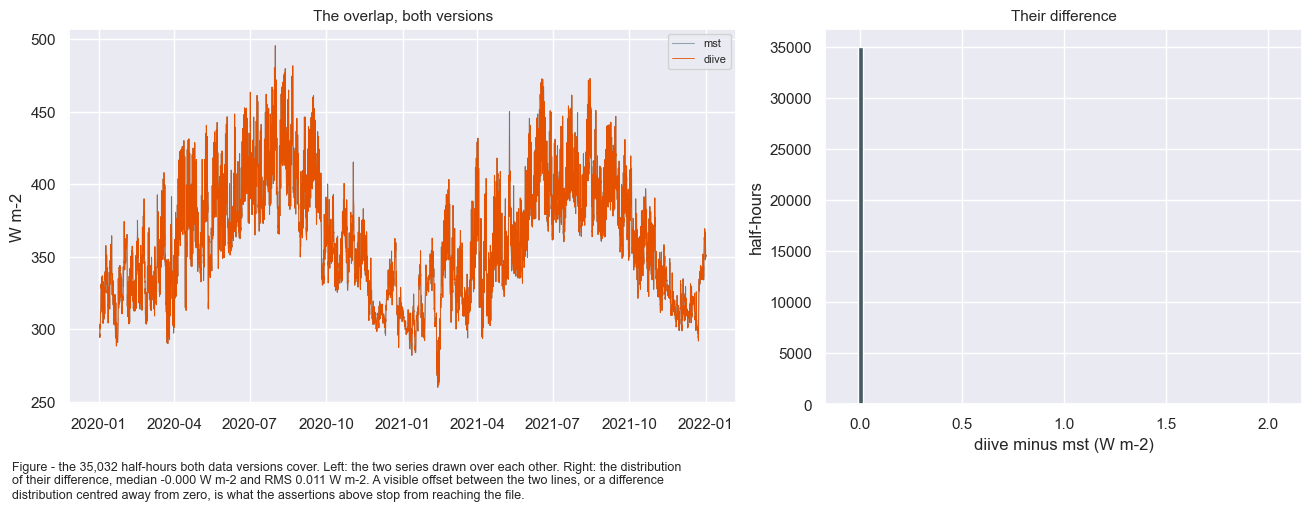

In [12]:
if OVERLAP is not None:
    fig, axs = plt.subplots(ncols=2, figsize=(13, 5), dpi=100, layout='constrained',
                            width_ratios=[1.4, 1])
    _step = max(1, len(_common) // 20000)
    axs[0].plot(_common[::_step], _a.values[::_step], color='#90A4AE', lw=0.8, label='mst')
    axs[0].plot(_common[::_step], _b.values[::_step], color='#E65100', lw=0.6, label='diive')
    axs[0].set_ylabel('W m-2')
    axs[0].set_title('The overlap, both versions', fontsize=11)
    axs[0].legend(fontsize=8)

    axs[1].hist(_d.values, bins=80, color='#455A64')
    axs[1].set_xlabel('diive minus mst (W m-2)')
    axs[1].set_ylabel('half-hours')
    axs[1].set_title('Their difference', fontsize=11)

    figcap(fig, f"the {len(_common):,} half-hours both data versions cover. Left: the two series "
                f"drawn over each other. Right: the distribution of their difference, median "
                f"{OVERLAP_BIAS:+.3f} W m-2 and RMS {float(np.sqrt((_d ** 2).mean())):.3f} W m-2. "
                f"A visible offset between the two lines, or a difference distribution centred "
                f"away from zero, is what the assertions above stop from reaching the file.")

***

## ❇️ Merge onto one continuous 30MIN index

The index starts at the first `LW_OUT` measurement rather than at 2004-01-01, because there is no
outgoing longwave before that date and none is reconstructed. `combine_first` resolves any overlap
in favour of `mst`, which is a fixed rule rather than a judgement.

Whether that choice matters depends on the section above. If the two versions were compared and
agreed, it does not, and the cell below says so. If they never overlap, the choice was never tested,
and the cell says that instead.

In [13]:
full_index = pd.date_range(f'{RECORD_START} 00:15:00', f'{RECORD_END} 23:45:00',
                           freq='30min', name='TIMESTAMP_MIDDLE')

# Nothing may be dropped by the reindex, at either end or from either version. A record outside
# the index would be silently lost, and the loss would look exactly like a record that never
# existed. The test is made against the RAW downloads, because by the time the merged frame exists
# anything outside the index has already gone.
_earliest = min(MST_FIRST, DIIVE_FIRST)
_latest = max(MST_LAST, DIIVE_LAST)
print(f"earliest record in either download: {_earliest}")
print(f"latest record in either download:   {_latest}")
assert _earliest >= full_index[0], (
    f"the earliest downloaded record is {_earliest}, before the index start {full_index[0]}, so "
    f"the reindex is truncating real data. Change RECORD_START, the notebook name and OUTNAME "
    f"together rather than letting records disappear")
assert _latest <= full_index[-1], (
    f"the latest downloaded record is {_latest}, after the index end {full_index[-1]}, so the "
    f"reindex is truncating real data. Change RECORD_END, the notebook name and OUTNAME together")

lw_2005_2025 = pd.DataFrame(index=full_index)
lw_2005_2025[TARGET] = (mst_lw[TARGET].reindex(full_index)
                        .combine_first(diive_lw[TARGET].reindex(full_index)))

print(f"{TARGET}: {lw_2005_2025[TARGET].notna().sum():,} of {len(lw_2005_2025):,} records "
      f"({100 * lw_2005_2025[TARGET].notna().mean():.2f}%)")
print(f"first measurement: {lw_2005_2025[TARGET].first_valid_index()}")
print(f"last measurement:  {lw_2005_2025[TARGET].last_valid_index()}")
if OVERLAP_PROVEN:
    print("combine_first resolved the overlap to mst, and the section above showed that the two "
          "versions agree there, so the choice does not change any value.")
else:
    print("(!) combine_first resolved any overlap to mst, but the two versions were never compared, "
          "so this splice is unverified.")

# RECORD_START is a claim about where this record begins, and this is where it is tested. The test
# is exact, because a tolerance of weeks would let the notebook's name, OUTNAME and this constant
# drift away from the data they describe.
_first = lw_2005_2025[TARGET].first_valid_index()
assert _earliest.date() == pd.Timestamp(RECORD_START).date(), (
    f"the earliest {TARGET} record in the downloads is {_earliest}, not on {RECORD_START} as this "
    f"notebook's name, OUTNAME and RECORD_START all claim. Change all three together, or find out "
    f"why the record moved. Do not relax this assertion")
assert _first == _earliest, (
    f"the first record on the exported index is {_first} but the earliest downloaded record is "
    f"{_earliest}, so the reindex has dropped data from the start of the record")

# The record count at the merge, and a place for each correction to say what it removed. The
# export cell checks the arithmetic against these rather than taking it on trust.
MEASURED_AT_MERGE = int(lw_2005_2025[TARGET].notna().sum())
REMOVALS = {}

tabcap("the merged series on its final 30MIN index, before any correction")
display(lw_2005_2025)

earliest record in either download: 2005-09-14 13:15:00
latest record in either download:   2025-12-31 23:45:00
LW_OUT_T1_47_1: 350,171 of 355,872 records (98.40%)
first measurement: 2005-09-14 13:15:00
last measurement:  2025-12-31 23:45:00
combine_first resolved the overlap to mst, and the section above showed that the two versions agree there, so the choice does not change any value.
Table - the merged series on its final 30MIN index, before any correction



,LW_OUT_T1_47_1
TIMESTAMP_MIDDLE,
2005-09-14 00:15:00,NaN
2005-09-14 00:45:00,NaN
2005-09-14 01:15:00,NaN
2005-09-14 01:45:00,NaN
2005-09-14 02:15:00,NaN
...,...
2025-12-31 21:45:00,298.233563
2025-12-31 22:15:00,297.949947
2025-12-31 22:45:00,297.206430


### 🌡️ The diagnostic series: air temperature and incoming longwave

Outgoing longwave is thermal emission from the canopy, and the canopy's temperature is close to the
temperature of the air above it. Air temperature at 47 m can therefore stand in for it, which gives
two derived quantities that the rest of the notebook uses.

- The **surface ratio** is `R = LW_OUT / (sigma * TA^4)`. It is not an emissivity, because it mixes
  two things: the canopy's true emissivity, which is near 0.98 for a forest, and the difference
  between the canopy's temperature and the air's. Its value is still pinned near 1 by physics, since
  a canopy cannot radiate at a temperature far from the air surrounding it. That is what makes it
  usable as a yardstick.
- The **outgoing net signal** is `LW_OUT - sigma * TA^4`. This approximates the quantity the
  pyrgeometer's voltage is actually proportional to, the approximation being that air temperature
  stands in for the instrument's body temperature. It matters because a calibration error acts on
  this quantity and on nothing else, and it is small: its median is a few W m-2 and its extremes a
  few tens, against a reported irradiance of several hundred. That is the reason a calibration
  error is hard to detect in this variable, and the cells below print the actual distribution
  rather than leaving it at an adjective.

Every calibration diagnostic below is restricted to nighttime records, for two reasons. A
pyrgeometer heats in sunlight, which adds an instrument effect that has nothing to do with the
questions being asked. And at night the canopy sits closest to the air temperature that is standing
in for it, so the substitution costs least. Records where `TA` was gap-filled are excluded as well,
because a modelled temperature would import the model's behaviour into a statement about an
instrument.

Of the two air-temperature columns the product offers, the homogenized one is used. Every comparison
below crosses January 2016, and before that date the measured column reads about 1.3 °C too cold,
which is about 7 W m-2 once put through `sigma * TA^4`. That is the same size as the changes being
looked for, so it cannot be ignored. Notebook `02` removes it with two terms: a constant applied to
the earlier era, and a radiation-dependent term applied to the later one. The second term is zero in
the dark by construction. Since every diagnostic here is a nighttime statistic, the choice between
the two columns can only affect the earlier era, and the cell below asserts that this is still
true.

In [14]:
SIGMA = 5.670374419e-8  # Stefan-Boltzmann, W m-2 K-4

_ta_product = pd.read_parquet(TA_PRODUCT)
assert {TA_COL, TA_MEASURED_COL, TA_FLAG}.issubset(_ta_product.columns), \
    f"the TA product does not carry {TA_COL} / {TA_MEASURED_COL} / {TA_FLAG} - has 02 changed?"

TA_DIAG = _ta_product[TA_COL].reindex(full_index)
TA_IS_MEASURED = (_ta_product[TA_FLAG] == 0).reindex(full_index).fillna(False)
SIGMA_T4 = SIGMA * (TA_DIAG + 273.15) ** 4

# Potential radiation: astronomical, so it cannot drift, which is what makes it a safe selector for
# night. A measured radiation series would put its own behaviour into the selection.
POTRAD = dv.variables.potrad(timestamp_index=full_index, lat=SITE_LAT, lon=SITE_LON,
                             utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)
DARK = POTRAD <= 0
# A half-hour counts as night only if the half-hours on either side of it are dark too. Potential
# radiation is evaluated at the middle of the bin, so a bin whose own midpoint is dark can still
# hold up to fifteen minutes of sun, and every calibration diagnostic below is a nighttime
# statistic that a quarter-hour of sun on the sensor would contaminate. Same rule as 30_PRODUCTS/12.
FULLY_DARK = DARK & DARK.shift(1, fill_value=True) & DARK.shift(-1, fill_value=True)
NIGHT = FULLY_DARK

_homog_gap = (_ta_product[TA_COL] - _ta_product[TA_MEASURED_COL]).reindex(full_index)
print(f"TA product: {TA_COL}")
print(f"  measured share on this index: {100 * TA_IS_MEASURED.mean():.2f} %")
print(f"  homogenized minus measured, at night, before 2016: "
      f"{_homog_gap.where(NIGHT).loc[:'2015'].median():+.4f} degC   "
      f"after 2016: {_homog_gap.where(NIGHT).loc['2017':].abs().max():+.4f} degC")
print(f"  that is {4 * SIGMA * (283.15 ** 3) * float(_homog_gap.where(NIGHT).loc[:'2015'].median()):.1f}"
      f" W m-2 in sigma*TA^4")
print(f"dark half-hours on this index: {int(DARK.sum()):,} of {len(full_index):,}; "
      f"fully dark, which is what NIGHT means here: {int(NIGHT.sum()):,}")

assert TA_IS_MEASURED.mean() > 0.9, "the TA product is now mostly modelled on this index"
assert float(_homog_gap.where(NIGHT).loc['2017':].abs().max()) == 0.0, \
    "the TA homogenization now modifies the later era at night as well, so the nighttime "\
    "diagnostics below no longer rest on one constant offset between the two columns"
assert _homog_gap.where(NIGHT).loc[:'2015'].round(6).nunique() == 1, \
    "the earlier era's homogenization is no longer one constant at night"

_lw_in_product = pd.read_parquet(LW_IN_PRODUCT)
assert {LW_IN_COL, LW_IN_FLAG}.issubset(_lw_in_product.columns), \
    f"the LW_IN product does not carry {LW_IN_COL} / {LW_IN_FLAG} - has notebook 06 changed?"
LW_IN_DIAG = _lw_in_product[LW_IN_COL].reindex(full_index)
print(f"\nLW_IN product: {LW_IN_COL}, {100 * LW_IN_DIAG.notna().mean():.2f} % present on this index")


def surface_ratio(series: pd.Series) -> pd.Series:
    """LW_OUT / (sigma*TA^4), on records where TA was measured."""
    return (series / SIGMA_T4).where(TA_IS_MEASURED & series.notna() & TA_DIAG.notna())


def outgoing_net(series: pd.Series) -> pd.Series:
    """LW_OUT minus sigma*TA^4, on records where TA was measured."""
    return (series - SIGMA_T4).where(TA_IS_MEASURED & series.notna() & TA_DIAG.notna())

TA product: TA_T1_47_1_HOMOGENIZED_gfXG
  measured share on this index: 98.88 %
  homogenized minus measured, at night, before 2016: +1.3197 degC   after 2016: +0.0000 degC
  that is 6.8 W m-2 in sigma*TA^4
dark half-hours on this index: 170,475 of 355,872; fully dark, which is what NIGHT means here: 155,647

LW_IN product: LW_IN_T1_47_1, 98.62 % present on this index


### 📊 Plot: the merged series

This variable has a clear daily cycle, because the canopy heats in the sun and cools at night and
its thermal emission follows. The corrections section makes use of that cycle: a series with a daily
rhythm can be tested against the position of the sun, which is how the August 2012 clock error is
verified below.

Mean diurnal cycle peaks at 14:15:00 local time.


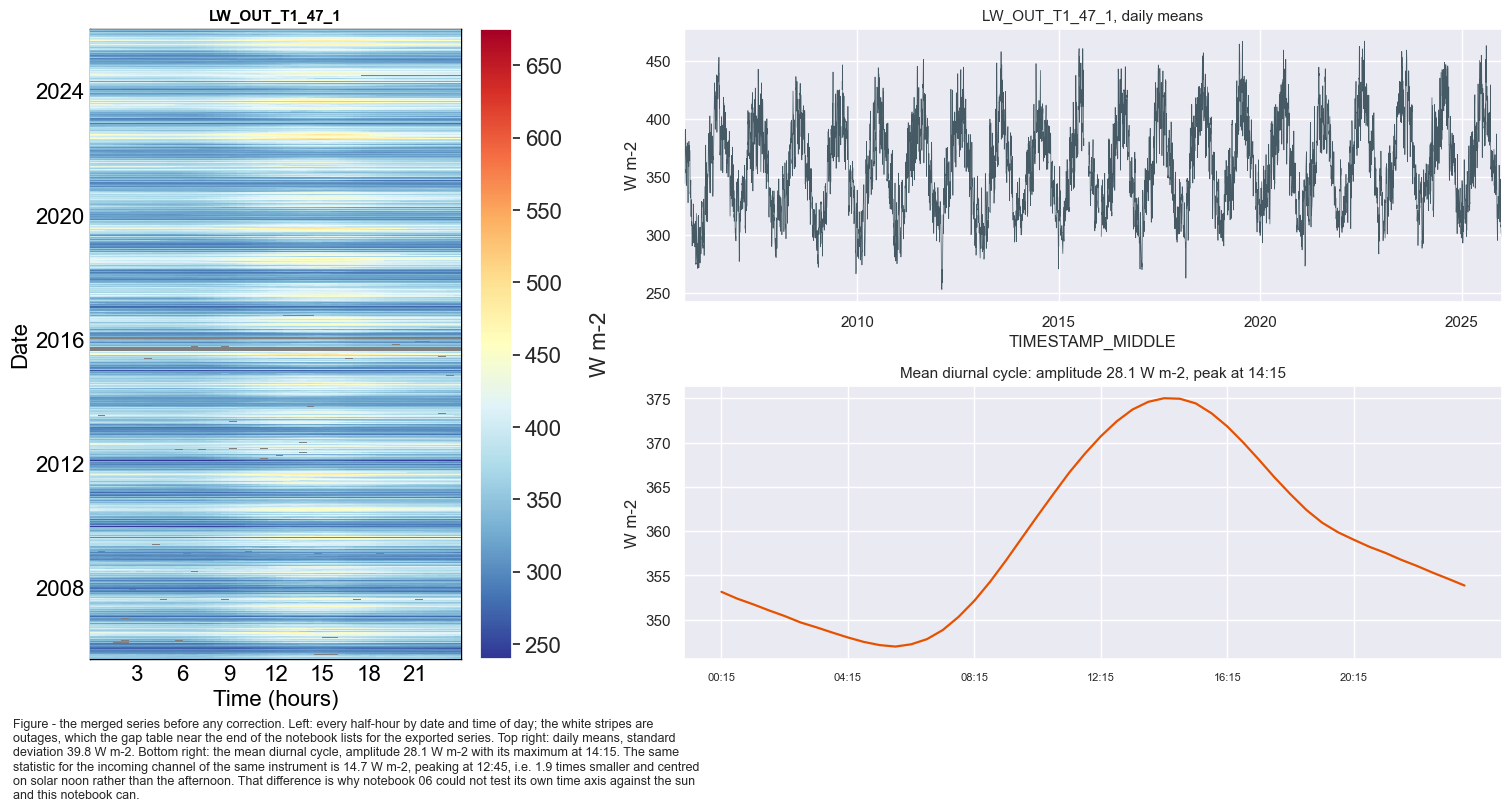

In [15]:
fig = plt.figure(figsize=(15, 8), dpi=100, layout='constrained')
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2.2], figure=fig)
ax_hm = fig.add_subplot(gs[:, 0])
ax_ts = fig.add_subplot(gs[0, 1])
ax_di = fig.add_subplot(gs[1, 1])

dv.plotting.HeatmapDateTime(series=lw_2005_2025[TARGET]).plot(
    ax=ax_hm, cb_digits_after_comma=0, zlabel='W m-2',
    format_style=dv.plotting.FormatStyle(title=f'{TARGET}', title_fontsize=11))

lw_2005_2025[TARGET].resample('1D').mean().plot(ax=ax_ts, lw=0.5, color='#455A64')
ax_ts.set_ylabel('W m-2')
ax_ts.set_title(f'{TARGET}, daily means', fontsize=11)

_dc = lw_2005_2025[TARGET]
_dc = _dc.groupby(_dc.index.time).mean()
ax_di.plot(range(len(_dc)), _dc.values, color='#E65100', lw=1.6)
ax_di.set_xticks(range(0, len(_dc), 8))
ax_di.set_xticklabels([str(t)[:5] for t in _dc.index[::8]], fontsize=8)
ax_di.set_ylabel('W m-2')
_peak = _dc.idxmax()
ax_di.set_title(f'Mean diurnal cycle: amplitude {_dc.max() - _dc.min():.1f} W m-2, '
                f'peak at {str(_peak)[:5]}', fontsize=11)

_daily_sd = lw_2005_2025[TARGET].resample('1D').mean().std()
# The comparison against the incoming channel is computed rather than asserted in prose, because
# the claim that 06 could not test its own time axis rests on the size of its diurnal cycle.
_dc_in = LW_IN_DIAG.groupby(LW_IN_DIAG.index.time).mean()
_amp_out = float(_dc.max() - _dc.min())
_amp_in = float(_dc_in.max() - _dc_in.min())
figcap(fig, f"the merged series before any correction. Left: every half-hour by date and time of "
            f"day; the white stripes are outages, which the gap table near the end of the notebook "
            f"lists for the exported series. Top right: "
            f"daily means, standard deviation {_daily_sd:.1f} W m-2. Bottom right: the mean "
            f"diurnal cycle, amplitude {_amp_out:.1f} W m-2 with its maximum at "
            f"{str(_peak)[:5]}. The same statistic for the incoming channel of the same instrument "
            f"is {_amp_in:.1f} W m-2, peaking at {str(_dc_in.idxmax())[:5]}, i.e. "
            f"{_amp_out / _amp_in:.1f} times smaller and centred on solar noon rather than the "
            f"afternoon. That difference is why notebook 06 could not test its own time axis "
            f"against the sun and this notebook can.")

# The afternoon peak is a statement about the time axis. A canopy warms through the morning and
# cools once the sun drops, so its emission peaks in the early to middle afternoon.
assert pd.Timestamp('1900-01-01 11:00').time() <= _peak <= pd.Timestamp('1900-01-01 18:00').time(), (
    f"the mean diurnal maximum of {TARGET} falls at {_peak}, outside the afternoon a canopy's "
    f"emission peaks in. Check the time axis before the sensor")
print(f"Mean diurnal cycle peaks at {_peak} local time.")

***

## ✴️ Corrections

The steps run in a fixed order, and the order matters because it decides what the exported flags
describe. First the timestamps of the mis-stamped block are corrected, then the periods covered by
documented faults are removed, and then any physically impossible record is removed. No value is
altered anywhere in this notebook.

One consequence is worth stating because it has gone wrong before. Every step here can only set a
value to `NaN`, so no step can write a value into a record that was previously missing. In notebook
`03` a correction did exactly that, and 7,543 modelled values ended up looking like measurements.

### Timestamp shift in August 2012

**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

The fault was in the logger's clock, so it mis-stamped every variable that logger was recording at
the time. `LW_OUT_T1_47_1` is measured on tower 1 at 47 m, on the same acquisition system as
`SW_IN_T1_47_1`, `TA_T1_47_1`, `PPFD_IN_T1_47_1`, `PA_T1_47_1` and `LW_IN_T1_47_1`, and those
variables carry a `+15.5 h` correction in their own notebooks. The same correction is applied here.

The entry's own arithmetic does not give 15.5 h. Server time 17.08.2012 12:31 against logger time
16.08.2012 08:06 is a lag of 28 h 25 min, and the two figures have never been reconciled: the
+15.5 h used across this stage is a site convention inherited from the earlier notebooks, not a
number derived from this entry. Rather than repeat either figure on trust, the cells below apply
+15.5 h and then ask the data which shift puts the block back on the sun's clock.

Unlike notebook `06`, this notebook can then check that the correction is the right size. Potential
radiation is computed from the position of the sun, so it cannot drift and cannot be affected by
anything at the site. This variable follows the sun, although it lags behind it because the canopy
takes time to warm and cool. If the mis-stamped block is shifted by a range of trial amounts and
each shifted version is correlated against potential radiation, the correlation reaches a maximum at
the shift that puts the block back on the sun's clock.

The canopy's lag moves that maximum, so it has to be accounted for. Rather than assume a value for
it, the cell measures it on days whose timestamps are known to be correct, and then expects the
block's maximum at 15.5 h plus that measured lag. The test therefore calibrates itself against the
same variable it is testing.

In [16]:
ISSUE_START = '2012-08-09 00:00'
ISSUE_END = '2012-08-17 00:00'
SHIFT_HOURS = 15.5
CLEAN_WINDOW = ('2012-08-19 00:00', '2012-09-05 00:00')   # after the fault, before the storm damage

_df = lw_2005_2025.copy()
_before = _df[TARGET].copy()   # kept for the before/after plot and for the lag scan

# Take the mis-stamped block and move it onto the correct time axis.
_series_shifted = _df.loc[ISSUE_START:ISSUE_END, TARGET].dropna()
if len(_series_shifted) > 0:
    _series_shifted.index = _series_shifted.index + pd.Timedelta(hours=SHIFT_HOURS)
    # Clear everything between the start of the issue and the last shifted timestamp, then write
    # the corrected values back. Same procedure as notebooks 01-03, 05 and 06.
    _df.loc[ISSUE_START:_series_shifted.index[-1], TARGET] = np.nan
    _df.loc[_series_shifted.index, TARGET] = _series_shifted
    print(f"shifted {len(_series_shifted):,} records by +{SHIFT_HOURS} h")
    print(f"last shifted timestamp (corrected axis): {_series_shifted.index[-1]}")
else:
    print(f"no records between {ISSUE_START} and {ISSUE_END}: the shift moves nothing, and the "
          f"verification below is skipped")

lw_2005_2025 = _df.copy()

shifted 376 records by +15.5 h
last shifted timestamp (corrected axis): 2012-08-17 11:15:00


In [17]:
def potrad_lag_profile(series, window, shifts):
    """Correlation of a block of `series` with potential radiation, as a function of shift.

    The block keeps its own values and is looked up against potential radiation at timestamps moved
    by `shift` hours. The maximum marks the shift that puts the block back on the sun's clock.
    Raises rather than returning a thin profile: a correlation from a handful of half-hours reads
    exactly like one from a thousand.
    """
    block = series.loc[window[0]:window[1]].dropna()
    out = {}
    for _s in shifts:
        _idx = block.index + pd.Timedelta(hours=float(_s))
        _pot = POTRAD.reindex(_idx)
        _pair = pd.DataFrame({'lw': block.to_numpy(), 'pot': _pot.to_numpy()}).dropna()
        if len(_pair) < 100:
            continue
        out[float(_s)] = float(_pair['lw'].corr(_pair['pot']))
    if len(out) < 5:
        raise ValueError(f"only {len(out)} usable shifts over {window} - too little data to locate "
                         f"a maximum")
    profile = pd.Series(out).sort_index()
    if 0.0 not in profile.index:
        raise ValueError(f"the zero shift was filtered out of the profile over {window}, so the "
                         f"maximum cannot be read against the uncorrected series")
    return profile


def profile_prominence(profile: pd.Series) -> float:
    """How far the maximum of a lag profile stands above the rest of it.

    A maximum located on a flat profile is not located at all. This is the height of the peak above
    the median of the profile, in correlation units, and the cells below refuse a peak that does
    not clear a stated prominence.
    """
    return float(profile.max() - profile.median())


if len(_series_shifted) > 0:
    # The canopy's own lag, measured on days whose timestamps are known to be right.
    _clean_profile = potrad_lag_profile(lw_2005_2025[TARGET], CLEAN_WINDOW,
                                        np.arange(-6, 6.5, 0.5))
    NATURAL_LAG = float(_clean_profile.idxmax())
    # The mis-stamped block, scanned over a whole day of candidate shifts, on the values as they
    # were stored.
    _block_profile = potrad_lag_profile(_before, (ISSUE_START, ISSUE_END), np.arange(0, 24.5, 0.5))
    BEST_SHIFT = float(_block_profile.idxmax())
    EXPECTED_SHIFT = SHIFT_HOURS + NATURAL_LAG

    MIN_PROMINENCE = 0.05   # correlation units; a peak flatter than this locates nothing
    _clean_prom = profile_prominence(_clean_profile)
    _block_prom = profile_prominence(_block_profile)

    tabcap("what the mis-stamped block does against potential radiation. The canopy lag is "
           "measured on clean days and then subtracted, so the test does not have to assume it. "
           "The prominence column is how far each maximum stands above the median of its own "
           "profile, because a maximum on a flat profile locates nothing")
    display(pd.DataFrame({
        'shift at maximum correlation (h)': [NATURAL_LAG, BEST_SHIFT],
        'maximum correlation': [round(float(_clean_profile.max()), 4),
                                round(float(_block_profile.max()), 4)],
        'correlation at zero shift': [round(float(_clean_profile[0.0]), 4),
                                      round(float(_block_profile[0.0]), 4)],
        'prominence': [round(_clean_prom, 4), round(_block_prom, 4)],
    }, index=[f'clean days {CLEAN_WINDOW[0][:10]} to {CLEAN_WINDOW[1][:10]}',
              f'mis-stamped block {ISSUE_START[:10]} to {ISSUE_END[:10]}']))

    for _label, _prom in [('clean days', _clean_prom), ('mis-stamped block', _block_prom)]:
        assert _prom >= MIN_PROMINENCE, (
            f"the lag profile of the {_label} peaks only {_prom:.4f} above its own median, which "
            f"is flat enough that the shift at the maximum is not located. The verification below "
            f"would then be reading noise")

    print(f"canopy lag on clean days:      {NATURAL_LAG:+.1f} h")
    print(f"expected maximum for the block: {EXPECTED_SHIFT:+.1f} h "
          f"(= {SHIFT_HOURS} h clock error {NATURAL_LAG:+.1f} h canopy lag)")
    print(f"measured maximum for the block: {BEST_SHIFT:+.1f} h")
    print(f"departure: {BEST_SHIFT - EXPECTED_SHIFT:+.1f} h")

    assert abs(BEST_SHIFT - EXPECTED_SHIFT) <= 1.5, (
        f"the mis-stamped block aligns best with the sun at {BEST_SHIFT:+.1f} h, not at the "
        f"{EXPECTED_SHIFT:+.1f} h the fieldbook's clock error and this canopy's own lag predict. "
        f"The shift applied above is then the wrong size, or the block is the wrong block")
    assert _block_profile.max() > _block_profile[0.0] + 0.1, (
        "the block correlates with the sun no better after the shift than before it, so this test "
        "has not confirmed anything and the shift rests on provenance alone")
    print("\nThe shift is confirmed against solar geometry.")

Table - what the mis-stamped block does against potential radiation. The canopy lag is measured on
clean days and then subtracted, so the test does not have to assume it. The prominence column is how
far each maximum stands above the median of its own profile, because a maximum on a flat profile
locates nothing



,shift at maximum correlation (h),maximum correlation,correlation at zero shift,prominence
clean days 2012-08-19 to 2012-09-05,-2.0,0.4084,0.3483,0.1371
mis-stamped block 2012-08-09 to 2012-08-17,13.0,0.7772,-0.7378,0.8226


canopy lag on clean days:      -2.0 h
expected maximum for the block: +13.5 h (= 15.5 h clock error -2.0 h canopy lag)
measured maximum for the block: +13.0 h
departure: -0.5 h

The shift is confirmed against solar geometry.


### 📊 Plot: the August 2012 clock shift

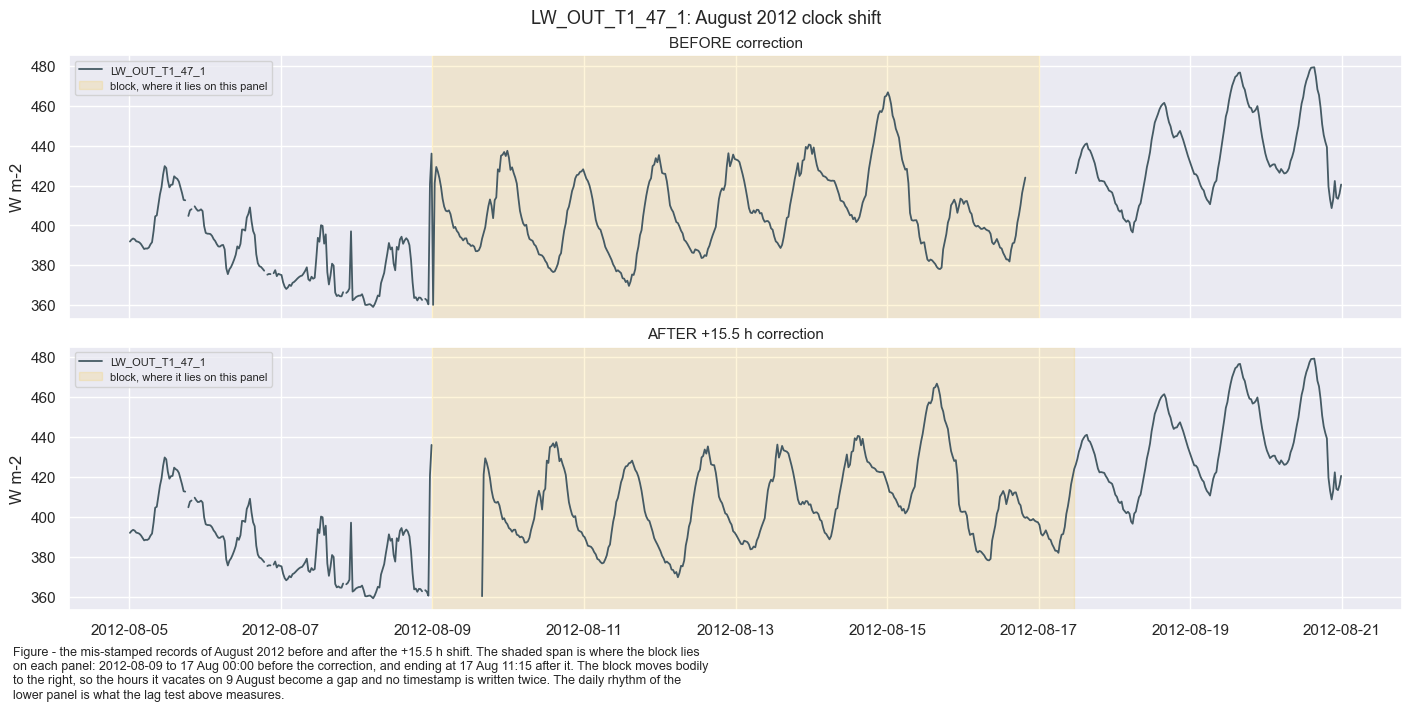

In [18]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 7), dpi=100, layout='constrained',
                        sharex=True, sharey=True)
fig.suptitle(f'{TARGET}: August 2012 clock shift', fontsize=13)
_win = slice('2012-08-05', '2012-08-20')

# The shaded span differs between the panels, because that is the whole point of the figure: the
# block occupies ISSUE_START to ISSUE_END before the correction and ends at the last shifted stamp
# after it. Drawing one hard-coded span on both panels would contradict the caption.
_span_end = _series_shifted.index[-1] if len(_series_shifted) > 0 else pd.Timestamp(ISSUE_END)
for _ax, _series, _title, _end in [
        (axs[0], _before, 'BEFORE correction', pd.Timestamp(ISSUE_END)),
        (axs[1], lw_2005_2025[TARGET], f'AFTER +{SHIFT_HOURS} h correction', _span_end)]:
    _ax.plot(_series.loc[_win].index, _series.loc[_win].values, color='#455A64', lw=1.3,
             label=TARGET)
    _ax.axvspan(pd.Timestamp(ISSUE_START), _end, color='#FFC107', alpha=.15,
                label='block, where it lies on this panel')
    _ax.set_title(_title, fontsize=11)
    _ax.set_ylabel('W m-2')
    _ax.legend(fontsize=8, loc='upper left')

figcap(fig, f"the mis-stamped records of August 2012 before and after the +{SHIFT_HOURS} h shift. "
            f"The shaded span is where the block lies on each panel: {ISSUE_START[:10]} to "
            f"{pd.Timestamp(ISSUE_END):%d %b %H:%M} before the correction, and ending at "
            f"{_span_end:%d %b %H:%M} after it. The block moves bodily to the right, so the hours "
            f"it vacates on 9 August become a gap and no timestamp is written twice. The daily "
            f"rhythm of the lower panel is what the lag test above measures.")

### Damaged periods in 2012

Notebooks `01`, `02`, `03` and `06` remove three windows in 2012, caused by a tower power supply
failure in late July and early August and by storm damage and stressed cables in late October and
early November. Both are documented in the fieldbook:

> **09.08.2012** Fixed the power problem on the tower: replaced battery and replaced some fuses
> (there were many falsely placed or broken) and replaced the whole power supply
>
> **01.11.2012** Checked Forestfloor and Hut for broken sensors due to fallen trees and big branches
>
> **06.11.2012** checked all sensor cables. especialy the cables at the forest floor are sometimes
> strongly stressed. tried to unstress the cables

The cell below first computes what this variable actually shows inside those windows, and compares
it against the clean weeks that precede them. The windows are then removed regardless of the result,
on the same grounds as in `06`. A documented fault covers a sensor on the affected logger, and this
variable has no reference instrument that could reveal a level error if one were present. Keeping
the data would mean trusting a test that is known to be too weak to detect the fault being asked
about.

Narrowing a window is a different matter, because it requires positive evidence that the narrower
part is clean. Notebook `05` had such evidence for `PA`, from an independent barometer. Here there
is none, so the windows stay as wide as in `01` to `03` and `06`.

In [19]:
# Identical to notebooks 01-03 and 06. Windows are on the CORRECTED time axis.
BAD_WINDOWS_2012 = [
    ('2012-07-29 00:00', '2012-08-10 15:30'),  # tower power supply failure (fieldbook 09.08.2012)
    ('2012-08-17 15:30', '2012-08-18 00:00'),  # transitional tail after the last shifted value
    ('2012-10-28 00:00', '2012-11-10 00:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]

_ratio_2012 = surface_ratio(lw_2005_2025[TARGET])
_rows = []
for _lo, _hi, _lab in [('2012-06-01', '2012-07-25', 'baseline 1 Jun - 25 Jul'),
                       ('2012-07-29', '2012-08-10', 'window 1 (power supply)'),
                       ('2012-10-28', '2012-11-10', 'window 3 (storm damage)')]:
    _r = _ratio_2012.loc[_lo:_hi].dropna()
    _v = lw_2005_2025.loc[_lo:_hi, TARGET].dropna()
    _rows.append({'period': _lab, 'n': len(_r),
                  'surface ratio median': round(float(_r.median()), 4),
                  'surface ratio min': round(float(_r.min()), 4),
                  'surface ratio max': round(float(_r.max()), 4),
                  'records per day': round(len(_v) / max(1, (pd.Timestamp(_hi) - pd.Timestamp(_lo)).days), 1),
                  'repeated values': int(_v.diff().eq(0).sum())})
tabcap("what the two suspect 2012 windows look like from inside this variable, against the clean "
       "weeks before them")
display(pd.DataFrame(_rows).set_index('period'))

_before_n = int(lw_2005_2025[TARGET].notna().sum())
for _start, _end in BAD_WINDOWS_2012:
    lw_2005_2025.loc[_start:_end, TARGET] = np.nan
REMOVALS['damaged periods in 2012'] = _before_n - int(lw_2005_2025[TARGET].notna().sum())
N_2012 = REMOVALS['damaged periods in 2012']
print(f"Removed {N_2012:,} records on provenance grounds (left as gaps, nothing is filled).")

Table - what the two suspect 2012 windows look like from inside this variable, against the clean
weeks before them



,n,surface ratio median,surface ratio min,surface ratio max,records per day,repeated values
period,,,,,,
baseline 1 Jun - 25 Jul,2623,0.9809,0.9340,1.0225,48.6,0
window 1 (power supply),17,0.9714,0.9653,0.9974,48.2,0
window 3 (storm damage),48,0.9718,0.9531,0.9861,51.6,0


Removed 1,202 records on provenance grounds (left as gaps, nothing is filled).


### 📊 Plot: the 2012 periods removed

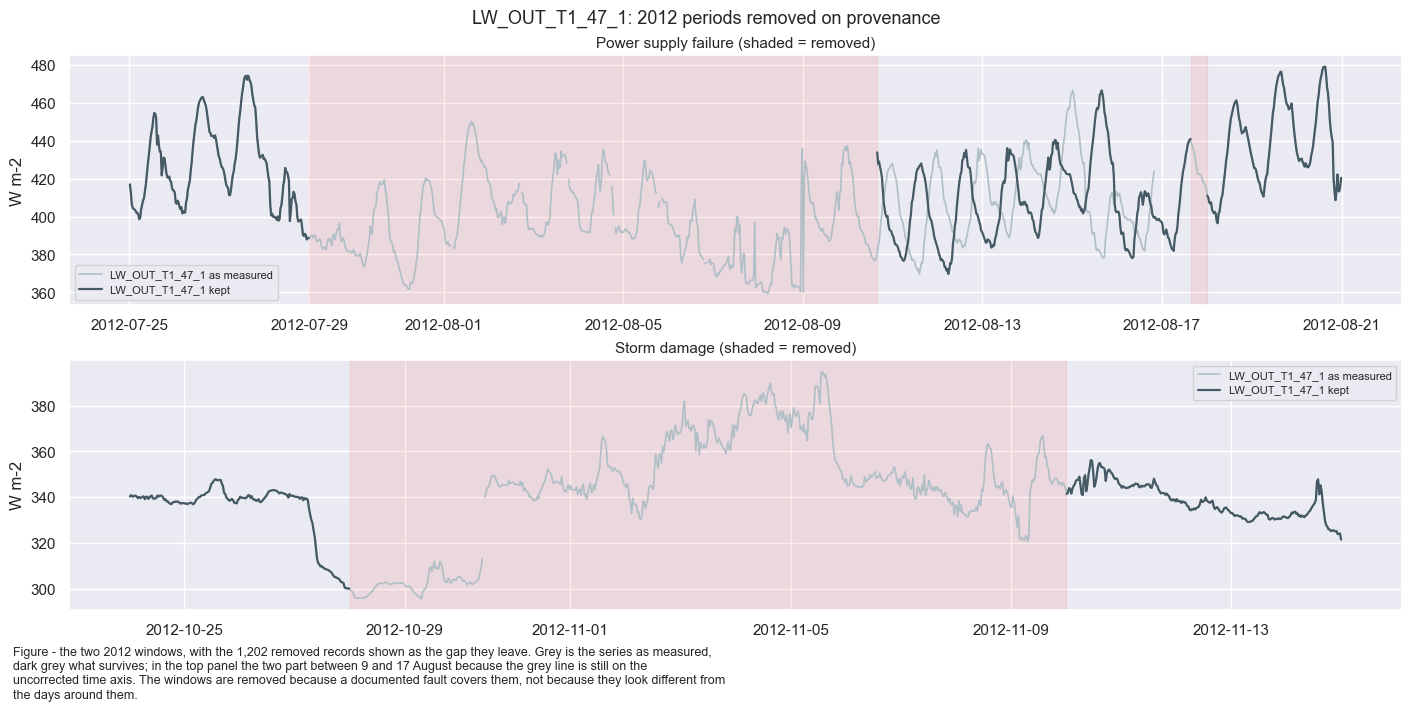

In [20]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 7), dpi=100, layout='constrained')
fig.suptitle(f'{TARGET}: 2012 periods removed on provenance', fontsize=13)

for _ax, (_lo, _hi, _label) in zip(axs, [('2012-07-25', '2012-08-20', 'Power supply failure'),
                                         ('2012-10-24', '2012-11-14', 'Storm damage')]):
    _w = slice(_lo, _hi)
    _ax.plot(_before.loc[_w].index, _before.loc[_w].values, color='#B0BEC5', lw=1.2,
             label=f'{TARGET} as measured')
    _ax.plot(lw_2005_2025[TARGET].loc[_w].index, lw_2005_2025[TARGET].loc[_w].values,
             color='#455A64', lw=1.6, label=f'{TARGET} kept')
    for _s, _e in BAD_WINDOWS_2012:
        if pd.Timestamp(_s) <= pd.Timestamp(_hi) and pd.Timestamp(_e) >= pd.Timestamp(_lo):
            _ax.axvspan(pd.Timestamp(_s), pd.Timestamp(_e), color='#F44336', alpha=.10)
    _ax.set_title(f'{_label} (shaded = removed)', fontsize=11)
    _ax.set_ylabel('W m-2')
    _ax.legend(fontsize=8, loc='best')

figcap(fig, f"the two 2012 windows, with the {N_2012:,} removed records shown as the gap they "
            f"leave. Grey is the series as measured, dark grey what survives; in the top panel the "
            f"two part between 9 and 17 August because the grey line is still on the uncorrected "
            f"time axis. The windows are removed because a documented fault covers them, not "
            f"because they look different from the days around them.")

### Physically implausible records

The screening notebooks apply absolute limits to the raw high-resolution record. Those limits are
set wide on purpose, so that they catch the large excursion of a sensor being handled without
touching real weather. Because they are wide, a half-hourly mean can sit well below anything a
surface can physically emit and still pass them.

This cell applies the physical band instead, on the resampled record, and reports what it finds
before removing it. Finding nothing is the expected outcome, and it is worth as much as finding
something: it says the screening left no physically impossible value behind.

In [21]:
_lo, _hi = LW_OUT_PLAUSIBLE_WM2
_implausible = lw_2005_2025[TARGET].notna() & ((lw_2005_2025[TARGET] < _lo)
                                               | (lw_2005_2025[TARGET] > _hi))
print(f"Records outside {_lo:.0f}-{_hi:.0f} W m-2: {int(_implausible.sum())}")

if int(_implausible.sum()) > 0:
    tabcap("every record the physical band rejects, with the air temperature and the incoming "
           "longwave of the same half-hour beside it")
    _bad_idx = _implausible[_implausible].index
    display(pd.DataFrame({
        TARGET: lw_2005_2025.loc[_bad_idx, TARGET].round(2),
        'TA (degC)': TA_DIAG.loc[_bad_idx].round(2),
        'sigma*TA^4 (W m-2)': SIGMA_T4.loc[_bad_idx].round(1),
        f'{LW_IN_COL} (W m-2)': LW_IN_DIAG.loc[_bad_idx].round(1),
    }).head(50))
else:
    print("Nothing to remove: the merged record is physically plausible throughout.")

# A band that rejects a large share of the record is mis-set rather than strict.
_share = float(_implausible.sum()) / max(1, int(lw_2005_2025[TARGET].notna().sum()))
assert _share < 0.001, (
    f"the physical band rejects {100 * _share:.2f} % of the measured record. Two causes are worth "
    f"checking before the band is widened: a data version that stored the pyrgeometer's net signal "
    f"rather than irradiance, which would sit near zero, and a scaling error")

lw_2005_2025.loc[_implausible, TARGET] = np.nan
REMOVALS['records outside the physical band'] = int(_implausible.sum())
N_IMPLAUSIBLE = REMOVALS['records outside the physical band']
print(f"\nRemoved {N_IMPLAUSIBLE} record(s), left as gaps.")

Records outside 150-600 W m-2: 1
Table - every record the physical band rejects, with the air temperature and the incoming longwave
of the same half-hour beside it



,LW_OUT_T1_47_1,TA (degC),sigma*TA^4 (W m-2),LW_IN_T1_47_1 (W m-2)
TIMESTAMP_MIDDLE,,,,
2013-07-22 05:45:00,675.44,20.23,420.1,NaN



Removed 1 record(s), left as gaps.


### The radiometer exchange on 14 December 2021

The fieldbook records the CNR1 coming down and the CNR4 going up on this day. While an instrument is
unmounted and handled, its downward-facing pyrgeometer is not looking at the canopy, so what it
reports during that time can be a perfectly plausible number and still not be a measurement of this
site. Absolute limits cannot catch that, which is why the exchange needs its own step.

The step is a rule rather than a hand-drawn window, so that a re-run re-derives it from the data.
Each half-hour of the installation day is compared against the same time of day on the seven days
before and the seven days after, and a half-hour is removed only if it falls outside the range those
days span. Fourteen winter days give a wide range, so the rule removes a gross excursion and leaves
everything else alone. It can also remove nothing at all, which is a valid result and is reported as
one. Either way, the whole of that day carries the undetermined code of the exported flag.

In [22]:
HALO_DAYS = 7
_ratio_all = surface_ratio(lw_2005_2025[TARGET])
_halo_lo = pd.Timestamp(CNR4_INSTALLED) - pd.Timedelta(days=HALO_DAYS)
_halo_hi = pd.Timestamp(CNR4_INSTALLED) + pd.Timedelta(days=HALO_DAYS + 1)

# A time of day represented by one or two halo days gives a range of nearly zero width, which
# would flag the installation day almost whatever it did. Those times of day are left unjudged.
MIN_HALO_DAYS = 6

_halo = _ratio_all.loc[_halo_lo:_halo_hi]
_halo = _halo[_halo.index.normalize() != pd.Timestamp(CNR4_INSTALLED)].dropna()
_env = _halo.groupby(_halo.index.time).agg(['min', 'max', 'count'])
_supported = _env[_env['count'] >= MIN_HALO_DAYS]

_day = _ratio_all.loc[CNR4_INSTALLED]
_env_lo = pd.Series([_supported['min'].get(t.time(), np.nan) for t in _day.index], index=_day.index)
_env_hi = pd.Series([_supported['max'].get(t.time(), np.nan) for t in _day.index], index=_day.index)
_judgeable = _day.notna() & _env_lo.notna() & _env_hi.notna()
_excursion = (_judgeable & ((_day < _env_lo) | (_day > _env_hi))).fillna(False)

print(f"envelope built from {len(_halo):,} half-hours on the {2 * HALO_DAYS} days around "
      f"{CNR4_INSTALLED}")
print(f"times of day with at least {MIN_HALO_DAYS} halo days behind them: {len(_supported)} of "
      f"{len(_env)}")
print(f"half-hours on {CNR4_INSTALLED} with a usable ratio: {int(_day.notna().sum())} of "
      f"{len(_day)} (a ratio needs a measured TA)")
print(f"half-hours that can be judged against a supported envelope: {int(_judgeable.sum())}")
print(f"half-hours outside the envelope: {int(_excursion.sum())}")

if int(_excursion.sum()) > 0:
    # _excursion covers one day only, so it cannot index the full frame as a boolean mask; the
    # timestamps it selects can.
    _exc_idx = _excursion[_excursion].index
    tabcap("the half-hours of the installation day outside the range the surrounding fortnight "
           "spans at the same time of day, with that range beside them")
    display(pd.DataFrame({
        TARGET: lw_2005_2025.loc[_exc_idx, TARGET].round(2),
        'surface ratio': _day.loc[_exc_idx].round(4),
        'envelope min': _env_lo.loc[_exc_idx].round(4),
        'envelope max': _env_hi.loc[_exc_idx].round(4),
    }))
else:
    print("Nothing outside the envelope at 30MIN resolution.")

# The rule is bounded to one day by construction; this stops it emptying that day. The
# denominator is the number of half-hours it could judge, not the 48 in a day.
assert int(_excursion.sum()) <= max(1, int(_judgeable.sum()) // 2), (
    f"the envelope rule removes {int(_excursion.sum())} of the {int(_judgeable.sum())} half-hours "
    f"it can judge on {CNR4_INSTALLED}. Removing more than half of them is a day-long fault rather "
    f"than an excursion around an exchange, and it needs adjudicating rather than filtering")

lw_2005_2025.loc[_excursion[_excursion].index, TARGET] = np.nan
REMOVALS['the radiometer exchange excursion'] = int(_excursion.sum())
N_EXCURSION = REMOVALS['the radiometer exchange excursion']
print(f"\nRemoved {N_EXCURSION} record(s) on {CNR4_INSTALLED}.")

envelope built from 672 half-hours on the 14 days around 2021-12-14
times of day with at least 6 halo days behind them: 48 of 48
half-hours on 2021-12-14 with a usable ratio: 42 of 48 (a ratio needs a measured TA)
half-hours that can be judged against a supported envelope: 42
half-hours outside the envelope: 10
Table - the half-hours of the installation day outside the range the surrounding fortnight spans at
the same time of day, with that range beside them



,LW_OUT_T1_47_1,surface ratio,envelope min,envelope max
TIMESTAMP_MIDDLE,,,,
2021-12-14 03:45:00,307.69,0.9826,0.9835,1.0075
2021-12-14 04:15:00,306.57,0.9770,0.9828,1.0067
2021-12-14 04:45:00,308.32,0.9833,0.9838,1.0057
2021-12-14 05:15:00,306.87,0.9816,0.9833,1.0065
2021-12-14 05:45:00,305.87,0.9791,0.9819,1.0067
2021-12-14 06:15:00,306.71,0.9814,0.9832,1.0064
2021-12-14 06:45:00,304.53,0.9823,0.9845,1.0067
2021-12-14 07:45:00,304.50,0.9826,0.9829,1.0076
2021-12-14 08:15:00,309.23,0.9790,0.9838,1.0095



Removed 10 record(s) on 2021-12-14.


::: {.callout-note title="No nighttime zero-offset correction here"}
Notebooks `01` and `03` remove a nighttime zero-offset from `SW_IN` and `PPFD_IN`, and
`30_PRODUCTS/12` does the same for `SW_OUT`. That correction works for those variables because their
true value at night is known to be zero, so any nonzero nighttime reading is sensor offset and can
be measured and removed.

Applying it to `LW_OUT` would be physically wrong. A canopy emits thermal radiation all night, at
this site typically 250 to 350 W m-2, so forcing the nighttime values to zero would destroy about
half the record.

The related trap from notebook `03`, where a correction wrote values into gaps and thereby made
filled records look measured, cannot arise here either. Every step above only ever sets a value to
`NaN`, and this notebook fills nothing.
:::

***

## 🔎 Which sensor this is, and what the hardware changes did to it

Four dates in the record could have moved this series, and each one is answered here from this
channel's own data rather than taken over from notebook `06`.

1. **January 2016**, when the datalogger was replaced. That changeover moved air temperature by
   1.3 °C, so it has to be ruled in or out for this variable too.
2. **June 2016**, when a new logger program changed a radiometer calibration factor and created the
   temperature-corrected longwave channels.
3. **December 2021**, when the CNR1 was exchanged for a CNR4.
4. **The 24 days after that exchange**, during which the new instrument was read through the old
   instrument's calibration constant.

Since no reference instrument exists, the physics of the measurement has to take its place. A
pyrgeometer converts a voltage that is proportional to the **net** exchange between the surface it
views and the instrument's own body. An error in that conversion is therefore proportional to the
net signal, which means it is large where the net signal is large and vanishes where the net signal
goes to zero.

For the downward-facing detector, the net signal is the temperature difference between canopy and
air, expressed as radiation, and it is small: a few W m-2 in the median, a few tens at its extremes.
It reaches its largest values on clear, calm nights, when the canopy cools well below the air. It
falls to nearly zero when wind and cloud hold the canopy at air temperature. Two statistics follow from that, and they have opposite sensitivities to a conversion
error:

- the **decoupled envelope**, the 2nd percentile of the nighttime outgoing net signal, measured
  where a conversion error is at its largest;
- the **coupled ceiling**, the 95th percentile of the nighttime surface ratio, taken where the
  canopy sits at air temperature and the net signal goes to zero, so a conversion error cannot
  reach it.

A change confined to the conversion moves the first and leaves the second alone. A change in the
canopy or in the weather has no reason to respect that pattern, which is what makes the pair
informative.

One caveat about the second statistic, because the sections below depend on it and it is easy to
overstate. Physics holds the ceiling *close* to 1, but it does not hold it *constant*: over this
record it drifts slowly upwards by something under two per cent, which the figure at the end of the
section shows. So the cells do not treat it as a fixed number. They compare a step in it at a
candidate date against the step the same statistic takes in years holding no boundary, which is
meant to put the drift on both sides of the comparison so that it cancels.

That intention runs into an arithmetic problem on this particular record, and the cells report it
rather than working around it. A step reads several years on each side of the year it judges, so a
candidate year has to sit clear of every boundary in both directions. Both boundaries here fall late
in a record that ends in 2025, so every year that qualifies lies before 2014. The null is then drawn
from the early record while the dates it has to judge sit in the later, drifting part, and a wall
built that way would fire on the drift rather than on anything that happened at the date. Section 4
detects this, prints the derived wall as a diagnostic, and falls back to a declared threshold that
it labels as not derived. The honest summary is that this record cannot supply a null for a step in
the ceiling, and the section says so where the number is used.

What the ceiling is still good for is the contrast with the envelope at the same date, which no slow
drift common to both can manufacture: the envelope moves by tens of per cent where the ceiling moves
by one.

The same pair of statistics is what resolves the June 2016 change in `06`. Here the quantity being
scaled is several times smaller, so the test may simply lack the power to resolve anything at all.
That is a possible outcome rather than a failure, and the cells below report which of the two
occurred instead of assuming one of them.

### Helpers for this section

The logger programs and the maintenance record are opened and parsed in the notebook instead of
being quoted, so that a re-run re-derives the argument rather than inheriting one reading of it.

Both files are also personnel records: they are signed by the people who did the work, and this
notebook renders to a public web page. Every string taken out of either therefore passes through the
same redaction used in notebooks `01`, `02`, `03`, `06` and `08`, applied inside the helper that
flattens the text so that a later print site cannot bypass it.

In [23]:
# --- Fieldbook and logger-program redaction ----------------------------------------------------
# The GIN export and the logger programs both name people. This notebook renders to a public page,
# so every string taken out of either passes through redact_people() at the single point where it
# is flattened. Same map and same rules as notebooks 01, 02, 03, 06 and 08; the map lives beside
# the export, OUTSIDE this repository, so the repo never carries a real name.
REDACT_MAP = Path(FIELDBOOK).with_name('redact_names.csv')
ALLOW_LIST = Path(FIELDBOOK).with_name('redact_allow.csv')


def unmapped_report_path(label: str) -> Path:
    """Where the unmapped-name candidates of one audit are written.

    Per label, because this notebook audits two sources: a single shared file would let the
    second audit overwrite the first one's findings.
    """
    _slug = re.sub(r'[^a-z0-9]+', '_', label.lower()).strip('_')
    return Path(FIELDBOOK).with_name(f'redact_unmapped_{_slug}.txt')


def load_redactions(path=None) -> dict:
    """Load the name -> pseudonym map.

    Raises if the map is missing. That is the point: carrying on with redaction quietly disabled
    prints real names into a published page and looks exactly like success.
    """
    path = REDACT_MAP if path is None else Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"the redaction map is missing: {path}. Without it the names these files record would "
            f"print unredacted. Restore the file rather than skipping this.")
    tab = pd.read_csv(path, encoding='utf-8')
    missing = {'name', 'pseudonym'}.difference(tab.columns)
    if missing:
        raise ValueError(f"{path}: missing column(s) {sorted(missing)}.")
    pairs = {str(n).strip(): str(p).strip()
             for n, p in zip(tab['name'], tab['pseudonym']) if str(n).strip()}
    if not pairs:
        raise ValueError(f"{path}: holds no usable name -> pseudonym pairs.")
    return pairs


REDACTIONS = load_redactions()
# Longest surface form first, so a bare surname cannot corrupt a double-barrelled one that starts
# with it. Lookarounds rather than \b, because some forms end in an initial.
_REDACT_RX = re.compile(r'(?<!\w)(' + '|'.join(re.escape(n) for n in
                                               sorted(REDACTIONS, key=len, reverse=True))
                        + r')(?!\w)')


def redact_people(s) -> str:
    """Replace every mapped name with its stable pseudonym."""
    return _REDACT_RX.sub(lambda m: REDACTIONS[m.group(1)], str(s))


def strip_html(text) -> str:
    """Flatten one GIN fieldbook entry to plain text, with the people it names redacted."""
    flat = html.unescape(re.sub(r'<[^>]+>', ' ', str(text)))
    return redact_people(re.sub(r'\s+', ' ', flat).strip())


_NAME_TOKEN = r"[A-ZÄÖÜ][\wÄÖÜäöüß'-]{1,20}"
_NAME_UNIT = _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r'){0,2}'
_NAME_SHAPES = (
    re.compile(r'\((' + _NAME_UNIT + r'(?:\s*[,+&]\s*' + _NAME_UNIT + r')*)\s*'
               r'(?:\d{1,2}\.\d{1,2}\.\d{4})?\)'),
    re.compile(r'(?:with|by|durch|von|gemaess)\s+(' + _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r')?)'),
)


def audit_unmapped_names(texts, label='fieldbook', write_report: bool = True) -> int:
    """Raise if any name-shaped token survived redaction.

    A newer export can name someone the map has never seen. Candidates are never printed - an
    exception message is stored in a notebook like any other output - so they go to a file beside
    the map and only the count is shown.
    """
    allow = set(pd.read_csv(ALLOW_LIST, encoding='utf-8')['term'].astype(str).str.strip())
    found = {}
    for _t in texts:
        for _rx in _NAME_SHAPES:
            for _m in _rx.finditer(str(_t)):
                for _tok in re.findall(_NAME_TOKEN, _m.group(1)):
                    if _tok.isupper() or any(ch.isdigit() for ch in _tok) or _tok in allow:
                        continue
                    found[_tok] = found.get(_tok, 0) + 1
    if found:
        _report = unmapped_report_path(label)
        if write_report:
            _report.write_text(
                '\n'.join(f'{n}\t{t}' for t, n in sorted(found.items(), key=lambda kv: -kv[1])),
                encoding='utf-8')
        raise ValueError(
            f"{label}: {len(found)} name-shaped token(s) survived redaction. They are deliberately "
            f"NOT shown here - see {_report}. Add the people to redact_names.csv and the "
            f"technical terms to redact_allow.csv, then re-run.")
    print(f"  {label}: no unmapped name-shaped tokens ({len(allow)} allowlisted terms)")
    return 0


def program_blocks(path, pattern: str, before: int = 6, after: int = 4,
                   must_contain: str = None) -> list:
    """Every block of lines in a logger program around `pattern`, redacted.

    Only the matched lines are returned, never the file header, because these programs are signed
    by their authors.

    `must_contain` keeps only those blocks whose own text also matches it, and it is needed here
    because a CR10X program names the same storage location twice. It is named once in the
    instruction that measures a voltage into it, and once again in the Average instruction that
    writes it to the output table. Only the measuring instruction is followed by a multiplier and
    an offset, so requiring 'Mult' inside the block is what picks the measurement out of the two.
    """
    lines = Path(path).read_text(encoding='latin-1').splitlines()
    blocks = []
    for i, line in enumerate(lines):
        if not re.search(pattern, line):
            continue
        lo, hi = max(0, i - before), min(len(lines), i + after + 1)
        block = '\n'.join(lines[lo:hi])
        if must_contain is not None and not re.search(must_contain, block):
            continue
        blocks.append(redact_people(block))
    return blocks


def program_excerpt(path, pattern: str, before: int = 6, after: int = 4, expect: int = 1,
                    must_contain: str = None) -> str:
    """Exactly `expect` blocks around `pattern`, joined into one redacted string.

    Raises when the count is anything else, and both directions matter. No match reads as 'the
    program does not measure this', while an over-broad pattern quietly prints the wrong
    instruction beside the argument it is supposed to support.
    """
    blocks = program_blocks(path, pattern, before, after, must_contain)
    if len(blocks) != expect:
        _filter = f" (after filtering on {must_contain!r})" if must_contain is not None else ""
        raise ValueError(f"{Path(path).name}: {pattern!r} matched {len(blocks)} time(s)"
                         f"{_filter}, expected {expect}. The program layout has changed, the wrong "
                         f"file is configured, or the pattern is not specific enough.")
    return '\n\n'.join(blocks)


def calibration_constants(excerpt: str) -> dict:
    """The multiplier and offset of one measurement instruction, parsed from its own text.

    The two program languages write the same two numbers differently - the CR10X lists them as
    numbered parameters, the CR1000 as positional arguments - so each is matched on its own shape.
    Raises if either number cannot be found, because a silently empty dict would make the
    comparison below pass by having nothing to disagree about. Pass an excerpt holding exactly one
    instruction: with two, the first one wins and the answer is about the wrong channel.
    """
    if 'Mult' in excerpt:                                    # CR10X parameter listing
        mult = re.search(r'^\s*\d+:\s*([\d.]+)\s+Mult', excerpt, re.M)
        offset = re.search(r'^\s*\d+:\s*([\d.]+)\s+Offset', excerpt, re.M)
    else:                                                    # CR1000 VoltDiff(...) call
        call = re.search(r'VoltDiff\s*\(([^)]*)\)', excerpt)
        args = [a.strip() for a in call.group(1).split(',')] if call else []
        mult = re.match(r'([\d.]+)$', args[-2]) if len(args) >= 2 else None
        offset = re.match(r'([\d.]+)$', args[-1]) if len(args) >= 2 else None
    if not (mult and offset):
        raise ValueError("could not parse a multiplier and an offset from the instruction - the "
                         "program language or the layout has changed")
    return {'multiplier': float(mult.group(1)), 'offset': float(offset.group(1))}

### Are the logger programs available?

The logger programs live in the external data folder, beside `workflow/` rather than inside it, and
that folder is not always present. This notebook is written so that it runs either way.

The calibration constants are declared in the settings block above, and every later cell uses those
declared values. The programs are read only to check them. When the files are present, each parsed
multiplier and offset is asserted equal to the declared one. That is a stronger check than comparing
the programs against each other, because it tests the number a reader of this page can actually see.
When the files are absent, the parsing cells are skipped and the notebook says plainly that the
constants are declared but unverified for that run. Either way the exported product is the same,
because no value in it depends on the programs.

The maintenance record is treated differently, and it stays a hard requirement, because the section
below quotes from it. So does the redaction map: printing an unredacted name onto a public page is
exactly what that rule exists to prevent, so a missing map has to stop the notebook rather than
turn a check off.

In [24]:
LOGGER_SCRIPTS_AVAILABLE = all(Path(_p).is_file() for _p in PROGRAMS_BEFORE + [PROGRAM_AFTER])

for _p in PROGRAMS_BEFORE + [PROGRAM_AFTER]:
    print(f"  {'found  ' if Path(_p).is_file() else 'MISSING'}  {Path(_p).name}")

if LOGGER_SCRIPTS_AVAILABLE:
    print("\nAll logger programs are available, so the declared calibration constants are checked "
          "against them below.")
else:
    print("\n(!) At least one logger program is missing, so the parsing cells below are skipped.")
    print(f"    This notebook uses the declared constants either way: CNR1 multiplier "
          f"{CNR1_MULTIPLIER}, offset {CNR1_OFFSET}, sensitivity {CNR1_SENSITIVITY} uV/W/m2.")
    print("    For this run they are UNVERIFIED against the programs that applied them.")
    print("    The exported product is unaffected, because no value in it depends on the programs.")

  found    LAEGEREN.20050818.CSI
  found    LAEGEREN.20050914.CSI
  found    LAEGEREN.20060524.csi
  found    CH-LAE_iDL_T1_47_1.CR1

All logger programs are available, so the declared calibration constants are checked against them below.


In [25]:
# The guards guard. A helper that silently returns nothing is worse than no helper, so every
# failure path is exercised before anything is read.

# 'Ada Lovelace' is nobody at this site, so the control can spell her out without disclosing
# anything - and it writes no report, so the real one is not overwritten by a test.
try:
    audit_unmapped_names(['12.05.2019 (Ada Lovelace) replaced the logger battery'],
                         'positive control', write_report=False)
except ValueError:
    print("OK, the unknown-name net fired on a name that is not in the map")
else:
    raise AssertionError("(!) the unknown-name net did not fire on an unmapped name.")

# The constant parser must refuse an instruction it cannot read, rather than return an empty
# comparison that would agree with anything.
try:
    calibration_constants("PulsePort (2,10000)")
except ValueError as _exc:
    print(f"OK, calibration_constants raised on an instruction carrying no constants: {_exc}")
else:
    raise AssertionError("(!) calibration_constants accepted an instruction carrying no constants.")

# The last two controls open a program file, so they can only run when the programs are there.
if LOGGER_SCRIPTS_AVAILABLE:
    try:
        program_excerpt(PROGRAM_AFTER, r'ThisPatternIsNotInAnyLoggerProgram')
    except ValueError as _exc:
        print(f"OK, program_excerpt raised on a pattern that does not occur: {_exc}")
    else:
        raise AssertionError("(!) program_excerpt accepted a pattern that does not occur.")

    # The must_contain filter has to be able to reject everything it is given. If it could not, a
    # change in the program layout would leave it selecting nothing while looking as though it had
    # selected the right block.
    try:
        program_excerpt(PROGRAMS_BEFORE[0], r'Loc \[ Lout', before=0, after=3,
                        must_contain=r'ThisWordIsNotInAnyLoggerProgram')
    except ValueError as _exc:
        print(f"OK, program_excerpt raised when the filter rejected every block: {_exc}")
    else:
        raise AssertionError("(!) program_excerpt accepted a filter that matches nothing.")
else:
    print("logger programs not available, so the two program-reading controls are skipped")

OK, the unknown-name net fired on a name that is not in the map
OK, calibration_constants raised on an instruction carrying no constants: could not parse a multiplier and an offset from the instruction - the program language or the layout has changed
OK, program_excerpt raised on a pattern that does not occur: CH-LAE_iDL_T1_47_1.CR1: 'ThisPatternIsNotInAnyLoggerProgram' matched 0 time(s), expected 1. The program layout has changed, the wrong file is configured, or the pattern is not specific enough.
OK, program_excerpt raised when the filter rejected every block: LAEGEREN.20050818.CSI: 'Loc \\[ Lout' matched 0 time(s) (after filtering on 'ThisWordIsNotInAnyLoggerProgram'), expected 1. The program layout has changed, the wrong file is configured, or the pattern is not specific enough.


### 1️⃣ Every surviving program converts this channel with the pyranometer's factor

A CNR1 holds four sensors, and the factory calibrates each one separately. The logger programs,
however, convert all four with a single factor, the one belonging to the pyranometer. That means the
longwave channels were converted with a factor that is not their own. This is the claim the section
makes, and `CNR1_MULTIPLIER`, `CNR1_OFFSET` and `CNR1_SENSITIVITY` in the settings block are the
numbers behind it.

The cell below opens each program file and checks those declared numbers against what the file
actually says. It does not supply them, and nothing downstream reads its results, so a run without
the programs reaches the same conclusions as a run with them. If a program is missing, the cell is
skipped and the availability section above has already said that the constants are unverified for
that run.

Two details of how the programs are read matter, because both have to be right for the check to
test what it claims to test.

**The excerpt is taken at the storage location, not at the instruction comment.** The CR10X comment
for this channel reads `Messung von Lout`. The redaction net treats a capitalised word after `von`
as a possible name, so printing that line would raise unless `Lout` were added to the allowlist that
sits beside the name map, outside this repository. The storage location gives the same two numbers
and contains nothing name-shaped, so it is used instead.

**A storage location is named twice in the same program.** It appears once in the instruction that
measures a voltage into it, and once again in the `Average` instruction that writes it to the output
table. Only the measuring instruction is followed by a multiplier and an offset, so the search
requires those, which selects the measurement and ignores the output. The table below reports both
counts, so the ambiguity is visible as data rather than hidden inside the search.

There is one further wrinkle in the two later CR10X programs. From 14 September 2005 the two
outgoing channels are measured by a single instruction with two repetitions, which writes to two
consecutive storage locations but names only the first of them. `Lout` is that first location, so it
is still named, while `Kout` has no instruction of its own in those files. The cell allows for both
layouts and refuses any third one.

Four assertions follow from all this. Within one program, every channel it measures has to carry the
same multiplier and a zero offset. Across programs, the outgoing longwave channel has to carry one
multiplier. The channel set has to be one of the two layouts described above. And every parsed
multiplier and offset has to equal the value declared in the settings block, which is the assertion
that ties the printed numbers to the file they came from.

In [26]:
# This cell checks the declared constants against the files that applied them. It is not a source
# for them. Everything it computes stays inside the function below, so no later cell can come to
# depend on it, and a run without the logger programs reaches the same conclusions as a run with
# them.

# The four CNR1 channels as the CR10X programs name their storage locations: incoming and outgoing
# shortwave (Kin, Kout), incoming and outgoing longwave (Lin, Lout).
CR10X_CHANNELS = ['Kin', 'Kout', 'Lin', 'Lout']
# Only an instruction that converts a voltage carries a multiplier, so this is what separates the
# measurement from the Average instruction that writes the same location to the output table.
MEASURES_INTO = r'Mult'
# The two layouts that exist on disk: either every channel has its own instruction, or the two
# outgoing channels share one two-repetition instruction that names only Lout.
KNOWN_LAYOUTS = ({'Kin', 'Kout', 'Lin', 'Lout'}, {'Kin', 'Lin', 'Lout'})


def verify_declared_constants():
    """Read every surviving logger program and check the declared CNR1 constants against them.

    Deliberately a function rather than loose cell code, so that everything it computes stays local
    to it. Nothing downstream can come to depend on whether the programs were available.
    """
    cnr1_lout, found_per_program, excerpts, rows = {}, {}, [], []

    print("=" * 78)
    print("BEFORE 2016: the CR10X programs")
    print("=" * 78)
    for _p in PROGRAMS_BEFORE:
        _name = Path(_p).name
        _head = program_excerpt(_p, r'Net Radiometer CNR1 from', before=0, after=0)
        excerpts.append(_head)
        _found, _blocks = {}, {}
        for _ch in CR10X_CHANNELS:
            _named = len(program_blocks(_p, r'Loc \[ ' + _ch, before=0, after=3))
            _instr = program_blocks(_p, r'Loc \[ ' + _ch, before=0, after=3,
                                    must_contain=MEASURES_INTO)
            if len(_instr) > 1:
                raise ValueError(
                    f"{_name}: {_ch} has {len(_instr)} instructions that measure into it. One "
                    f"channel cannot be converted twice with two constants, so the program layout "
                    f"has changed and this check has to be re-derived before it means anything.")
            if _instr:
                _blocks[_ch] = _instr[0]
                _found[_ch] = calibration_constants(_instr[0])
                excerpts.append(_instr[0])
            rows.append({'program': _name, 'channel': _ch, 'times the name occurs': _named,
                         'measuring instructions': len(_instr),
                         'multiplier': _found[_ch]['multiplier'] if _ch in _found else None,
                         'offset': _found[_ch]['offset'] if _ch in _found else None})
        assert 'Lout' in _found, (
            f"{_name} has no instruction that measures into Lout, so it does not measure the "
            f"outgoing longwave channel and cannot say how that channel was converted")
        found_per_program[_name] = _found
        cnr1_lout[_name] = _found['Lout']
        print(f"\n--- {_name}")
        print(_head)
        print(_blocks['Lout'])

    print("\n" + "=" * 78)
    print(f"AFTER 2016:  {Path(PROGRAM_AFTER).name}")
    print("=" * 78)
    cr1000_channels = ['SW_IN_T1_47_1', 'LW_IN_T1_47_1', 'SW_OUT_T1_47_1', 'LW_OUT_T1_47_1']
    cr1000 = {}
    for _ch in cr1000_channels:
        _instr = program_excerpt(PROGRAM_AFTER, r'VoltDiff\(' + _ch, before=0, after=0)
        excerpts.append(_instr)
        cr1000[_ch] = calibration_constants(_instr)
        print(_instr)
    cnr1_lout[Path(PROGRAM_AFTER).name] = cr1000['LW_OUT_T1_47_1']

    # These files are signed by their authors, so they get the same two nets as the fieldbook:
    # redaction inside program_blocks, and the unknown-name audit here.
    audit_unmapped_names(excerpts, 'logger programs')

    tabcap("how each CR10X program measures the four channels of the radiometer. The third column "
           "is how often the program names that storage location anywhere, and the fourth is how "
           "many of those occurrences are instructions that convert a voltage into it. The two "
           "differ because the output table names the same location again, and only the conversion "
           "carries a multiplier. A channel with no measuring instruction shares one with the "
           "channel above it")
    display(pd.DataFrame(rows).set_index(['program', 'channel']))

    for _name, _found in found_per_program.items():
        assert set(_found) in KNOWN_LAYOUTS, (
            f"{_name} measures the channel set {sorted(_found)}, which is neither of the two "
            f"layouts this check knows how to read. Look at the program before trusting it")
        _m = {v['multiplier'] for v in _found.values()}
        _o = {v['offset'] for v in _found.values()}
        assert len(_m) == 1 and _o == {0.0}, (
            f"{_name} no longer converts every channel it measures with one multiplier and a zero "
            f"offset, which would mean the outgoing longwave channel has a factor of its own and "
            f"the statement this step makes is no longer true of this file")

    tabcap("the conversion each surviving program applied to the outgoing longwave channel. The "
           "last column is the assertion that follows: each of these has to be the constant the "
           "settings block declares")
    _const = pd.DataFrame({'multiplier': {k: v['multiplier'] for k, v in cnr1_lout.items()},
                           'offset': {k: v['offset'] for k, v in cnr1_lout.items()},
                           'implied sensitivity (uV/W/m2)':
                               {k: round(1000 / v['multiplier'], 3) for k, v in cnr1_lout.items()}})
    _const['matches the declared constant'] = [
        (v['multiplier'] == CNR1_MULTIPLIER) and (v['offset'] == CNR1_OFFSET)
        for v in cnr1_lout.values()]
    _const.index.name = 'logger program'
    display(_const)

    tabcap("the January 2016 program across all four channels of the instrument, where every "
           "channel does have an instruction of its own")
    _four = pd.DataFrame({'multiplier': {k: v['multiplier'] for k, v in cr1000.items()},
                          'offset': {k: v['offset'] for k, v in cr1000.items()}})
    _four.index.name = 'channel'
    display(_four)

    _mults = {v['multiplier'] for v in cnr1_lout.values()}
    _offs = {v['offset'] for v in cnr1_lout.values()}
    print(f"\ndistinct multipliers across all {len(cnr1_lout)} programs: {sorted(_mults)}")
    print(f"distinct offsets: {sorted(_offs)}")
    assert len(_mults) == 1 and _offs == {0.0}, (
        "the surviving programs no longer all apply one conversion to the outgoing longwave "
        "channel, so the argument that the January 2016 changeover cannot have moved this series "
        "has to be re-derived")
    assert len({v['multiplier'] for v in cr1000.values()}) == 1, (
        "the January 2016 program no longer converts the four CNR1 channels with one constant")

    # The assertion this check exists for. Every constant printed above has to be the constant the
    # settings block declares, because that declared value is what the rest of the notebook uses.
    for _name, _v in cnr1_lout.items():
        assert _v['multiplier'] == CNR1_MULTIPLIER and _v['offset'] == CNR1_OFFSET, (
            f"{_name} converts the outgoing longwave channel with multiplier {_v['multiplier']} "
            f"and offset {_v['offset']}, not the declared {CNR1_MULTIPLIER} and {CNR1_OFFSET}. "
            f"Either the settings block is wrong, or this is not the program that produced the "
            f"record. Change the declaration rather than this assertion, because the declared "
            f"value is what every later cell uses")
    _sens = 1000 / max(_mults)
    assert abs(_sens - CNR1_SENSITIVITY) < 0.005, (
        f"the programs imply a sensitivity of {_sens:.4f} uV/W/m2, not the declared "
        f"{CNR1_SENSITIVITY}")
    print(f"\nVERIFIED: every program applies the declared multiplier {CNR1_MULTIPLIER} with "
          f"offset {CNR1_OFFSET}, i.e. the declared sensitivity of {CNR1_SENSITIVITY} uV/W/m2.")


if LOGGER_SCRIPTS_AVAILABLE:
    verify_declared_constants()
else:
    print("The logger programs are not on this machine, so the declared CNR1 constants are used "
          "unchanged and are not verified in this run:")
    print(f"  multiplier {CNR1_MULTIPLIER}, offset {CNR1_OFFSET}, "
          f"sensitivity {CNR1_SENSITIVITY} uV/W/m2")
    print("Every number in the exported product is the same either way.")

BEFORE 2016: the CR10X programs

--- LAEGEREN.20050818.CSI
; Net Radiometer CNR1 from NABEL-Station,sn: 020484, factor=10.03uV/W/m2
 4: 26       Loc [ Lout      ]
 5: 99.7009  Mult
 6: 0.0      Offset


--- LAEGEREN.20050914.CSI
; Net Radiometer CNR1 from NABEL-Station,sn: 020484, factor=10.03uV/W/m2
 7: 25       Loc [ Lout      ]
 8: 99.7009  Mult
 9: 0.0      Offset


--- LAEGEREN.20060524.csi
; Net Radiometer CNR1 from NABEL-Station,sn: 020484, factor=10.03uV/W/m2
 7: 25       Loc [ Lout      ]
 8: 99.7009  Mult
 9: 0.0      Offset


AFTER 2016:  CH-LAE_iDL_T1_47_1.CR1
        VoltDiff(SW_IN_T1_47_1,1,mV25,1,True,0,_50Hz,99.7009, 0)
        VoltDiff(LW_IN_T1_47_1,1,mV7_5,2,True,0,_50Hz,99.7009, 0)
        VoltDiff(SW_OUT_T1_47_1,1,mV7_5,1,True,0,_50Hz,99.7009, 0)
        VoltDiff(LW_OUT_T1_47_1,1,mV7_5,2,True,0,_50Hz,99.7009, 0)
  logger programs: no unmapped name-shaped tokens (58 allowlisted terms)
Table - how each CR10X program measures the four channels of the radiometer. The th

times the name occurs  measuring instructions  multiplier  offset
program               channel                                                                   
LAEGEREN.20050818.CSI Kin                          2                       1     99.7009     0.0
                      Kout                         1                       1     99.7009     0.0
                      Lin                          1                       1     99.7009     0.0
                      Lout                         1                       1     99.7009     0.0
LAEGEREN.20050914.CSI Kin                          2                       1     99.7009     0.0
                      Kout                         1                       0         NaN     NaN
                      Lin                          2                       1     99.7009     0.0
                      Lout                         2                       1     99.7009     0.0
LAEGEREN.20060524.csi Kin                          2                       1     99.7009     0.0
                      Kout                         1                       0         NaN     NaN
                      Lin                          2                       1     99.7009     0.0
                      Lout                         2                       1     99.7009     0.0

Table - the conversion each surviving program applied to the outgoing longwave channel. The last
column is the assertion that follows: each of these has to be the constant the settings block
declares



,multiplier,offset,implied sensitivity (uV/W/m2),matches the declared constant
logger program,,,,
LAEGEREN.20050818.CSI,99.7009,0.0,10.03,True
LAEGEREN.20050914.CSI,99.7009,0.0,10.03,True
LAEGEREN.20060524.csi,99.7009,0.0,10.03,True
CH-LAE_iDL_T1_47_1.CR1,99.7009,0.0,10.03,True


Table - the January 2016 program across all four channels of the instrument, where every channel
does have an instruction of its own



,multiplier,offset
channel,,
SW_IN_T1_47_1,99.7009,0.0
LW_IN_T1_47_1,99.7009,0.0
SW_OUT_T1_47_1,99.7009,0.0
LW_OUT_T1_47_1,99.7009,0.0



distinct multipliers across all 4 programs: [99.7009]
distinct offsets: [0.0]

VERIFIED: every program applies the declared multiplier 99.7009 with offset 0.0, i.e. the declared sensitivity of 10.03 uV/W/m2.


::: {.callout-warning title="What the programs cover, and what they do not"}
Four programs on disk measure this channel: three CR10X programs spanning August 2005 to May 2006,
and the CR1000 program of January 2016. Nothing between May 2006 and January 2016 survives, and
nothing after January 2016 survives at all. The programs therefore establish two endpoints, and the
data have to cover the interval between them.

Two of the missing programs matter directly here. The program of June 2016 created the
temperature-corrected channel this record is fed from, and it changed a calibration factor at the
same time. The program of January 2022 gave the CNR4 its own constants. Both are known from the
maintenance record alone, which means the conversion in force between June 2016 and December 2021
cannot be read off any file. The next steps put that question to the data instead.
:::

### 2️⃣ What the maintenance record holds for this radiometer

The maintenance record is opened and filtered here rather than quoted from memory. The filter looks
at the device columns and at the free text, because at this site the entry that explains a
radiometer is routinely filed under the datalogger instead. That is exactly the case for the two
entries this product depends on, so a filter on the device columns alone would miss both.

In [27]:
fb = pd.read_csv(FIELDBOOK)
fb['Date'] = pd.to_datetime(fb['Date'], format='%d.%m.%Y', errors='coerce')
fb['text'] = fb['Text'].apply(strip_html)
audit_unmapped_names(fb['text'], 'fieldbook entries')
print(f"fieldbook: {len(fb):,} entries, {fb['Date'].min().date()} -> {fb['Date'].max().date()}")

_dev = fb[['Device Name', 'Device Model']].astype(str).agg(' '.join, axis=1)
_RADIOMETER = r'CNR1|CNR4|net ?radiom|NetRad|Kipp|pyrgeo|LW_OUT|SENSITIVITY_iCNR4|Eichfaktor'
_by_device = _dev.str.contains(_RADIOMETER, case=False, regex=True, na=False)
_by_text = fb['text'].str.contains(_RADIOMETER, case=False, regex=True, na=False)
# 1 January 2016 and the other backdated rows are the GIN inventory import, not events.
hits = fb[(_by_device | _by_text) & (fb['Date'] != '2016-01-01')].sort_values('Date')
assert len(hits) > 0, "no radiometer entries at all - is this the right export?"
print(f"entries naming the radiometer: {len(hits)} "
      f"({int(_by_device.sum())} by device column, {int(_by_text.sum())} by free text)")


def fragment(text, pattern=_RADIOMETER, width=70) -> str:
    """The part of one entry that names the radiometer, rather than its first hundred characters.

    Several of these entries are whole-day visit reports in which the instrument is named once,
    halfway through; truncating from the start shows the drive to the site instead.
    """
    _m = re.search(pattern, str(text), re.I)
    if not _m:
        return str(text)[:2 * width]
    _lo, _hi = max(0, _m.start() - width), min(len(str(text)), _m.end() + width)
    return ('...' if _lo else '') + str(text)[_lo:_hi] + ('...' if _hi < len(str(text)) else '')


tabcap("every fieldbook entry naming the tower radiometer, shown around the words that name it. "
       "The entries this product turns on are filed under the datalogger, which is why the device "
       "filter alone is not enough")
_show = hits[['Date', 'Device Model', 'Operation Tag', 'text']].copy()
_show['Date'] = _show['Date'].dt.date
_show['text'] = _show['text'].apply(fragment)
with pd.option_context('display.max_colwidth', 150, 'display.max_rows', 80):
    display(_show.set_index('Date'))

  fieldbook entries: no unmapped name-shaped tokens (58 allowlisted terms)
fieldbook: 2,102 entries, 2003-10-24 -> 2026-07-17
entries naming the radiometer: 29 (9 by device column, 25 by free text)
Table - every fieldbook entry naming the tower radiometer, shown around the words that name it. The
entries this product turns on are filed under the datalogger, which is why the device filter alone
is not enough



,Device Model,Operation Tag,text
Date,,,
2011-06-03,na,na,...tation was necessary 07.10.2008 (person 07) Meteo Replaced relais for CNR1 (Meteo-logger CR10X on tower) 01.10.2008 (person 22) QCLAS-system mo...
2016-01-08,na,na,...struments A100LK cup anemometer wwith SN 16697 installed a new direct Kipp&Zonen par ( SN:) sensor and replaced the reflective par ( SN:) on th...
2016-05-26,na,na,...ule (after the IRGA cell) Radiation boom in from 9:30 to 9:50 checked CNR1 NetRadiometer (NABEL) connection to our tower logger. all correct. r...
2016-05-27,na,na,...am to the logger again and tried some minor program changes to avoid skipped system scans –> not yet suceeded
2016-05-30,na,na,.... Data is saved as data table. Checked function of the logger. Still skipped system scans and 2 skipped scans. Probalby during referencing. The...
2016-06-07,na,na,"..._1_AVG, WD_VANE_T1_47_1_Std New variable Public LW_IN_COR_T1_47_1 and LW_OUT_COR_T1_47_1 (not in variabel list) values with boltzmann correctio..."
2016-06-17,na,na,...his scritp is running in sequential mode again. Thias leads to minor skipped system scans but should solve most of the other timing issues. The...
2016-12-12,na,na,"...ter of the li7200, reinstalled filter and inlet tube cleaned BF3, and Kipp&Zonen PAR lite. 15:00 set T1B3 boom back cleaned the profile windson..."
2018-05-29,CNR1,na,Added device to site.


In [28]:
# The three entries this section rests on, each found by what it says rather than by its date, so a
# re-export that moved a date still finds it.

# (a) June 2016: the program that created the COR channels and changed a calibration factor.
_cor_entries = fb[fb['text'].str.contains(r'LW_OUT_COR_T1_47_1', case=False, na=False)]
assert len(_cor_entries) >= 1, (
    "the fieldbook no longer records the creation of the LW_OUT_COR channel")
# The export files one visit under several devices, so the same body can appear on more than one
# row. The row wanted here is the one carrying both statements.
_cor_entries = _cor_entries[_cor_entries['text'].str.contains(
    r'calibration factor changed from', case=False, na=False)]
assert len(_cor_entries) >= 1, (
    "no entry records the COR channel and the calibration-factor change together, so they can no "
    "longer be attributed to one program")
_cor = _cor_entries.sort_values('Date').iloc[0]
COR_ENTRY_DATE = _cor['Date']
_m_cal = re.search(r'calibration factor changed from ([\d.]+) to ([\d.]+)', _cor['text'], re.I)
assert _m_cal, "the calibration-factor sentence no longer has the shape this cell parses"
_old_parsed, _new_parsed = float(_m_cal.group(1)), float(_m_cal.group(2))
print(f"--- {COR_ENTRY_DATE.date()}: the program that created the COR channels")
print(textwrap.fill(fragment(_cor['text'], r'LW_OUT_COR_T1_47_1', width=420), 110))
print(f"\ncalibration factor in that entry: {_old_parsed} -> {_new_parsed} uV/W/m2")
print(f"declared in the settings block:   {SENSITIVITY_OLD} -> {SENSITIVITY_NEW} uV/W/m2")
# The parsed pair checks the declared pair. Everything below uses the declared values.
assert (abs(_old_parsed - SENSITIVITY_OLD) < 0.005
        and abs(_new_parsed - SENSITIVITY_NEW) < 0.005), (
    f"the June 2016 entry now records {_old_parsed} -> {_new_parsed} uV/W/m2, not the declared "
    f"{SENSITIVITY_OLD} -> {SENSITIVITY_NEW}. Change the declaration in the settings block, "
    f"because that is what the rest of this notebook uses")
# The entry and the programs have to be describing the same measurement, so the value the entry
# says was replaced is compared against the constant the programs apply. The parsed value is used
# on the left, not the declared one: comparing two declarations against each other would pass
# whatever the files say.
assert abs(_old_parsed - CNR1_SENSITIVITY) < 0.005, (
    f"the June 2016 entry says the factor was changed from {_old_parsed} uV/W/m2, but the logger "
    f"programs apply {CNR1_SENSITIVITY}. The entry and the programs are no longer describing the "
    f"same measurement, so neither the flag boundary nor the era attribution below can rest on "
    f"them both")
assert str(COR_ENTRY_DATE.date()) == CAL_CHANGE, (
    f"the June 2016 entry is dated {COR_ENTRY_DATE.date()}, not {CAL_CHANGE} - the flag boundary "
    f"below is written from that date")

# (b) December 2021: the exchange, and the note that the constants had still to be changed.
_install = fb[fb['text'].str.contains(r'logger script needs to be adapted', case=False, na=False)]
assert len(_install) >= 1, (
    "the fieldbook no longer records that the CNR4 was installed before its calibration constants "
    "reached the logger, which is the basis of the undetermined flag code below")
_inst = _install.sort_values('Date').iloc[0]
INSTALL_ENTRY_DATE = _inst['Date']
print(f"\n--- {INSTALL_ENTRY_DATE.date()}: the exchange")
print(textwrap.fill(_inst['text'], 110))
assert str(INSTALL_ENTRY_DATE.date()) == CNR4_INSTALLED, (
    f"the installation entry is dated {INSTALL_ENTRY_DATE.date()}, not {CNR4_INSTALLED}")

# (c) January 2022: the program update that carries the CNR4's own constants.
_upd = fb[fb['text'].str.contains(r'SENSITIVITY_iCNR4_LW_OUT', case=False, na=False)]
assert len(_upd) >= 1, (
    "the fieldbook no longer records the logger program that gave the CNR4 its own outgoing-"
    "longwave sensitivity")
_update = _upd.sort_values('Date').iloc[0]
CONSTANTS_ENTRY_DATE = _update['Date']
print(f"\n--- {CONSTANTS_ENTRY_DATE.date()}: the constants reach the program")
print(textwrap.fill(fragment(_update['text'], r'New NetRad', width=420), 110))
assert str(CONSTANTS_ENTRY_DATE.date()) == CNR4_CONSTANTS, (
    f"the program-update entry is dated {CONSTANTS_ENTRY_DATE.date()}, not {CNR4_CONSTANTS}")

# The entry lists all four CNR4 constants, so all four are checked against the declaration even
# though only the outgoing longwave one is used below.
_parsed_cnr4 = {}
for _ch in CNR4_SENSITIVITIES:
    _m_sens = re.search(r'SENSITIVITY_iCNR4_' + _ch + r'\s*=\s*([\d.]+)', _update['text'])
    assert _m_sens, (
        f"the entry no longer lists SENSITIVITY_iCNR4_{_ch}, so the CNR4 constants cannot be "
        f"checked against the declaration")
    _parsed_cnr4[_ch] = float(_m_sens.group(1))

tabcap("the CNR4's four calibration constants as the fieldbook entry lists them, beside the values "
       "declared in the settings block. Only the outgoing longwave one is used below, and the "
       "value used is the declared one")
display(pd.DataFrame({'in the fieldbook entry (uV/W/m2)': _parsed_cnr4,
                      'declared (uV/W/m2)': CNR4_SENSITIVITIES}))

for _ch, _v in _parsed_cnr4.items():
    assert abs(_v - CNR4_SENSITIVITIES[_ch]) < 0.005, (
        f"the entry gives SENSITIVITY_iCNR4_{_ch} as {_v} uV/W/m2, not the declared "
        f"{CNR4_SENSITIVITIES[_ch]}. Change the declaration in the settings block, because that "
        f"is what the rest of this notebook uses")
print(f"\nVERIFIED: all four declared CNR4 sensitivities match the fieldbook entry. The one used "
      f"below is {SENSITIVITY_CNR4_LW_OUT} uV/W/m2 for the outgoing longwave channel.")

DAYS_UNDETERMINED = (pd.Timestamp(CNR4_CONSTANTS) - pd.Timestamp(CNR4_INSTALLED)).days
print(f"\nThe exchange and the program update are {DAYS_UNDETERMINED} days apart.")

--- 2016-06-07: the program that created the COR channels
..._47_1_20160606 to the logger. The program corrects following bugs: New variable windvector replaces
'Average (1,WD_VANE_T1_47_1,IEEE4,False)' which clearly leads to incorrect values. New variables:
WS_CUP_SCALAR_T1_47_1_WVc(1), WS_CUP_SCALAR_T1_47_1_WVc(2), WS_CUP_SCALAR_T1_47_1_WVc(3),
WS_CUP_SCALAR_T1_47_1_WVc(4). Removed variables: WD_VANE_T1_47_1_AVG, WD_VANE_T1_47_1_Std New variable Public
LW_IN_COR_T1_47_1 and LW_OUT_COR_T1_47_1 (not in variabel list) values with boltzmann correction function. New
variables in table: , LW_IN_COR_T1_47_1_Avg, LW_OUT_COR_T1_47_1_Avg, LW_IN_COR_T1_47_1_Std,
LW_OUT_COR_T1_47_1_Std. Keeping LW_IN_T1_47_1 and LW_OUT_T1_47_1 besides this variable actually should be
named LW_IN_RAW_T1_47_1 and LW_IN_RAW_T1_47_1 according to variable naming of the gl group but didn't change
to minimalise processing effort Due to new...

calibration factor in that entry: 10.03 -> 12.83 uV/W/m2
declared in the set

,in the fieldbook entry (uV/W/m2),declared (uV/W/m2)
SW_IN,13.89,13.89
SW_OUT,14.38,14.38
LW_IN,10.85,10.85
LW_OUT,11.33,11.33



VERIFIED: all four declared CNR4 sensitivities match the fieldbook entry. The one used below is 11.33 uV/W/m2 for the outgoing longwave channel.

The exchange and the program update are 24 days apart.


The June 2016 entry records two changes made by one logger program. It creates
`LW_IN_COR_T1_47_1` and `LW_OUT_COR_T1_47_1`, the two channels that carry the Stefan-Boltzmann term,
and it states that the NetRad calibration factor was changed on information from the institution
that owns the instrument.

The second of those is a change to the measurement rather than to a variable name, and it is the one
that matters. The difficulty is that the entry names a single factor without saying whether the new
value was written to one longwave channel or to both. Notebook `06` measures the change on the
incoming channel and finds it there. Whether the outgoing channel moved as well cannot be settled
from the entry, so the next step asks the data.

### 3️⃣ The two statistics

Both statistics are computed on nighttime records where `TA` was measured, first per calendar month
and then per year. Taking them per calendar month first matters, because both statistics have a
seasonal cycle, and a year missing a winter must not be compared against one that has it.

The helpers raise rather than return a result built on too little data. That is deliberate: a
percentile computed from a handful of half-hours looks exactly like one computed from a thousand,
and there is no way to tell them apart afterwards.

In [29]:
LW_FINAL = lw_2005_2025[TARGET]
NETOUT_NIGHT = outgoing_net(LW_FINAL).where(NIGHT)
RATIO_NIGHT = surface_ratio(LW_FINAL).where(NIGHT)
DECOUPLED_Q = 0.02      # the decoupled envelope: canopy coldest relative to the air
COUPLED_Q = 0.95        # the coupled ceiling: canopy at air temperature
MIN_PER_MONTH = 200
# Fallback only, used if the record cannot support a placebo set at any span. The wall the two
# hardware dates are judged against should be what the coupled ceiling does in quiet years, and the
# cell that builds it tries every span before resorting to this. The value is the round number an
# earlier version of this notebook used. It is kept so that a failure to derive leaves a stated
# threshold rather than none, and every message reporting it says that it is not derived.
DECLARED_CEILING_WALL = 1.5


def monthly_q(series: pd.Series, q: float, minrec: int = MIN_PER_MONTH) -> pd.Series:
    """Monthly quantile of `series`, months with fewer than `minrec` records dropped."""
    s = series.dropna()
    v, n = s.resample('MS').quantile(q), s.resample('MS').count()
    out = v[n >= minrec]
    if out.empty:
        raise ValueError(f"no month reaches {minrec} records - the statistic has no support")
    return out


def yearly_q(series: pd.Series, q: float, minrec: int = MIN_PER_MONTH,
             minmonths: int = 10) -> pd.Series:
    """Yearly quantile, taken per calendar month and then averaged over months.

    Month-matched on purpose: both statistics have a seasonal cycle, so a year short of a winter
    must not be compared against one that is not.
    """
    s = series.dropna()
    v = s.groupby([s.index.year, s.index.month]).quantile(q)
    v.index.names = ['year', 'month']
    n = s.groupby([s.index.year, s.index.month]).count()
    v = v[n >= minrec]
    keep = v.groupby(level=0).count()
    out = v.groupby(level=0).mean()
    out.index.name = 'YEAR'
    out = out[keep >= minmonths]
    if out.empty:
        raise ValueError(f"no year reaches {minmonths} months of at least {minrec} records")
    return out


def step_at(series: pd.Series, year: int, span: int = 3) -> float:
    """Percentage change of a yearly statistic across `year`, over `span` years either side.

    The candidate year itself is excluded from both sides: a change inside a year belongs to
    neither era. Returns nan when either side is thin.
    """
    pre = series.reindex(range(year - span, year)).dropna()
    post = series.reindex(range(year + 1, year + 1 + span)).dropna()
    if len(pre) < 2 or len(post) < 2:
        return float('nan')
    return 100 * (post.mean() / pre.mean() - 1)


def matched_ratio(monthly: pd.Series, months, years_before, years_after) -> dict:
    """The envelope over the same calendar months, before and after a date.

    Month-matched and close in time, so the seasonal cycle cancels and a slow trend has little room
    to act.
    """
    a = monthly[monthly.index.month.isin(months) & monthly.index.year.isin(years_before)]
    b = monthly[monthly.index.month.isin(months) & monthly.index.year.isin(years_after)]
    # Both thresholds are proportional to how many months that side could have held. An absolute
    # floor on the baseline would let a three-year baseline pass on one year's worth of months,
    # which is a different statistic from the one this function claims to compute.
    _need_a = max(1, int(0.5 * len(months) * len(list(years_before))))
    _need_b = max(1, int(0.8 * len(months) * len(list(years_after))))
    if len(a) < _need_a or len(b) < _need_b:
        raise ValueError(f"months {list(months)}: {len(a)} of at least {_need_a} before and "
                         f"{len(b)} of at least {_need_b} after reach the record threshold, too "
                         f"few to compare")
    return {'months compared': f'{len(a)} vs {len(b)}',
            'before (W m-2)': round(float(a.median()), 2),
            'after (W m-2)': round(float(b.median()), 2),
            'ratio': round(float(b.median() / a.median()), 4)}


def placebo_ratios(monthly: pd.Series, months, boundaries, span: int = 3) -> pd.Series:
    """The same statistic at every year whose window holds no known boundary.

    This is what the boundary values are read against.
    """
    out = {}
    for _y in range(int(monthly.index.year.min()) + span, int(monthly.index.year.max()) + 1):
        if any(_y - span <= pd.Timestamp(_b).year <= _y for _b in boundaries):
            continue
        try:
            out[_y] = matched_ratio(monthly, months, range(_y - span, _y), [_y])['ratio']
        except ValueError:
            continue
    if len(out) < 5:
        raise ValueError(f"only {len(out)} quiet years available - the reference distribution "
                         f"would be built on too little to mean anything")
    return pd.Series(out).sort_index()


def placebo_steps(yearly: pd.Series, boundaries, span: int = 3, minimum: int = 5) -> pd.Series:
    """`step_at` evaluated at every year whose window holds no known boundary.

    The counterpart of placebo_ratios for a yearly statistic. It is what turns a threshold on a
    step into a number derived from the record instead of a round one: a boundary has to move the
    statistic by more than it moves in a year where nothing happened.

    The exclusion window is symmetric, unlike the one in placebo_ratios, because step_at reads
    `span` years on EACH side of its candidate year. A boundary anywhere in that range contaminates
    the statistic, so a candidate has to sit at least `span` years clear of every boundary in both
    directions. That is what makes the span expensive on a record holding two boundaries.
    """
    out = {}
    for _y in range(int(yearly.index.min()) + span, int(yearly.index.max()) - span + 2):
        if any(_y - span <= pd.Timestamp(_b).year <= _y + span for _b in boundaries):
            continue
        _v = step_at(yearly, _y, span)
        if not np.isnan(_v):
            out[_y] = _v
    if len(out) < minimum:
        raise ValueError(
            f"only {len(out)} boundary-free years at span +-{span}, fewer than the {minimum} a "
            f"wall needs. Each boundary rules out {2 * span + 1} years around it, so on a "
            f"twenty-year record two boundaries can leave too little behind")
    return pd.Series(out).sort_index()


def derive_step_wall(yearly: pd.Series, boundaries, spans=(3, 2), declared=None):
    """The largest step `yearly` takes at a year holding no boundary, and the span it was found at.

    Returns `(wall, span, placebo, derived)`. The span is returned because the step being judged
    has to be computed at the SAME span as the wall. A three-year mean either side and a two-year
    mean either side are different statistics, and comparing one against the other says nothing.

    Widest span first, narrowing only where the record cannot support a placebo set. Narrowing is
    not free: fewer years on each side make a noisier statistic, a wider wall and a weaker test, so
    every rung of the ladder is printed rather than taken quietly. The declared fallback is used
    only when no span works at all, and it is then labelled wherever it appears as a number that is
    not a property of this record.
    """
    for _span in spans:
        try:
            _p = placebo_steps(yearly, boundaries, span=_span)
        except ValueError as _exc:
            print(f"  span +-{_span} years: cannot derive a wall. {_exc}")
            continue
        print(f"  span +-{_span} years: {len(_p)} boundary-free years {list(_p.index)}, "
              f"steps {_p.round(2).to_list()} %")
        return float(_p.abs().max()), _span, _p, True
    if declared is None:
        raise ValueError("no span produces a placebo set, and no declared fallback was given")
    print(f"  (!) no span produces a placebo set on this record. The wall falls back to the "
          f"declared {declared:.2f} %, which is NOT derived from these data.")
    return float(declared), spans[-1], None, False


def placebo_surrounds(placebo: pd.Series, boundaries) -> bool:
    """Whether the placebo years lie on both sides of the boundaries, or only on one.

    A placebo set drawn entirely from one side of the record describes that side. It can be used to
    judge a date on the same side, and it cannot be used to judge a date on the other side of a
    statistic that is drifting, because the null and the test would then be measuring different
    regimes. This is what decides whether a derived wall is usable here or only informative.
    """
    _years = sorted(pd.Timestamp(_b).year for _b in boundaries)
    _before = [_y for _y in placebo.index if _y < _years[0]]
    _after = [_y for _y in placebo.index if _y > _years[-1]]
    return len(_before) > 0 and len(_after) > 0


def verdict(value, low, high) -> str:
    """Whether a test value falls inside the quiet-year range or outside it."""
    return 'inside' if low <= value <= high else 'outside'


ENVELOPE_M = monthly_q(NETOUT_NIGHT, DECOUPLED_Q)
ENVELOPE_Y = yearly_q(NETOUT_NIGHT, DECOUPLED_Q)
CEILING_Y = yearly_q(RATIO_NIGHT, COUPLED_Q)
print(f"nighttime records with a measured TA: {int(NETOUT_NIGHT.notna().sum()):,}")
print(f"months in the envelope series: {len(ENVELOPE_M)}   years: {len(ENVELOPE_Y)}")
print(f"envelope median over the record: {float(ENVELOPE_M.median()):.1f} W m-2")
print(f"ceiling median over the record:  {float(CEILING_Y.median()):.4f}")

nighttime records with a measured TA: 152,578
months in the envelope series: 243   years: 20
envelope median over the record: -13.8 W m-2
ceiling median over the record:  0.9843


In [30]:
# The guards guard, again. Each helper would otherwise return a plausible number from almost no
# data, and each has its own way of doing so.
for _fn, _kw, _why in [(monthly_q, dict(minrec=10 ** 7), 'no month reaches the record threshold'),
                       (yearly_q, dict(minrec=10 ** 7), 'no year reaches the record threshold'),
                       (yearly_q, dict(minmonths=13), 'no year has thirteen calendar months')]:
    try:
        _fn(NETOUT_NIGHT, DECOUPLED_Q, **_kw)
    except ValueError as _exc:
        print(f"OK, {_fn.__name__} raised on '{_why}': {_exc}")
    else:
        raise AssertionError(f"(!) {_fn.__name__} accepted a threshold no data can meet ({_why}).")

assert np.isnan(step_at(ENVELOPE_Y, 1990)), "(!) step_at returned a number for a year off the record"
assert np.isnan(step_at(ENVELOPE_Y, int(ENVELOPE_Y.index.max()))), \
    "(!) step_at returned a number for the last year, which has no years after it"
print("OK, step_at returns nan where one side of the comparison does not exist")

try:
    matched_ratio(ENVELOPE_M, [7, 8, 9], [1990, 1991, 1992], [2016])
except ValueError as _exc:
    print(f"OK, matched_ratio raised on years the record does not cover: {_exc}")
else:
    raise AssertionError("(!) matched_ratio accepted a window with no data before it.")

try:
    placebo_ratios(ENVELOPE_M, [7], [f'{_y}-01-01' for _y in range(2006, 2026)])
except ValueError as _exc:
    print(f"OK, placebo_ratios raised when every year was declared a boundary: {_exc}")
else:
    raise AssertionError("(!) placebo_ratios built a reference distribution out of nothing.")

OK, monthly_q raised on 'no month reaches the record threshold': no month reaches 10000000 records - the statistic has no support
OK, yearly_q raised on 'no year reaches the record threshold': no year reaches 10 months of at least 10000000 records
OK, yearly_q raised on 'no year has thirteen calendar months': no year reaches 13 months of at least 200 records
OK, step_at returns nan where one side of the comparison does not exist
OK, matched_ratio raised on years the record does not cover: months [7, 8, 9]: 0 of at least 4 before and 3 of at least 2 after reach the record threshold, too few to compare
OK, placebo_ratios raised when every year was declared a boundary: only 0 quiet years available - the reference distribution would be built on too little to mean anything


### 4️⃣ The two 2016 dates

Two things happened in 2016, five months apart, and they are easy to conflate. The datalogger was
replaced in January, and a calibration factor was changed in June. To keep them separate, 2016 is
split at the June entry and each half is compared against the same calendar months of the three
preceding years. Comparing matched months makes the seasonal cycle cancel, and comparing against
adjacent years leaves a slow trend little room to act.

The January date has a second, independent answer in the programs themselves. The CR1000 program
installed at the changeover applies the same multiplier as the CR10X programs before it, which step
1 asserts. Since the conversion did not change, a change in the data at that date would have to come
from somewhere else.

In [31]:
BOUNDARIES = [CAL_CHANGE, CNR4_INSTALLED]
SPRING, AUTUMN = [2, 3, 4, 5], [7, 8, 9, 10, 11, 12]

_quiet_spring = placebo_ratios(ENVELOPE_M, SPRING, BOUNDARIES)
_quiet_autumn = placebo_ratios(ENVELOPE_M, AUTUMN, BOUNDARIES)

# Which years the quiet-year reference is built on, and which it is not. The excluded ones are not
# a random sample: a year is dropped when its own three-year window straddles a boundary, so the
# exclusions cluster around exactly the dates being tested. That is what makes the reference a
# description of quiet years, and also what stops it describing the era under question.
_candidates = list(range(int(ENVELOPE_M.index.year.min()) + 3, int(ENVELOPE_M.index.year.max()) + 1))
_excluded = [y for y in _candidates if y not in _quiet_autumn.index]
print(f"quiet-year reference (autumn): {len(_quiet_autumn)} of {len(_candidates)} candidate years")
print(f"  used:     {list(_quiet_autumn.index)}")
print(f"  excluded: {_excluded}")
print(f"  the exclusions cluster on the boundaries under test, {BOUNDARIES}, by construction")
print(f"quiet-year reference (spring): {len(_quiet_spring)} years {list(_quiet_spring.index)}")
JAN2016_TEST = matched_ratio(ENVELOPE_M, SPRING, [2013, 2014, 2015], [2016])
JUN2016_TEST = matched_ratio(ENVELOPE_M, AUTUMN, [2013, 2014, 2015], [2016])

tabcap("the decoupled envelope of 2016 either side of the June entry, each half against the same "
       "calendar months of 2013-2015. The last column is what the same statistic does in a year "
       "where nothing happened")
_when = pd.DataFrame({
    'Feb-May 2016 (logger replaced, old calibration)': JAN2016_TEST,
    'Jul-Dec 2016 (after the calibration entry)': JUN2016_TEST,
}).T
_when['quiet-year range'] = [
    f'{_quiet_spring.min():.3f} - {_quiet_spring.max():.3f} ({len(_quiet_spring)} years)',
    f'{_quiet_autumn.min():.3f} - {_quiet_autumn.max():.3f} ({len(_quiet_autumn)} years)']
display(_when)

JAN2016_VERDICT = verdict(JAN2016_TEST['ratio'], _quiet_spring.min(), _quiet_spring.max())
JUN2016_VERDICT = verdict(JUN2016_TEST['ratio'], _quiet_autumn.min(), _quiet_autumn.max())
print(f"February to May 2016 falls {JAN2016_VERDICT} the quiet-year range.")
print(f"July to December 2016 falls {JUN2016_VERDICT} the quiet-year range.")

# The January date is where this notebook can be definite, because the programs settle it. Nothing
# in the acquisition change touched the conversion, so this window must look like a quiet year.
assert JAN2016_VERDICT == 'inside', (
    "the months between the January logger replacement and the June calibration entry now depart "
    "from a quiet year, although every surviving program applies the same conversion across that "
    "date. Either the programs no longer say that, or something else happened in spring 2016")

quiet-year reference (autumn): 10 of 18 candidate years
  used:     [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2020, 2025]
  excluded: [2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024]
  the exclusions cluster on the boundaries under test, ['2016-06-07', '2021-12-14'], by construction
quiet-year reference (spring): 10 years [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2020, 2025]
Table - the decoupled envelope of 2016 either side of the June entry, each half against the same
calendar months of 2013-2015. The last column is what the same statistic does in a year where
nothing happened



,months compared,before (W m-2),after (W m-2),ratio,quiet-year range
"Feb-May 2016 (logger replaced, old calibration)",12 vs 4,-16.3,-14.98,0.9189,0.846 - 1.037 (10 years)
Jul-Dec 2016 (after the calibration entry),17 vs 6,-16.01,-14.02,0.8759,0.908 - 1.184 (10 years)


February to May 2016 falls inside the quiet-year range.
July to December 2016 falls outside the quiet-year range.


In [32]:
# Whether a step at June 2016 has the shape of a conversion change. A conversion error scales the
# net signal, so it moves every percentile of the envelope by one factor and cannot move the
# coupled ceiling, where the net signal goes to zero.
#
# One limit of this comparison, stated because it bounds what the numbers below can mean. It
# contrasts two multi-year eras, so it cannot separate a step at one date from a trend running
# through both. The envelope of this record does drift, which is why an era ratio can come out
# smaller than the documented conversion change even when the change is real: part of the later
# era's level belongs to the drift rather than to the conversion. The month-matched test above,
# which compares adjacent years, is what localises the change in time; this one only describes its
# shape.
_QS = (0.01, 0.02, 0.05, 0.10, 0.20)
ERA_BEFORE, ERA_AFTER = (2006, 2015), (2017, 2021)

_rows = []
for _q in _QS:
    _y = yearly_q(NETOUT_NIGHT, _q)
    _a, _b = _y.loc[ERA_BEFORE[0]:ERA_BEFORE[1]].mean(), _y.loc[ERA_AFTER[0]:ERA_AFTER[1]].mean()
    _rows.append({'percentile': f'p{int(100 * _q):02d}',
                  f'{ERA_BEFORE[0]}-{ERA_BEFORE[1]} (W m-2)': round(float(_a), 2),
                  f'{ERA_AFTER[0]}-{ERA_AFTER[1]} (W m-2)': round(float(_b), 2),
                  'ratio': round(float(_b / _a), 4)})
_era_tab = pd.DataFrame(_rows).set_index('percentile')
tabcap("the decoupled envelope of the two eras either side of the June 2016 entry, at five "
       "percentiles. A conversion change gives the same ratio in every row")
display(_era_tab)

CAL_RATIO_MEASURED = float(_era_tab['ratio'].mean())
CAL_RATIO_SPREAD = float(_era_tab['ratio'].max() - _era_tab['ratio'].min())
CAL_RATIO_DOCUMENTED = SENSITIVITY_OLD / SENSITIVITY_NEW
CEILING_STEP_2016 = step_at(CEILING_Y, 2016)

# The wall for the coupled ceiling comes from what that statistic does in years holding no known
# boundary, not from a round number. Same principle as the placebo ratios above, but a step costs
# more than a ratio: it reads years on both sides of its candidate year, so on this record, whose
# two boundaries are five years apart, the span has to come down before a placebo set exists at
# all. The ladder below prints every span it tries and what that span cost.
print("deriving the wall for the coupled ceiling:")
CEILING_WALL, CEILING_SPAN, CEILING_PLACEBO, CEILING_WALL_DERIVED = derive_step_wall(
    CEILING_Y, BOUNDARIES, spans=(3, 2), declared=DECLARED_CEILING_WALL)
# The step under test is computed at the SAME span as the wall, or the two are different statistics.
CEILING_STEP_2016 = step_at(CEILING_Y, 2016, span=CEILING_SPAN)

# A derived wall is only usable if the years it was derived from surround the dates it has to
# judge. Here they do not, and the reason is structural rather than accidental: both boundaries sit
# late in a record that ends in 2025, so every year far enough from both to be boundary-free falls
# before the first of them. The coupled ceiling drifts across this record, so a wall built on the
# early years describes a regime the tested years are not in.
CEILING_PLACEBO_SURROUNDS = (CEILING_WALL_DERIVED
                             and placebo_surrounds(CEILING_PLACEBO, BOUNDARIES))
if CEILING_WALL_DERIVED and not CEILING_PLACEBO_SURROUNDS:
    print(f"  (!) every boundary-free year lies on ONE side of the boundaries "
          f"{list(CEILING_PLACEBO.index)}, because both boundaries sit late in the record.")
    print(f"      The derived wall, {CEILING_WALL:.2f} %, therefore describes those years and not "
          f"the years it would have to judge, and the coupled ceiling drifts between the two.")
    print(f"      It is reported below as a diagnostic. The assertion uses the DECLARED "
          f"{DECLARED_CEILING_WALL:.2f} % instead, which is not derived from this record either, "
          f"but at least does not pretend to be a null for a regime it never saw.")
    CEILING_WALL_DERIVED_VALUE = CEILING_WALL
    CEILING_WALL = float(DECLARED_CEILING_WALL)
    CEILING_WALL_USABLE = False
else:
    CEILING_WALL_DERIVED_VALUE = CEILING_WALL if CEILING_WALL_DERIVED else float('nan')
    CEILING_WALL_USABLE = CEILING_WALL_DERIVED

CEILING_WALL_SOURCE = (
    f"the {CEILING_WALL:.2f} % this statistic moves in a boundary-free year at span "
    f"+-{CEILING_SPAN}" if CEILING_WALL_USABLE else
    f"the declared {CEILING_WALL:.2f} %, which is NOT derived from this record because every "
    f"boundary-free year lies on one side of the boundaries")
print("")
print(f"measured ratio across the eras: {CAL_RATIO_MEASURED:.4f}, "
      f"spread across percentiles {CAL_RATIO_SPREAD:.4f}")
print(f"documented ratio {SENSITIVITY_OLD}/{SENSITIVITY_NEW} = {CAL_RATIO_DOCUMENTED:.4f}")
print(f"coupled ceiling across 2016 at span +-{CEILING_SPAN}: {CEILING_STEP_2016:+.2f} %")
print(f"  wall used:      {CEILING_WALL:.2f} % "
      f"({'derived and usable' if CEILING_WALL_USABLE else 'DECLARED, not derived'})")
if CEILING_WALL_DERIVED:
    print(f"  wall derived:   {CEILING_WALL_DERIVED_VALUE:.2f} % from years "
          f"{list(CEILING_PLACEBO.index)}"
          f"{'' if CEILING_WALL_USABLE else ', reported as a diagnostic only'}")
else:
    print("  wall derived:   none, the record supports no placebo set at any span")

if JUN2016_VERDICT == 'outside':
    print("\nA step is reported at June 2016. Two things then have to hold for it to be a change "
          "in the conversion, and a third asks whether it is the documented one.")
    assert CAL_RATIO_SPREAD < 0.10, (
        "a step is reported at June 2016 but the ratio is not the same across the percentiles of "
        "the envelope, so it is not the signature of a multiplicative change and cannot be "
        "attributed to the calibration factor")
    assert abs(CEILING_STEP_2016) <= CEILING_WALL, (
        f"the coupled ceiling moves by {CEILING_STEP_2016:+.2f} % across June 2016, more than "
        f"{CEILING_WALL_SOURCE}. It is held near 1 by the canopy sitting at air temperature, where "
        f"the net signal goes to zero and a conversion factor cannot act, so a move this large is "
        f"a change in the measurement under those conditions and needs a cause before this "
        f"product is exported")

    # The comparison this step exists to make, and which earlier versions of this notebook computed
    # and then failed to state. The tolerance is the spread of the same statistic across quiet
    # years, which is the natural variability the measured ratio has to be read against.
    _agree_tol = float(_quiet_autumn.max() - _quiet_autumn.min())
    _departure = CAL_RATIO_MEASURED - CAL_RATIO_DOCUMENTED
    print(f"\nmeasured {CAL_RATIO_MEASURED:.4f} against documented {CAL_RATIO_DOCUMENTED:.4f}: "
          f"a departure of {_departure:+.4f}, i.e. "
          f"{100 * _departure / CAL_RATIO_DOCUMENTED:+.1f} % of the documented ratio.")
    print(f"the quiet-year spread of the same statistic is {_agree_tol:.4f}, which is the scale "
          f"any departure has to be read against.")
    assert abs(_departure) < _agree_tol, (
        f"the measured conversion change, {CAL_RATIO_MEASURED:.4f}, has parted company with the "
        f"factor the fieldbook documents, {CAL_RATIO_DOCUMENTED:.4f}, by more than the "
        f"{_agree_tol:.4f} that this statistic varies by in a quiet year. The step in the data is "
        f"then not the documented calibration change, and the attribution has to be re-derived")
    print("\nCONCLUSION: the June 2016 program change did reach the outgoing longwave channel. "
          "The envelope steps, the step is the same factor at every percentile of the tail, the "
          "pinned ceiling does not move with it, and the size of the step agrees with the "
          "documented change of calibration factor to within the year-to-year scatter.")
    JUN2016_CONCLUSION = 'the June 2016 calibration change reached this channel'
else:
    print("\nNo step at June 2016 stands outside what this statistic does in a quiet year.")
    print("Two readings are compatible with that, and these data cannot separate them: the new "
          "factor was not written to the outgoing channel, or it was and the effect is smaller "
          "than the year-to-year scatter of this statistic. The exported flag marks the program "
          "boundary either way.")
    print(f"For the record, the measured era ratio is {CAL_RATIO_MEASURED:.4f} against a "
          f"documented {CAL_RATIO_DOCUMENTED:.4f}.")
    JUN2016_CONCLUSION = 'whether the June 2016 change reached this channel is undecided here'

Table - the decoupled envelope of the two eras either side of the June 2016 entry, at five
percentiles. A conversion change gives the same ratio in every row



,2006-2015 (W m-2),2017-2021 (W m-2),ratio
percentile,,,
p01,-16.69,-11.93,0.7145
p02,-15.87,-11.29,0.7117
p05,-14.56,-10.45,0.7178
p10,-13.48,-9.75,0.7233
p20,-12.17,-8.96,0.7361


deriving the wall for the coupled ceiling:
  span +-3 years: cannot derive a wall. only 4 boundary-free years at span +-3, fewer than the 5 a wall needs. Each boundary rules out 7 years around it, so on a twenty-year record two boundaries can leave too little behind
  span +-2 years: 6 boundary-free years [2008, 2009, 2010, 2011, 2012, 2013], steps [-0.03, -0.2, -0.16, -0.13, -0.14, -0.0] %
  (!) every boundary-free year lies on ONE side of the boundaries [2008, 2009, 2010, 2011, 2012, 2013], because both boundaries sit late in the record.
      The derived wall, 0.20 %, therefore describes those years and not the years it would have to judge, and the coupled ceiling drifts between the two.
      It is reported below as a diagnostic. The assertion uses the DECLARED 1.50 % instead, which is not derived from this record either, but at least does not pretend to be a null for a regime it never saw.

measured ratio across the eras: 0.7207, spread across percentiles 0.0244
documented ratio 1

### 5️⃣ The December 2021 boundary

Two things coincide near this date: the CNR1 was replaced on 14 December 2021, and the `mst`
screening ends at about the same time. In notebook `06` the two could not be separated, and the
notebook had to say so.

Here they can. The overlap section has already shown that the change of data version leaves the
values unchanged, so whatever moves at this boundary must belong to the instrument or to the
weather.

In [33]:
SCREENING_YEAR = 2022
FIRSTHALF = [1, 2, 3, 4, 5, 6]
_quiet_first = placebo_ratios(ENVELOPE_M, FIRSTHALF, BOUNDARIES)
DEC2021_TEST = matched_ratio(ENVELOPE_M, FIRSTHALF, [2019, 2020, 2021], [SCREENING_YEAR])
DEC2021_VERDICT = verdict(DEC2021_TEST['ratio'], _quiet_first.min(), _quiet_first.max())

tabcap("the December 2021 boundary measured the same way as the 2016 dates, on the first half of "
       "2022 against the first half of the three preceding years")
_cmp = pd.DataFrame({
    f'Jan-Jun {SCREENING_YEAR} against {SCREENING_YEAR - 3}-{SCREENING_YEAR - 1}': DEC2021_TEST,
    'Jul-Dec 2016 against 2013-2015': JUN2016_TEST,
}).T
_cmp['quiet-year range'] = [f'{_quiet_first.min():.3f} - {_quiet_first.max():.3f}',
                            f'{_quiet_autumn.min():.3f} - {_quiet_autumn.max():.3f}']
display(_cmp)

CEILING_STEP_2022 = step_at(CEILING_Y, SCREENING_YEAR, span=CEILING_SPAN)
print(f"quiet-year reference for the first half of the year: {len(_quiet_first)} years "
      f"{list(_quiet_first.index)}")
print(f"first half of {SCREENING_YEAR} falls {DEC2021_VERDICT} the quiet-year range "
      f"{_quiet_first.min():.3f} - {_quiet_first.max():.3f}")
print(f"coupled ceiling across {SCREENING_YEAR} at span +-{CEILING_SPAN}: "
      f"{CEILING_STEP_2022:+.2f} %, against the same wall of {CEILING_WALL:.2f} % "
      f"({'derived and usable' if CEILING_WALL_USABLE else 'DECLARED, not derived'})")
assert abs(CEILING_STEP_2022) <= CEILING_WALL, (
    f"the coupled ceiling moves by {CEILING_STEP_2022:+.2f} % at the December 2021 boundary, more "
    f"than {CEILING_WALL_SOURCE}. That is a change in the measurement under the conditions where "
    f"the net signal goes to zero, which no conversion factor can produce, so it needs a cause "
    f"before this product is exported")

if DEC2021_VERDICT == 'outside':
    print(f"\nCONCLUSION: the record steps at the December 2021 boundary. The envelope ratio is "
          f"{DEC2021_TEST['ratio']:.4f} against a quiet-year range of {_quiet_first.min():.3f} to "
          f"{_quiet_first.max():.3f}, so this is larger than anything the statistic does in a year "
          f"where nothing happened.")
    if OVERLAP_PROVEN:
        print("The overlap section ruled out the change of data version as the cause, because the "
              "two versions carry the same numbers where they meet. What remains is the "
              "instrument or the weather, and the exchange of the CNR1 for a CNR4 falls on this "
              "date. Nothing is corrected, because a step of unattributed cause is not a step "
              "whose size is known; the flag separates the two instruments instead.")
        DEC2021_CONCLUSION = ('the record steps at the exchange, and the change of data version is '
                              'excluded as its cause')
    else:
        print("(!) The two data versions never overlapped, so the change of screening cannot be "
              "excluded as the cause. The step is real; its attribution is not settled here.")
        DEC2021_CONCLUSION = ('the record steps at the boundary, but with no overlap the '
                              'instrument and the screening cannot be told apart')
else:
    print(f"\nCONCLUSION: the December 2021 boundary does not move this statistic beyond what a "
          f"quiet year does. The envelope ratio is {DEC2021_TEST['ratio']:.4f} inside a quiet-year "
          f"range of {_quiet_first.min():.3f} to {_quiet_first.max():.3f}.")
    DEC2021_CONCLUSION = 'no step at the exchange stands out from the quiet-year range'

Table - the December 2021 boundary measured the same way as the 2016 dates, on the first half of
2022 against the first half of the three preceding years



,months compared,before (W m-2),after (W m-2),ratio,quiet-year range
Jan-Jun 2022 against 2019-2021,18 vs 6,-10.46,-7.43,0.7098,0.808 - 1.050
Jul-Dec 2016 against 2013-2015,17 vs 6,-16.01,-14.02,0.8759,0.908 - 1.184


quiet-year reference for the first half of the year: 10 years [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2020, 2025]
first half of 2022 falls outside the quiet-year range 0.808 - 1.050
coupled ceiling across 2022 at span +-2: +0.95 %, against the same wall of 1.50 % (DECLARED, not derived)

CONCLUSION: the record steps at the December 2021 boundary. The envelope ratio is 0.7098 against a quiet-year range of 0.808 to 1.050, so this is larger than anything the statistic does in a year where nothing happened.
The overlap section ruled out the change of data version as the cause, because the two versions carry the same numbers where they meet. What remains is the instrument or the weather, and the exchange of the CNR1 for a CNR4 falls on this date. Nothing is corrected, because a step of unattributed cause is not a step whose size is known; the flag separates the two instruments instead.


### 6️⃣ The 24 days after the exchange

Between 14 December 2021 and 7 January 2022 the new CNR4 was connected to a logger program that had
been written for the old CNR1. The values it recorded were therefore converted with the wrong
sensitivity.

How wrong follows from how the value is built. The logger stores
`LW_OUT = (1000 / S_applied) * V + sigma * T_body^4`, so a wrong `S_applied` scales the first term
and leaves the instrument's own emission in the second term untouched. The error is

`error = (LW_OUT - sigma * T_body^4) * (1 - S_applied / S_true)`

where `S_true` is the CNR4's own factor, read out of the fieldbook above. The sign follows from the
multiplier being `1000 / S`: a sensitivity smaller than the true one gives a multiplier larger than
the true one, so the reported net signal is too large in magnitude. The net signal is negative at
night, when the canopy is cooler than the instrument, so the reported `LW_OUT` is then too **low**
and the error is negative. Because that net term is much the smaller of the two, a large error in
the factor produces a small error in watts.

What `S_applied` was is not known. Two values are possible: the pyranometer factor that every
surviving program applies, and the corrected factor that the June 2016 entry names. Nothing
available here chooses between them, so the cell below computes the error under both and adopts
neither.

One approximation is unavoidable. The net term needs the radiometer's body temperature, which this
product does not read, so air temperature is used in its place. That is good enough to put a size on
the error and not good enough to correct it.

In [34]:
WINDOW = slice(CNR4_INSTALLED, pd.Timestamp(CNR4_CONSTANTS) - pd.Timedelta(minutes=15))
S_TRUE = SENSITIVITY_CNR4_LW_OUT
S_CANDIDATES = {'pyranometer factor (every surviving program)': SENSITIVITY_OLD,
                'corrected factor (June 2016 entry)': SENSITIVITY_NEW}

_net_window = outgoing_net(LW_FINAL).loc[WINDOW].dropna()
_lw_window = LW_FINAL.loc[WINDOW].dropna()
print(f"window {CNR4_INSTALLED} to {CNR4_CONSTANTS}: {len(_lw_window):,} half-hours, "
      f"{len(_net_window):,} with a measured TA")
print(f"  {TARGET} median {float(_lw_window.median()):.1f} W m-2")
print(f"  net signal median {float(_net_window.median()):+.1f} W m-2, 5th-95th percentile "
      f"{float(_net_window.quantile(.05)):+.1f} to {float(_net_window.quantile(.95)):+.1f} W m-2")

_rows = []
for _label, _s in S_CANDIDATES.items():
    # error = reported - true = Net_reported * (1 - S_applied / S_true). Getting this the wrong way
    # round inverts the sign of every entry in the table while leaving the magnitudes intact.
    _factor = 1 - _s / S_TRUE
    _err = _net_window * _factor
    _rows.append({'S_applied (uV/W/m2)': _s,
                  '1 - S_applied / S_true (%)': round(100 * _factor, 2),
                  'median error (W m-2)': round(float(_err.median()), 2),
                  'error reported minus true': 'too low' if float(_err.median()) < 0 else 'too high',
                  'largest |error| (W m-2)': round(float(_err.abs().max()), 2)})
tabcap("how large the error in the window can be under each candidate constant. The percentages "
       "are large and the watts are small, because the constant scales the net signal and not the "
       "irradiance the file reports")
_wintab = pd.DataFrame(_rows, index=list(S_CANDIDATES)).round(2)
_wintab.index.name = 'if S_applied was'
display(_wintab)

WINDOW_MAX_ERROR = float(_wintab['largest |error| (W m-2)'].max())
print(f"\nWorst case over both candidates: {WINDOW_MAX_ERROR:.1f} W m-2 on a single half-hour, "
      f"{100 * WINDOW_MAX_ERROR / float(_lw_window.median()):.1f} % of the reported value.")

window 2021-12-14 to 2022-01-07: 1,136 half-hours, 1,136 with a measured TA
  LW_OUT_T1_47_1 median 330.8 W m-2
  net signal median -0.7 W m-2, 5th-95th percentile -3.6 to +2.7 W m-2
Table - how large the error in the window can be under each candidate constant. The percentages are
large and the watts are small, because the constant scales the net signal and not the irradiance the
file reports



,S_applied (uV/W/m2),1 - S_applied / S_true (%),median error (W m-2),error reported minus true,largest |error| (W m-2)
if S_applied was,,,,,
pyranometer factor (every surviving program),10.03,11.47,-0.08,too low,1.40
corrected factor (June 2016 entry),12.83,-13.24,0.09,too high,1.62



Worst case over both candidates: 1.6 W m-2 on a single half-hour, 0.5 % of the reported value.


In [35]:
# Whether the window can be told apart from an ordinary late December at all.
def in_calendar_window(index) -> pd.Series:
    """True on 14 December to 6 January, in any year.

    Month and day rather than day of the year, which shifts across a leap year.
    """
    _md = index.month * 100 + index.day
    return pd.Series((_md >= 1214) | (_md <= 106), index=index)


def winter_label(index):
    """The year a 14 December - 6 January window starts in, so one window is one group."""
    return index.year - (index.month <= 1).astype(int)


_cal_mask = in_calendar_window(full_index).to_numpy()
_seasonal = RATIO_NIGHT[_cal_mask].dropna()
_in_window = RATIO_NIGHT.loc[WINDOW].dropna()
_other_years = _seasonal.drop(index=_in_window.index, errors='ignore')

_by_season = _seasonal.groupby(winter_label(_seasonal.index)).median()
_by_season.index.name = 'winter starting in'
tabcap("the nighttime surface ratio over 14 December to 6 January, one row per winter. The row "
       "labelled 2021 is the window; the spread of the others is what a departure has to beat")
display(_by_season.round(4).to_frame('median surface ratio'))

_dep = float(_in_window.median()) - float(_other_years.median())
print(f"window median {float(_in_window.median()):.4f} (n = {len(_in_window):,}), "
      f"other winters {float(_other_years.median()):.4f} (n = {len(_other_years):,})")
print(f"departure {_dep:+.4f}, which is "
      f"{_dep * float(SIGMA_T4.loc[WINDOW].median()):+.1f} W m-2 at this window's own sigma*TA^4, "
      f"against the {WINDOW_MAX_ERROR:.1f} W m-2 the constant could produce")

assert abs(_dep) < 0.10, (
    f"the window's surface ratio departs from the other winters by {_dep:+.4f}, of order "
    f"{abs(_dep) * float(SIGMA_T4.loc[WINDOW].median()):.0f} W m-2. A sensitivity error acts on "
    f"the net signal only and cannot produce that, so something else happened in the window")

Table - the nighttime surface ratio over 14 December to 6 January, one row per winter. The row
labelled 2021 is the window; the spread of the others is what a departure has to beat



,median surface ratio
winter starting in,
2005,0.9748
2006,0.9747
2007,0.9741
2008,0.9751
2009,0.9774
2010,0.9734
2011,0.9743
2012,0.9769
2013,0.9722


window median 0.9968 (n = 669), other winters 0.9792 (n = 13,141)
departure +0.0176, which is +5.8 W m-2 at this window's own sigma*TA^4, against the 1.6 W m-2 the constant could produce


::: {.callout-important title="The 24 days are flagged, not corrected"}
Three things are established. The CNR4 was installed on 14 December 2021. Its own
outgoing-longwave sensitivity reached the logger program on 7 January 2022. In between, it was read
through whatever constant the CNR1 had been left with.

What is not established is which constant that was. The program that set it does not survive on
disk, and the June 2016 fieldbook entry that changed a factor does not say whether the change
reached this channel. Both candidates are computed above, and neither is adopted.

Nothing is corrected, and the reason is specific rather than cautious. Undoing the error requires
the net signal, and the net signal requires the radiometer's body temperature, which is a channel
this product does not read. Substituting air temperature for it is accurate enough to bound the
error at a few W m-2, but not accurate enough to write the result back into the data. Notebook `06`
declines to correct its own June 2016 step for the same reason.

What is exported instead is a flag that gives this interval its own code, so that a reader who needs
an unambiguous calibration can drop 24 days out of a twenty-year record. The interval remains open.
The test above puts a ceiling on how large the error can be; it does not show that there is no
error.
:::

### 7️⃣ Physical consistency

Two checks close this section, and neither needs a reference instrument.

The first is the surface ratio, now applied to the whole record. It has been the yardstick
throughout, and a value far from 1 would mean the series is not upwelling longwave from this canopy,
or is not on the scale it claims to be on.

The second is the sign of the site's net longwave exchange. A forest canopy loses radiative energy
to the sky on most half-hours of the year, so the median of `LW_IN - LW_OUT` has to be negative. The
table below reports the share of half-hours with a net loss rather than leaving it as a word. This
is the check that would catch the two channels having been transposed somewhere between the logger
and this file, which is a gross error that every range check in this notebook would happily pass.

In [36]:
_ratio = surface_ratio(LW_FINAL)
_net_all = LW_IN_DIAG - LW_FINAL


def _side(mask):
    _r, _n = _ratio.where(mask), _net_all.where(mask)
    return {'n': int(_r.notna().sum()),
            'median surface ratio': round(float(_r.median()), 4),
            '5th pct': round(float(_r.quantile(.05)), 4),
            '95th pct': round(float(_r.quantile(.95)), 4),
            'median LW_IN - LW_OUT (W m-2)': round(float(_n.median()), 2),
            'share LW_IN < LW_OUT (%)': round(
                100 * float((_n < 0).sum()) / max(1, int(_n.notna().sum())), 2)}


tabcap("the two physical checks over the whole record, split by day and night: the canopy is "
       "warmer than the air in the sun and cooler at night, so a statistic over both reports "
       "neither")
display(pd.DataFrame({'night': _side(NIGHT), 'day': _side(~NIGHT)}).T)

_r_night = float(_ratio.where(NIGHT).median())
assert 0.85 < _r_night < 1.10, (
    f"the nighttime median surface ratio is {_r_night:.4f}. A canopy radiates at close to the "
    f"temperature of the air around it, so a ratio this far from 1 means the series is not "
    f"upwelling longwave from this canopy, or is not on the scale it claims")
assert float(_net_all.median()) < 0, (
    "the median of LW_IN - LW_OUT is positive, so this site would gain longwave radiation on more "
    "than half of all half-hours. The likeliest cause is the two channels having been transposed")
print(f"\nnet longwave (LW_IN - LW_OUT) median: {float(_net_all.median()):+.2f} W m-2")

Table - the two physical checks over the whole record, split by day and night: the canopy is warmer
than the air in the sun and cooler at night, so a statistic over both reports neither



,n,median surface ratio,5th pct,95th pct,median LW_IN - LW_OUT (W m-2),share LW_IN < LW_OUT (%)
night,152578.0,0.9786,0.9626,0.9957,-38.11,80.80
day,196356.0,0.9900,0.9686,1.0175,-52.78,84.54



net longwave (LW_IN - LW_OUT) median: -46.39 W m-2


### 📊 Plot: envelope and ceiling by month

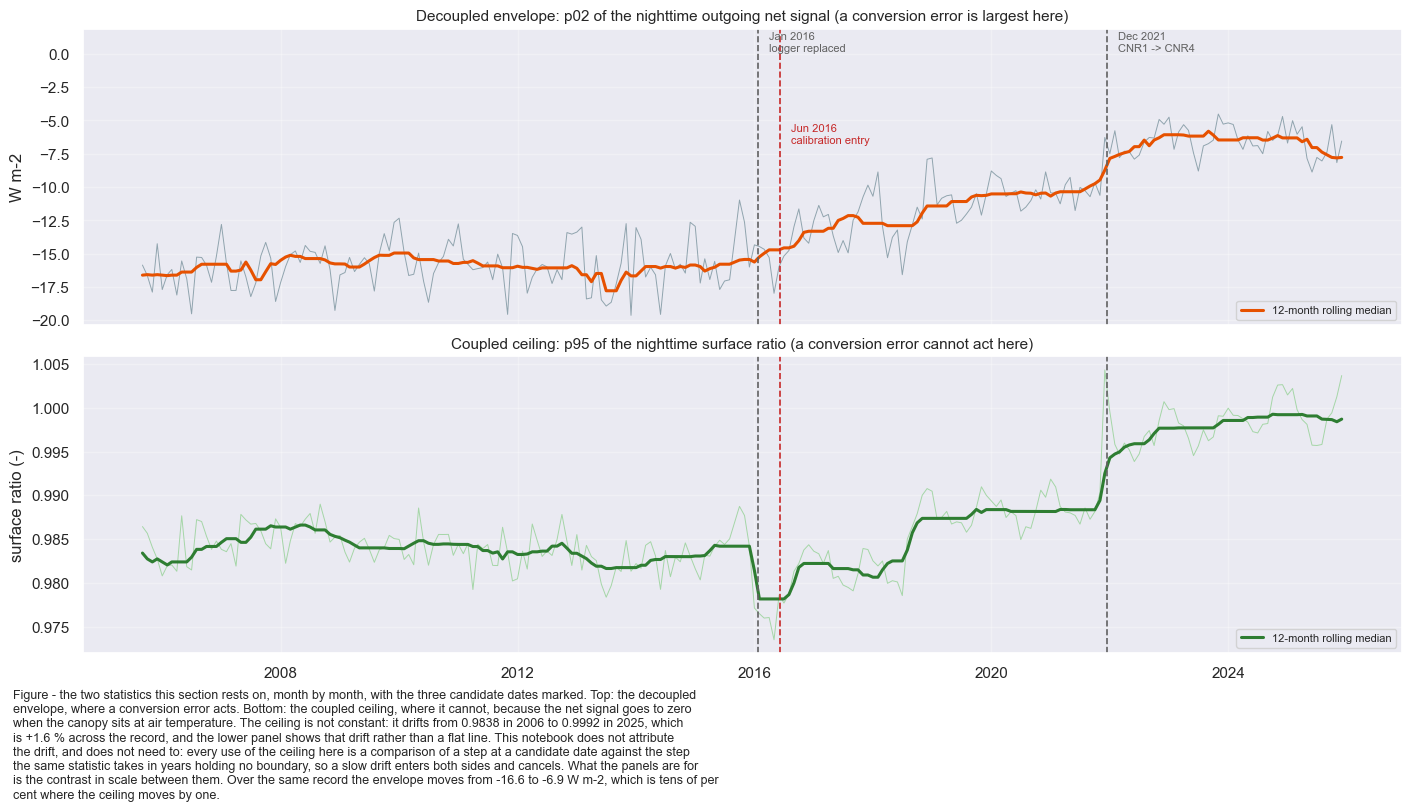

In [37]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 8), dpi=100, layout='constrained', sharex=True)

_dates = [(pd.Timestamp(LOGGER_CHANGE), 'Jan 2016\nlogger replaced', '#616161', 0.99),
          (pd.Timestamp(CAL_CHANGE), 'Jun 2016\ncalibration entry', '#C62828', 0.68),
          (pd.Timestamp(CNR4_INSTALLED), 'Dec 2021\nCNR1 -> CNR4', '#616161', 0.99)]

axs[0].plot(ENVELOPE_M.index, ENVELOPE_M.values, color='#90A4AE', lw=0.7)
axs[0].plot(ENVELOPE_M.index, ENVELOPE_M.rolling(12, center=True, min_periods=6).median(),
            color='#E65100', lw=2.2, label='12-month rolling median')
axs[0].set_ylabel('W m-2')
axs[0].set_title(f'Decoupled envelope: p{int(100 * DECOUPLED_Q):02d} of the nighttime outgoing net '
                 f'signal (a conversion error is largest here)', fontsize=11)
axs[0].legend(fontsize=8, loc='lower right')

_ceiling_m = monthly_q(RATIO_NIGHT, COUPLED_Q)
axs[1].plot(_ceiling_m.index, _ceiling_m.values, color='#A5D6A7', lw=0.7)
axs[1].plot(_ceiling_m.index, _ceiling_m.rolling(12, center=True, min_periods=6).median(),
            color='#2E7D32', lw=2.2, label='12-month rolling median')
axs[1].set_ylabel('surface ratio (-)')
axs[1].set_title(f'Coupled ceiling: p{int(100 * COUPLED_Q)} of the nighttime surface ratio '
                 f'(a conversion error cannot act here)', fontsize=11)
axs[1].legend(fontsize=8, loc='lower right')

for _ax in axs:
    _ax.grid(alpha=0.3)
    for _d, _t, _c, _y in _dates:
        _ax.axvline(_d, color=_c, ls='--', lw=1.2)
_lo_y, _hi_y = axs[0].get_ylim()
axs[0].set_ylim(_lo_y, _hi_y + 0.34 * (_hi_y - _lo_y))
_lo_y, _hi_y = axs[0].get_ylim()
for _d, _t, _c, _y in _dates:
    axs[0].text(_d + pd.Timedelta(days=70), _lo_y + _y * (_hi_y - _lo_y), _t, fontsize=8,
                color=_c, va='top')

_ceil_first, _ceil_last = float(CEILING_Y.iloc[0]), float(CEILING_Y.iloc[-1])
_ceil_drift = 100 * (_ceil_last / _ceil_first - 1)
_env_first = float(ENVELOPE_Y.iloc[0])
_env_last = float(ENVELOPE_Y.iloc[-1])
figcap(fig, f"the two statistics this section rests on, month by month, with the three candidate "
            f"dates marked. Top: the decoupled envelope, where a conversion error acts. Bottom: "
            f"the coupled ceiling, where it cannot, because the net signal goes to zero when the "
            f"canopy sits at air temperature. The ceiling is not constant: it drifts from "
            f"{_ceil_first:.4f} in {int(CEILING_Y.index[0])} to {_ceil_last:.4f} in "
            f"{int(CEILING_Y.index[-1])}, which is {_ceil_drift:+.1f} % across the record, and the "
            f"lower panel shows that drift rather than a flat line. This notebook does not "
            f"attribute the drift, and does not need to: every use of the ceiling here is a "
            f"comparison of a step at a candidate date against the step the same statistic takes "
            f"in years holding no boundary, so a slow drift enters both sides and cancels. What "
            f"the panels are for is the contrast in scale between them. Over the same record the "
            f"envelope moves from {_env_first:.1f} to {_env_last:.1f} W m-2, which is tens of per "
            f"cent where the ceiling moves by one.")

### 📊 Plot: emission and net longwave checks

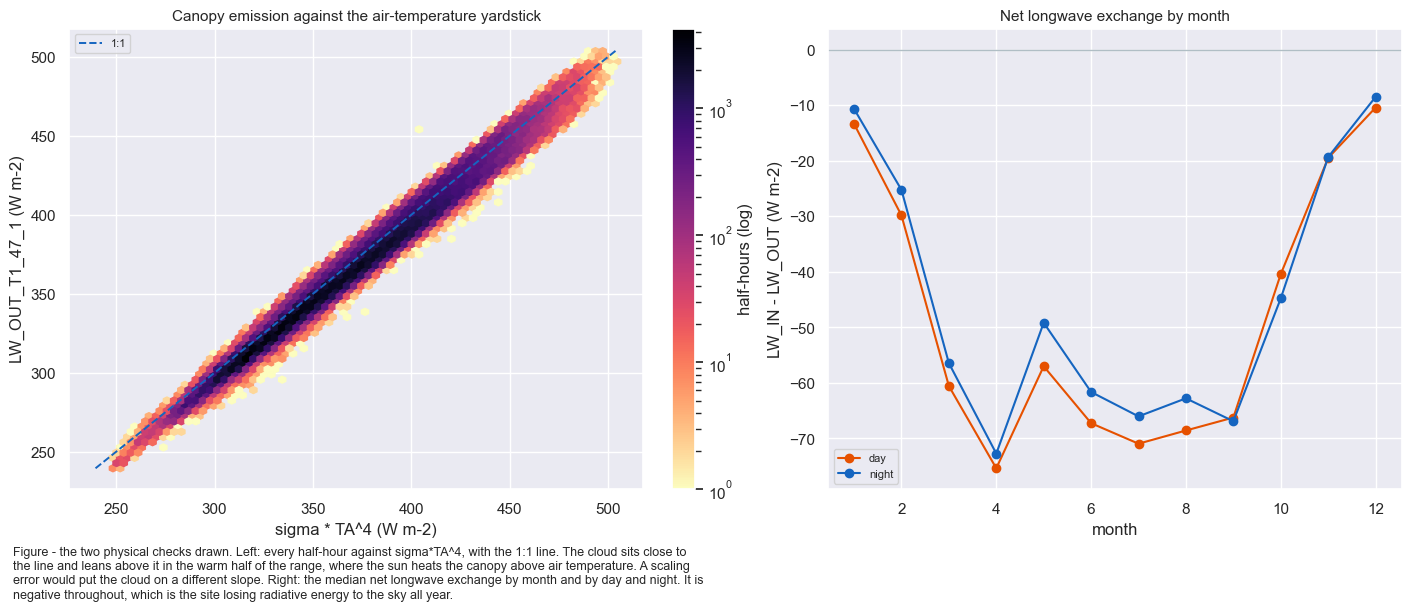

In [38]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 6), dpi=100, layout='constrained')

_x = SIGMA_T4.where(TA_IS_MEASURED & LW_FINAL.notna())
_y = LW_FINAL.where(_x.notna())
_ok = _x.notna() & _y.notna()
_hb = axs[0].hexbin(_x[_ok].values, _y[_ok].values, gridsize=70, mincnt=1, cmap='magma_r',
                    bins='log')
_lim = [min(float(_x[_ok].min()), float(_y[_ok].min())),
        max(float(_x[_ok].max()), float(_y[_ok].max()))]
axs[0].plot(_lim, _lim, color='#1565C0', lw=1.4, ls='--', label='1:1')
axs[0].set_xlabel('sigma * TA^4 (W m-2)')
axs[0].set_ylabel(f'{TARGET} (W m-2)')
axs[0].set_title('Canopy emission against the air-temperature yardstick', fontsize=11)
axs[0].legend(fontsize=8, loc='upper left')
fig.colorbar(_hb, ax=axs[0], label='half-hours (log)')

_month = _net_all.groupby([_net_all.index.month, NIGHT.reindex(_net_all.index)]).median().unstack()
_month.columns = ['day', 'night']
_month.plot(ax=axs[1], marker='o', color={'day': '#E65100', 'night': '#1565C0'})
axs[1].axhline(0, color='#B0BEC5', lw=1.0)
axs[1].set_xlabel('month')
axs[1].set_ylabel('LW_IN - LW_OUT (W m-2)')
axs[1].set_title('Net longwave exchange by month', fontsize=11)
axs[1].legend(fontsize=8)

figcap(fig, "the two physical checks drawn. Left: every half-hour against sigma*TA^4, with the 1:1 "
            "line. The cloud sits close to the line and leans above it in the warm half of the "
            "range, where the sun heats the canopy above air temperature. A scaling error would "
            "put the cloud on a different slope. Right: the median net longwave exchange by month "
            "and by day and night. It is negative throughout, which is the site losing radiative "
            "energy to the sky all year.")

#### What this section settles

The instrument behind this series is a Kipp & Zonen CNR1 until 14 December 2021, and a CNR4 after
that. Every logger program that survives converts the outgoing longwave channel with the
pyranometer's factor rather than the pyrgeometer's own, which matters for the absolute accuracy of
the early record.

The four dates the section opened with are answered in the table below, which is built from the
conclusions the cells above reached rather than written out here. Each row carries the branch the
data actually took, so this summary cannot drift away from the result.

One question stays open whatever those answers are: the 24 days after the December 2021 exchange
were recorded through a constant this notebook cannot name. It can bound the resulting error, and
the flag gives the interval its own code.

Nothing is corrected for any of it. The assertions in this section exist so that the conclusions
cannot quietly go stale. Suppose a re-run finds the coupled ceiling moving further at a hardware
date than it moves in a quiet year, or finds a June 2016 step without the shape of a conversion
change. The notebook then stops there, rather than exporting a product whose flag no longer
describes what is in it.

In [39]:
tabcap("what this section settled, taken from the branches the cells above actually took rather "
       "than from the prose beside them")
_settled = pd.Series({
    'the two data versions':
        'agree over the overlap, so the splice changes no value' if OVERLAP_PROVEN
        else 'never overlap, so the splice at the join is untested',
    'January 2016, the acquisition change':
        f'no change: the spring 2016 window falls {JAN2016_VERDICT} the quiet-year range, and '
        f'every surviving program applies one conversion across that date',
    'June 2016, the program change': JUN2016_CONCLUSION,
    'December 2021, the radiometer exchange': DEC2021_CONCLUSION,
    'the 24 days after the exchange':
        f'flagged, not corrected: the constant in force is not established, and the error it could '
        f'produce is at most {WINDOW_MAX_ERROR:.1f} W m-2',
}, name='what the data say').to_frame()
with pd.option_context('display.max_colwidth', 140):
    display(_settled)

Table - what this section settled, taken from the branches the cells above actually took rather than
from the prose beside them



,what the data say
the two data versions,"agree over the overlap, so the splice changes no value"
"January 2016, the acquisition change","no change: the spring 2016 window falls inside the quiet-year range, and every surviving program applies one conversion across that date"
"June 2016, the program change",the June 2016 calibration change reached this channel
"December 2021, the radiometer exchange","the record steps at the exchange, and the change of data version is excluded as its cause"
the 24 days after the exchange,"flagged, not corrected: the constant in force is not established, and the error it could produce is at most 1.6 W m-2"


***

## 🏷️ Provenance flag: which instrument and which calibration

One column name covers two instruments and three logger-program eras, so the exported file says
which of them produced each value. The boundaries between the codes are the dates read out of the
fieldbook above, not dates typed in again here.

The changeover interval gets a code of its own rather than being assigned to the instrument on one
side or the other, because the evidence cannot assign it. Notebook `06` does the same, and so does
`08` for its 71-day transition in 2018.

One detail differs from `06` on purpose, and a reader comparing the two files will notice it. `06`
gives the whole of 14 December 2021 to the CNR1 and starts its undetermined code on the following
day. Here the whole installation day carries the undetermined code instead, because the exchange
happened during that day and the screening notebook dates the handling to the early afternoon.

In [40]:
FLAGCOL = f'FLAG_{TARGET}_SOURCE'
# Written with inclusive end dates, so the legend reads the way a data user would filter.
_last_cnr1 = (pd.Timestamp(CNR4_INSTALLED) - pd.Timedelta(days=1)).date()
_last_undet = (pd.Timestamp(CNR4_CONSTANTS) - pd.Timedelta(days=1)).date()
_last_old_cal = (pd.Timestamp(CAL_CHANGE) - pd.Timedelta(days=1)).date()
SOURCE_LEGEND = {
    0: f'0 = CNR4 on its own calibration constant, {SENSITIVITY_CNR4_LW_OUT} uV/W/m2 (from '
       f'{CNR4_CONSTANTS})',
    1: f'1 = CNR1, logger program of {CAL_CHANGE} onwards ({CAL_CHANGE} to {_last_cnr1})',
    2: f'2 = CNR1 at {SENSITIVITY_OLD} uV/W/m2, the PYRANOMETER factor (to {_last_old_cal})',
    3: f'3 = changeover, calibration undetermined ({CNR4_INSTALLED} to {_last_undet}): CNR4 '
       f'installed, CNR1 constant still in the program',
}

source = pd.Series(0, index=full_index, dtype='int8', name=FLAGCOL)
source.loc[:pd.Timestamp(CAL_CHANGE) - pd.Timedelta(minutes=15)] = 2
source.loc[pd.Timestamp(CAL_CHANGE):pd.Timestamp(CNR4_INSTALLED) - pd.Timedelta(minutes=15)] = 1
source.loc[pd.Timestamp(CNR4_INSTALLED):pd.Timestamp(CNR4_CONSTANTS) - pd.Timedelta(minutes=15)] = 3
# code 0 is what remains, from CNR4_CONSTANTS onwards

tabcap("the exported provenance flag, by code. Code 1 is the era whose conversion no surviving "
       "program states; code 3 is the 24 days the evidence cannot assign to either instrument's "
       "constant")
_flagtab = pd.DataFrame({
    'meaning': {c: SOURCE_LEGEND[c] for c in sorted(SOURCE_LEGEND)},
    'records': source.value_counts().reindex(sorted(SOURCE_LEGEND)).fillna(0).astype(int),
    'measured records': source.where(LW_FINAL.notna()).value_counts()
                              .reindex(sorted(SOURCE_LEGEND)).fillna(0).astype(int),
})
_flagtab['share of measured (%)'] = (100 * _flagtab['measured records']
                                     / _flagtab['measured records'].sum()).round(2)
_flagtab.index.name = 'code'
with pd.option_context('display.max_colwidth', 130):
    display(_flagtab)

# The flag is defined everywhere, describes the whole index once, and its boundaries are the dates
# read out of the fieldbook rather than dates typed here a second time.
assert source.notna().all(), "the source flag is not defined everywhere"
assert set(source.unique()) == set(SOURCE_LEGEND), \
    "a code appears in the flag that the legend does not describe, or the other way round"
assert source.loc[:pd.Timestamp(CAL_CHANGE) - pd.Timedelta(minutes=15)].eq(2).all(), \
    "the earliest era no longer runs from the start of the record to the June 2016 entry"
assert source.loc[pd.Timestamp(CAL_CHANGE):
                  pd.Timestamp(CNR4_INSTALLED) - pd.Timedelta(minutes=15)].eq(1).all(), \
    "the two CNR1 eras no longer meet exactly at the June 2016 entry"
assert source.loc[pd.Timestamp(CNR4_CONSTANTS):].eq(0).all(), \
    "the CNR4 era no longer runs from the program update to the end of the record"
assert int(source.eq(3).sum()) == len(pd.date_range(
    f'{CNR4_INSTALLED} 00:15', pd.Timestamp(CNR4_CONSTANTS) - pd.Timedelta(minutes=15),
    freq='30min')), \
    "the undetermined interval is not the interval between the two December/January dates"
print(f"\nUndetermined interval: {int(source.eq(3).sum()):,} half-hours ({DAYS_UNDETERMINED} days)")

Table - the exported provenance flag, by code. Code 1 is the era whose conversion no surviving
program states; code 3 is the 24 days the evidence cannot assign to either instrument's constant



,meaning,records,measured records,share of measured (%)
code,,,,
0,"0 = CNR4 on its own calibration constant, 11.33 uV/W/m2 (from 2022-01-07)",69840,69724,19.98
1,"1 = CNR1, logger program of 2016-06-07 onwards (2016-06-07 to 2021-12-13)",96768,95996,27.51
2,"2 = CNR1 at 10.03 uV/W/m2, the PYRANOMETER factor (to 2016-06-06)",188112,182102,52.18
3,"3 = changeover, calibration undetermined (2021-12-14 to 2022-01-06): CNR4 installed, CNR1 constant still in the program",1152,1136,0.33



Undetermined interval: 1,152 half-hours (24 days)


***

## 🚫 No gap-filling here

The series is exported as it was measured, as in notebooks `05` and `06`. Three things follow for
anything that reads this file.

- `LW_OUT_T1_47_1` contains `NaN`, so code that assumes a complete series will either break or
  propagate the gaps silently.
- There is no `FLAG_..._ISFILLED` column, because there is nothing to flag. A value that is not
  null was measured.
- If a complete series is needed later, for example for a four-component net radiation or an
  energy-balance closure, the filling belongs downstream, where it can be flagged in that product's
  own terms. Any such fill has to respect the codes of the provenance flag, because a single model
  trained across a calibration boundary would put its filled values on neither era's level.

***

## ➡️ Prepare dataframe for export

In [41]:
VALCOL = TARGET

export_df = lw_2005_2025[[VALCOL]].copy()
export_df[FLAGCOL] = source
tabcap("the exported frame: the measured series and the flag naming the instrument and calibration "
       "constant behind each value")
display(export_df)

Table - the exported frame: the measured series and the flag naming the instrument and calibration
constant behind each value



,LW_OUT_T1_47_1,FLAG_LW_OUT_T1_47_1_SOURCE
TIMESTAMP_MIDDLE,,
2005-09-14 00:15:00,NaN,2
2005-09-14 00:45:00,NaN,2
2005-09-14 01:15:00,NaN,2
2005-09-14 01:45:00,NaN,2
2005-09-14 02:15:00,NaN,2
...,...,...
2025-12-31 21:45:00,298.233563,0
2025-12-31 22:15:00,297.949947,0
2025-12-31 22:45:00,297.206430,0


The series is not expected to be complete, so completeness is not what is checked. What is checked
is that the index is continuous and free of duplicates, and that every value present is physically
plausible upwelling longwave. The provenance flag has to be defined at every record, and the number
of records removed has to match what the corrections section reported.

In [42]:
print(f"Records:          {len(export_df):,}")
print(f"Measured:         {int(export_df[VALCOL].notna().sum()):,} "
      f"({100 * export_df[VALCOL].notna().mean():.2f}%)")
print(f"Missing (NaN):    {int(export_df[VALCOL].isnull().sum()):,} "
      f"({100 * export_df[VALCOL].isna().mean():.2f}%)")
print(f"Measured at the merge, before any correction: {MEASURED_AT_MERGE:,}")
print(f"Duplicate index:  {int(export_df.index.duplicated().sum())}")
print(f"Index gaps:       "
      f"{int((export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum())}")
print(f"Index:            {export_df.index[0]} -> {export_df.index[-1]}")
print(f"Min / max:        {export_df[VALCOL].min():.2f} / {export_df[VALCOL].max():.2f} W m-2")

assert export_df.index.duplicated().sum() == 0, "duplicate timestamps"
assert (export_df.index.to_series().diff().dropna() == pd.Timedelta('30min')).all(), \
    "index not continuous 30MIN"
assert export_df[VALCOL].notna().any(), "no data at all"
assert export_df[FLAGCOL].notna().all(), "the provenance flag is not defined at every record"
# The raising form of the range guard, which can only be asserted here because the removal ran
# first.
check_range(export_df[VALCOL], 'exported column')

tabcap("what each correction removed. The exported record count is this arithmetic rather than a "
       "matter of trust, and the assertion below checks it")
display(pd.Series(REMOVALS, name='records removed').to_frame())
assert int(export_df[VALCOL].notna().sum()) == MEASURED_AT_MERGE - sum(REMOVALS.values()), (
    f"the exported series holds {int(export_df[VALCOL].notna().sum()):,} measured records, but the "
    f"merge held {MEASURED_AT_MERGE:,} and the corrections above account for only "
    f"{sum(REMOVALS.values()):,} removals. Something else in this notebook is modifying the data")
print("\nAll checks passed.")

tabcap("summary statistics of the exported value column")
display(export_df[[VALCOL]].describe())

Records:          355,872
Measured:         348,958 (98.06%)
Missing (NaN):    6,914 (1.94%)
Measured at the merge, before any correction: 350,171
Duplicate index:  0
Index gaps:       0
Index:            2005-09-14 00:15:00 -> 2025-12-31 23:45:00
Min / max:        239.56 / 503.51 W m-2
Table - what each correction removed. The exported record count is this arithmetic rather than a
matter of trust, and the assertion below checks it



,records removed
damaged periods in 2012,1202
records outside the physical band,1
the radiometer exchange excursion,10



All checks passed.
Table - summary statistics of the exported value column



,LW_OUT_T1_47_1
count,348958.000000
mean,359.077707
std,41.903488
min,239.559906
25%,325.925829
50%,356.660110
75%,388.714425
max,503.505563


### Where the gaps are

Most of the missing records were never recorded at all. The removals above account for only a small
part of them, and the printout says how many each step took. The ten longest gaps are listed below
so that a reader who meets a gap can tell a station outage from something this notebook removed.

In [43]:
_missing = export_df[VALCOL].isna()
if int(_missing.sum()) > 0:
    _gapstamps = export_df.index.to_series()[_missing]
    _blocks = (_gapstamps.diff() != pd.Timedelta('30min')).cumsum()
    _gaptab = _gapstamps.groupby(_blocks).agg(['first', 'last', 'size'])
    _gaptab.columns = ['from', 'to', 'records']
    _gaptab['days'] = (_gaptab['records'] / 48).round(1)
    _gaptab = _gaptab.sort_values('records', ascending=False).head(10).reset_index(drop=True)
    tabcap(f"the ten longest gaps in the exported series, out of {int(_blocks.nunique()):,} gaps "
           f"holding {int(_missing.sum()):,} records in total")
    display(_gaptab)
else:
    print("The exported series has no gaps at all.")

Table - the ten longest gaps in the exported series, out of 972 gaps holding 6,914 records in total



,from,to,records,days
0,2015-08-17 15:15:00,2015-09-27 17:45:00,1974,41.1
1,2016-01-01 00:15:00,2016-01-21 13:45:00,988,20.6
2,2019-11-04 04:45:00,2019-11-19 23:45:00,759,15.8
3,2012-10-28 00:15:00,2012-11-09 23:45:00,624,13.0
4,2012-07-29 00:15:00,2012-08-10 15:15:00,607,12.6
5,2009-08-05 09:15:00,2009-08-15 02:45:00,468,9.8
6,2010-07-01 10:15:00,2010-07-04 16:15:00,157,3.3
7,2024-06-29 17:45:00,2024-07-01 13:15:00,88,1.8
8,2013-08-15 14:45:00,2013-08-16 16:45:00,53,1.1
9,2005-09-14 00:15:00,2005-09-14 12:45:00,26,0.5


### Per-year statistics

2005 is a partial year by construction, because the record starts in September, so it covers autumn
and no summer. Its median is therefore not comparable with the others, and the check below excludes
it from the reference it builds while still testing it against that reference. The `calibration`
column lists the flag codes present in each year, so a year holding a boundary is one that carries
more than one code.

In [44]:
_yr = export_df[VALCOL].groupby(export_df.index.year).agg(['count', 'median', 'min', 'max', 'std'])
_yr['possible'] = export_df[VALCOL].groupby(export_df.index.year).size()
_yr['coverage_%'] = (100 * _yr['count'] / _yr['possible']).round(2)
_yr['calibration'] = (export_df[FLAGCOL].groupby(export_df.index.year)
                      .agg(lambda s: '/'.join(str(int(v)) for v in sorted(s.unique()))))
tabcap("the exported series year by year, with the flag codes present in each year")
display(_yr.round(2))

_med = _yr['median']
# Asserting that a yearly median lies inside the physical band would test nothing: check_range has
# already forced every value into it, so a median of those values cannot fall outside. The check
# that can fail is whether any year departs from the rest of the record by more than the record's
# own year-to-year scatter allows. 2005 is excluded from the reference because it covers only
# autumn, and is then tested against it like any other year.
_full = _med.loc[2006:]
_centre, _scatter = float(_full.median()), float(_full.std())
_departure = (_med - _centre).abs()
YEAR_WALL = 4 * _scatter
tabcap("each year's median against the middle of the record, in units of the year-to-year scatter "
       "of the full years. The last column is the assertion below")
display(pd.DataFrame({'median (W m-2)': _med.round(2),
                      'departure from the record median (W m-2)': _departure.round(2),
                      'in units of the year-to-year sd': (_departure / _scatter).round(2)}))
print(f"full years {int(_full.index.min())}-{int(_full.index.max())}: median {_centre:.2f} W m-2, "
      f"spread {_full.min():.2f} to {_full.max():.2f}, sd {_scatter:.2f}")
print(f"wall: {YEAR_WALL:.2f} W m-2, i.e. four times that scatter")
assert (_departure <= YEAR_WALL).all(), (
    f"the year {int(_departure.idxmax())} has a median {_departure.max():.2f} W m-2 from the "
    f"middle of the record, more than the {YEAR_WALL:.2f} W m-2 that four times the year-to-year "
    f"scatter allows. A year that far out is either an instrument problem or a coverage problem, "
    f"and the coverage column above says which")

Table - the exported series year by year, with the flag codes present in each year



,count,median,min,max,std,possible,coverage_%,calibration
TIMESTAMP_MIDDLE,,,,,,,,
2005,5109,337.18,266.02,420.54,33.83,5232,97.65,2
2006,17395,357.18,260.64,486.57,44.81,17520,99.29,2
2007,17425,353.80,269.31,480.49,38.91,17520,99.46,2
2008,17404,349.40,279.37,467.32,38.63,17568,99.07,2
2009,16924,354.54,244.36,475.17,42.59,17520,96.60,2
2010,17294,350.48,251.82,479.29,43.15,17520,98.71,2
2011,17475,359.30,272.02,483.53,39.52,17520,99.74,2
2012,16217,354.47,239.56,479.27,42.56,17568,92.31,2
2013,17331,348.67,269.36,493.86,43.10,17520,98.92,2


Table - each year's median against the middle of the record, in units of the year-to-year scatter of
the full years. The last column is the assertion below



,median (W m-2),departure from the record median (W m-2),in units of the year-to-year sd
TIMESTAMP_MIDDLE,,,
2005,337.18,19.59,3.74
2006,357.18,0.41,0.08
2007,353.80,2.98,0.57
2008,349.40,7.37,1.41
2009,354.54,2.23,0.43
2010,350.48,6.30,1.20
2011,359.30,2.53,0.48
2012,354.47,2.31,0.44
2013,348.67,8.10,1.55


full years 2006-2025: median 356.77 W m-2, spread 348.67 to 368.43, sd 5.24
wall: 20.98 W m-2, i.e. four times that scatter


### 📊 Plot: the exported product, per year

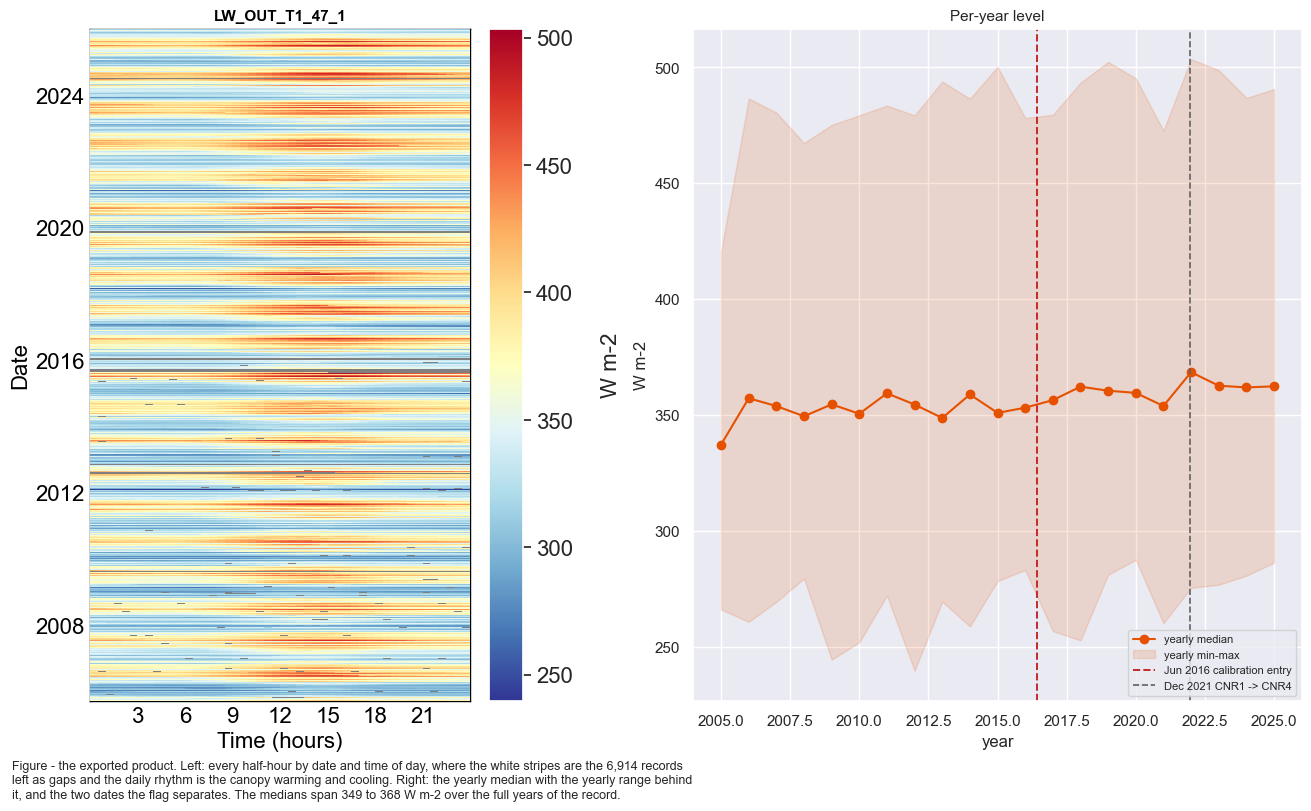

In [45]:
fig, axs = plt.subplots(ncols=2, figsize=(13, 8), dpi=100, layout='constrained',
                        width_ratios=[1, 1.6])
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel='W m-2',
    format_style=dv.plotting.FormatStyle(title=VALCOL, title_fontsize=11))

_yr['median'].plot(ax=axs[1], marker='o', color='#E65100', label='yearly median')
axs[1].fill_between(_yr.index, _yr['min'], _yr['max'], color='#E65100', alpha=.15,
                    label='yearly min-max')
axs[1].axvline(2016.44, color='#C62828', ls='--', lw=1.4, label='Jun 2016 calibration entry')
axs[1].axvline(2021.96, color='#616161', ls='--', lw=1.2, label='Dec 2021 CNR1 -> CNR4')
axs[1].set_ylabel('W m-2')
axs[1].set_xlabel('year')
axs[1].set_title('Per-year level', fontsize=11)
axs[1].legend(fontsize=8)

figcap(fig, f"the exported product. Left: every half-hour by date and time of day, where the white "
            f"stripes are the {int(export_df[VALCOL].isna().sum()):,} records left as gaps and the "
            f"daily rhythm is the canopy warming and cooling. Right: the yearly median with the "
            f"yearly range behind it, and the two dates the flag separates. The medians span "
            f"{_med.loc[2006:].min():.0f} to {_med.loc[2006:].max():.0f} W m-2 over the full years "
            f"of the record.")

***

## 💾 Save to file

In [46]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\13_METEO_LW_OUT_2005-2025.parquet (0.057 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\13_METEO_LW_OUT_2005-2025.parquet


### Verify the written file

The written file is read back from disk and checked directly, because a check on the frame still in
memory would not notice a fault introduced by writing it.

In [47]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))

print(f"columns:   {list(_written.columns)}")
print(f"index:     {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)")
print(f"measured:  {int(_written[VALCOL].notna().sum()):,} "
      f"({100 * _written[VALCOL].notna().mean():.2f}%)")
print(f"median:    {float(_written[VALCOL].median()):.2f} W m-2")
print(f"min / max: {float(_written[VALCOL].min()):.2f} / {float(_written[VALCOL].max()):.2f} W m-2")

assert list(_written.columns) == [VALCOL, FLAGCOL], "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
assert _written[VALCOL].notna().sum() == export_df[VALCOL].notna().sum(), \
    "measured count changed on write"
assert _written[FLAGCOL].equals(export_df[FLAGCOL]), "the provenance flag changed on write"
check_range(_written[VALCOL], 'written file')
print("\nWritten file verified.")

tabcap("the written file read back, by year and by calibration code")
_check = _written.groupby([_written.index.year, _written[FLAGCOL]])[VALCOL].median().unstack()
_check.index.name = 'YEAR'
_check.columns = [f'code {int(c)}' for c in _check.columns]
display(_check.round(2))

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\13_METEO_LW_OUT_2005-2025.parquet (0.011 seconds).

columns:   ['LW_OUT_T1_47_1', 'FLAG_LW_OUT_T1_47_1_SOURCE']
index:     2005-09-14 00:15:00 -> 2025-12-31 23:45:00  (355,872 records)
measured:  348,958 (98.06%)
median:    356.66 W m-2
min / max: 239.56 / 503.51 W m-2

Written file verified.
Table - the written file read back, by year and by calibration code



,code 0,code 1,code 2,code 3
YEAR,,,,
2005,NaN,NaN,337.18,NaN
2006,NaN,NaN,357.18,NaN
2007,NaN,NaN,353.80,NaN
2008,NaN,NaN,349.40,NaN
2009,NaN,NaN,354.54,NaN
2010,NaN,NaN,350.48,NaN
2011,NaN,NaN,359.30,NaN
2012,NaN,NaN,354.47,NaN
2013,NaN,NaN,348.67,NaN


***

## End of notebook.

In [48]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-09-03 21:50:09
Finished: 2026-09-03 21:50:36
Runtime:  00:00:27 (hh:mm:ss)
